# A Multi-Criteria Analysis for Municipal Well Siting

**Course:** CIVE 891 – Groundwater Geology

**Prepared by:** Ehsan Nikfarjam, Mohsen Nikfarjam

**Presented to:** Dr. Erin Haacker

---

## Abstract

The Zootopia Consulting Firm was retained by the Town of "A" Council to conduct a systematic site suitability analysis for a proposed new municipal water supply well. The objective was to identify and rank potential locations within an 8 km × 8 km study area capable of supporting a target yield of approximately 1000 gallons per minute.

The analysis utilized a GIS-based prioritization matrix framework, adapted from Glotfelty (2017), integrating **nine hydrogeologic, logistical, and environmental criteria** derived from client-provided data and publicly available sources. The study area was divided into 100 grid cells (0.5-mile or 0.8-km resolution), and each cell was evaluated based on factors including aquifer transmissivity, well spacing from existing wells, aquifer thickness, land ownership, distance to town, environmental sensitivity, depth to water, depth to aquifer base, and soil type.

The primary finding identifies the grid cell at **Row 10, Column 10** as the most suitable potential location, achieving the highest prioritization score of **84.8%**. The analysis identified **8 out of 100 grid cells** (8%) as unsuitable due to fatal flaws, primarily related to designated protected habitat, urban land use, or proximity (< 0.5 miles) to existing wells.

An uncertainty analysis using **Monte Carlo simulation (250 iterations)** assessed the robustness of these findings to variability in key input data. While the overall ranking patterns appear relatively stable, the standard deviation map indicates moderate sensitivity in suitability scores across much of the study area, underscoring the need for field verification.

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Study Area Description](#2-study-area-description)
3. [Methodology](#3-methodology)
4. [Computational Environment](#4-library-imports-and-configuration)
5. [Data Loading and Exploration](#5-data-loading-and-exploration)
6. [Derived Hydrogeological Calculations](#6-derived-hydrogeological-calculations)
7. [Spatial Analysis: Distance Calculations](#7-spatial-analysis-distance-calculations)
8. [Multi-Criteria Evaluation](#8-scoring-system-implementation)
9. [Exclusionary Constraint Analysis](#9-fatal-flaw-identification)
10. [Criteria Weighting and Prioritization Matrix](#10-criteria-definition-and-prioritization-matrix)
11. [Input Data Characterization](#11-input-data-characterization)
12. [Results: Suitability Analysis and Site Selection](#13-results-suitability-analysis-and-site-selection)
13. [Uncertainty Analysis (Monte Carlo Simulation)](#14-uncertainty-analysis-monte-carlo-simulation)
14. [Land Ownership Analysis](#15-land-ownership-analysis)
15. [Conclusions and Recommendations](#15-conclusions-and-recommendations)
16. [References](#16-references)

---

<a name="1-introduction"></a>
## 1. Introduction

### 1.1 Project Background

The Town of "A", a municipality with approximately 200 residents located in the Midwest, is exploring the development of a centralized water system to support community needs and encourage potential growth. Concurrently, a local landowner and council member, Ms. Bernice Mayors, is seeking to permit a new high-capacity irrigation well. Both the proposed municipal and irrigation wells are anticipated to require significant pumping rates, estimated at approximately 1000 gallons per minute (gpm).

Recognizing the potential for interaction between these proposed withdrawals and existing groundwater uses, the Town Council and local landowners, including Ms. Mayors, have adopted a collaborative approach. Zootopia Consulting was commissioned to conduct a systematic evaluation of the hydrogeologic setting to identify optimal locations for groundwater development.

### 1.2 Project Objectives

The primary objective of this investigation is to identify and rank potential locations for the new Town of "A" municipal supply well within a defined study area. The analysis employs a quantitative, multi-criteria prioritization matrix approach to systematically evaluate potential sites based on relevant hydrogeologic, environmental, and logistical factors. The goal is to provide the Town Council with a scientifically defensible basis for focusing subsequent, more detailed field investigations.

### 1.3 Scope of Work

To achieve the project objectives, the following tasks were performed:

- Compiled and reviewed client-provided data, including spatial datasets, aerial imagery, and existing well logs
- Established a systematic site prioritization framework based on Glotfelty (2017)
- Developed and applied scoring criteria and weighting factors relevant to municipal well siting
- Calculated derived hydrogeologic parameters (aquifer thickness, transmissivity) from input data
- Identified and mapped areas unsuitable for development due to predefined "fatal flaw" constraints
- Generated a final prioritization matrix map illustrating the relative suitability of each grid cell
- Conducted an uncertainty analysis using Monte Carlo simulation
- Prepared comprehensive documentation with actionable recommendations

---

<a name="2-study-area-description"></a>
## 2. Study Area Description

The analysis focuses on an **8 km × 8 km** (approximately 5 miles × 5 miles) area surrounding the Town of "A". This study area is represented by a **10-row × 10-column grid system**, where each grid cell corresponds to approximately **0.5 miles × 0.5 miles (800 m × 800 m)**.

### Key Reference Locations (1-based indexing: Column from left, Row from top)

| Location | Grid Position | Description |
|----------|---------------|-------------|
| **Town of "A"** | Column 4, Row 6 | Municipal center (yellow flag in imagery) |
| **Well 'a'** | Column 2, Row 5 | High-capacity test hole drilled to aquifer base |
| **Well 'b'** | Column 10, Row 5 | Monitoring well with stable 2-year water levels |
| **Well 'c'** | Column 1, Row 9 | Existing 800 gpm irrigation well |

### Hydrogeologic Context

Based on well profile logs from existing wells 'a', 'b', and 'c':

- **Aquifer Material**: Predominantly fine sand with shale interbeds
- **Ground Surface Elevation**: ~473–476 m above sea level
- **Static Water Level**: ~471–472 m elevation (depth to water ~2–4 m below surface)
- **Aquifer Base**: Variable depth, with known uncertainty in interpolated values

### Stakeholder Considerations

Mr. Tobias King, a local farmer, has expressed concerns regarding:
1. Potential deep salty water based on historical drilling in the 1960s
2. Risk of bedrock puncture causing aquifer drainage
3. Potential interference with his domestic well

These concerns are addressed through the analysis methodology and recommendations.

---

<a name="3-methodology"></a>
## 3. Methodology

### 3.1 Prioritization Framework

The site suitability analysis employed a **quantitative prioritization matrix methodology**, adapted from Glotfelty (2017). This approach provides a systematic and transparent process for evaluating and comparing potential well locations based on multiple, diverse criteria.

The core steps involve:

1. Dividing the study area into a uniform grid
2. Identifying key criteria relevant to successful municipal well siting
3. Developing a standardized ranking system (1 to 5) for each criterion
4. Assigning multipliers (weights) reflecting relative importance and data certainty
5. Calculating weighted scores and normalizing to percentages
6. Identifying and excluding cells exhibiting "fatal flaws"

### 3.2 Core Calculation Formulas

**Weighted Score per Criterion:**

$$\text{Weighted Score}_i = \text{Rank}_i \times \text{Multiplier}_i$$

**Total Raw Score per Cell:**

$$\text{Total Score} = \sum_{i=1}^{9} (\text{Rank}_i \times \text{Multiplier}_i)$$

**Final Suitability Percentage:**

$$\text{Suitability (\%)} = \frac{\text{Total Score}}{145} \times 100$$

where 145 is the maximum possible score: $\sum (5 \times \text{Multiplier}_i)$ for all nine criteria.

### 3.3 Derived Variable Calculations

Two key hydrogeologic parameters are calculated for each grid cell:

**Aquifer Saturated Thickness:**

$$b = z_{\text{base}} - z_{\text{water}}$$

where:
- $b$ = aquifer thickness (m), constrained to $b \geq 0$
- $z_{\text{base}}$ = depth to aquifer base from surface (m)
- $z_{\text{water}}$ = depth to water table from surface (m)

**Aquifer Transmissivity:**

$$T = K \times b$$

where:
- $T$ = transmissivity (m²/day), constrained to $T \geq 0$
- $K$ = hydraulic conductivity (m/day)

### 3.4 Criteria Selection

Nine criteria were selected for the prioritization matrix:

| Criterion | Description | Importance |
|-----------|-------------|------------|
| **Transmissivity** | Aquifer's ability to yield water sustainably | Primary yield factor |
| **Well Spacing** | Distance to nearest existing well | Interference risk |
| **Aquifer Thickness** | Saturated thickness of aquifer | Yield potential |
| **Land Ownership** | Property access and negotiation | Project feasibility |
| **Distance to Town** | Proximity to point of use | Infrastructure cost |
| **Environmental** | Land cover sensitivity | Regulatory compliance |
| **Depth to Water** | Depth to water table | Drilling/pumping cost |
| **Depth to Aquifer Base** | Depth to bottom of aquifer | *High uncertainty* |
| **Soil Type** | Surface soil classification | Minor impact |

### 3.5 Scoring Thresholds (Rank 1-5)

| Criterion | Rank 1 | Rank 2 | Rank 3 | Rank 4 | Rank 5 |
|-----------|--------|--------|--------|--------|--------|
| Transmissivity (m²/d) | < 300 | < 400 | < 500 | < 600 | ≥ 600 |
| Well Spacing (mi) | < 1.0 | < 1.5 | < 2.0 | < 2.5 | ≥ 2.5 |
| Aquifer Thickness (m) | < 47.0 | < 50.0 | < 53.0 | < 56.0 | ≥ 56.0 |
| Land Ownership | BLM | Private | Mayors | — | Town |
| Distance to Town (mi) | ≥ 4.0 | < 4.0 | < 3.0 | < 2.0 | < 1.0 |
| Environmental (LC) | Protected | Urban | — | — | Agricultural |
| Depth to Water (m) | ≥ 4.5 | < 4.5 | < 4.0 | < 3.5 | < 3.0 |
| Depth to Base (m) | < 52.0 | < 54.0 | < 56.0 | < 58.0 | ≥ 58.0 |
| Soil Type | Silty Clay | Clay Loam | — | — | Silt Loam |

### 3.6 Weighting Scheme (Multipliers)

| Criterion | Multiplier | Justification |
|-----------|:----------:|---------------|
| Transmissivity | 5 | Primary factor for sustainable yield |
| Well Spacing | 5 | Critical for minimizing interference |
| Aquifer Thickness | 4 | Significant influence on yield |
| Land Ownership | 4 | Major factor in access/feasibility |
| Distance to Town | 3 | Infrastructure cost consideration |
| Environmental | 3 | Land use constraints beyond fatal flaws |
| Depth to Water | 3 | Drilling and operational pumping costs |
| Depth to Aquifer Base | **1** | **Low weight due to high data uncertainty** |
| Soil Type | 1 | Minor impact for deep municipal well |
| **Maximum Score** | **145** | Sum of (5 × Multiplier) for all criteria |

> **Note:** The minimal weight (Multiplier=1) assigned to Depth to Aquifer Base directly reflects the high uncertainty confirmed by cross-validation at well 'c', where calculated thickness differs by ~16.6 m from profile data.

### 3.7 Fatal Flaw Identification

Cells exhibiting any of the following conditions are assigned a final suitability score of **zero**:

1. **Land Cover Code = 2**: Designated Protected Habitat
2. **Land Cover Code = 3**: Medium-Density Urban Area
3. **Proximity < 0.5 miles**: Distance to nearest existing well less than 0.5 miles (~800 m)

### 3.8 Uncertainty Analysis (Monte Carlo Simulation)

To evaluate the impact of uncertainty in key input parameters, a Monte Carlo simulation was performed with **N = 250 iterations**. In each iteration:

| Parameter | Perturbation | Distribution |
|-----------|:------------:|:------------:|
| Hydraulic Conductivity (K) | ±20% | N(0, 0.20×K) |
| Depth to Water (DTW) | ±0.5 m | N(0, 0.5) |
| Depth to Aquifer Base (DTAB) | ±15% | N(0, 0.15×DTAB) |

The higher uncertainty (15%) for DTAB reflects known interpolation issues from limited data (wells 'a' and 'b' only).

**Statistical Measures:**

$$\mu = \frac{1}{N}\sum_{i=1}^{N} S_i \quad \text{(Mean Suitability)}$$

$$\sigma = \sqrt{\frac{\sum_{i=1}^{N}(S_i - \mu)^2}{N-1}} \quad \text{(Standard Deviation)}$$

---

<a name="4-library-imports-and-configuration"></a>
## 4. Library Imports and Configuration

This section establishes the computational environment, including scientific computing libraries, visualization tools, and analysis configuration parameters.

In [1]:
# Scientific computing and visualization library imports

# Core scientific computing
import numpy as np
import pandas as pd
import math
import random
import os
from IPython.display import HTML

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.transforms import Bbox
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib import cm

# Specialized scientific colormaps
import cmcrameri.cm as cmc      # Perceptually uniform, colorblind-safe
import cmocean                  # Oceanographic sequential maps
import seaborn as sns           # Statistical visualization

# Display settings for Jupyter
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Analysis configuration parameters

# Grid Configuration
CELL_SIZE_MILES = 0.5                          # Length of one grid cell (miles)
CELL_SIZE_KM = CELL_SIZE_MILES * 1.60934       # Length in kilometres (~0.8 km)

# Scoring Configuration
DYNAMIC_BINNING = False                        # If True, T score bins from data quantiles

# Monte Carlo Configuration
UNCERTAINTY_MC = True                          # Enable Monte Carlo uncertainty analysis
MC_ITERATIONS = 250                            # Number of Monte Carlo iterations
RANDOM_SEED = 42                               # Random seed for reproducibility

# Monte Carlo Uncertainty Parameters
# Justification: K has moderate uncertainty from interpolation.
# DTW depends on survey/log accuracy.
# DTAB has HIGH uncertainty (2-point interpolation, conflicts with well 'c' data).
K_UNCERT_PERCENT = 20.0                        # Perturb K by ± N(0, 20%)
DTW_UNCERT_METERS = 0.5                        # Perturb DTW by ± N(0, 0.5) meters
DTAB_UNCERT_PERCENT = 15.0                     # Perturb DTAB by ± N(0, 15%)

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Grid Configuration: {CELL_SIZE_MILES} miles × {CELL_SIZE_MILES} miles ({CELL_SIZE_KM:.2f} km × {CELL_SIZE_KM:.2f} km) cells")
print(f"Monte Carlo: {MC_ITERATIONS} iterations with seed {RANDOM_SEED}")
print(f"Uncertainty: K ±{K_UNCERT_PERCENT}%, DTW ±{DTW_UNCERT_METERS}m, DTAB ±{DTAB_UNCERT_PERCENT}%")

Grid Configuration: 0.5 miles × 0.5 miles (0.80 km × 0.80 km) cells
Monte Carlo: 250 iterations with seed 42
Uncertainty: K ±20.0%, DTW ±0.5m, DTAB ±15.0%


In [3]:
# Font configuration for visualizations
#
# Configures a consistent scientific typography (EB Garamond) for Matplotlib figures.

def configure_scientific_typography():
    """
    Sets global typography to EB Garamond for both Matplotlib figures 
    and Jupyter Notebook markdown cells. Handles Google Colab compatibility.
    """
    # 1. Inject CSS for Notebook Markdown (Google Fonts)
    # Uses EB Garamond from Google Fonts to ensure availability in Colab/Cloud
    css_str = """
    <link href="https://fonts.googleapis.com/css2?family=EB+Garamond:ital,wght@0,400;0,600;0,700;1,400&display=swap" rel="stylesheet">
    <style>
        /* Target Markdown, Headers, and Text Output */
        .rendered_html, .jp-RenderedHTMLCommon, div.text_cell_render, .text_cell_render {
            font-family: 'EB Garamond', 'Garamond', 'Times New Roman', serif !important;
            font-size: 18px !important;
            line-height: 1.6 !important;
            color: #333 !important;
        }
        .rendered_html h1, .rendered_html h2, .rendered_html h3 {
            font-family: 'EB Garamond', serif !important;
            font-weight: 600 !important;
        }
    </style>
    """
    display(HTML(css_str))
    print("Notebook typography set to EB Garamond (via Google Fonts).")

    # 2. Configure Matplotlib (Figures)
    
    # Install Fonts on Google Colab
    try:
        import sys
        if 'google.colab' in sys.modules:
            import subprocess
            font_check = subprocess.run(['fc-list'], capture_output=True, text=True)
            if 'Garamond' not in font_check.stdout:
                print("Google Colab detected. Installing EB Garamond font for high-quality figures...")
                subprocess.run(['apt-get', 'install', '-y', 'fonts-ebgaramond'], check=True)
                fm.fontManager.addfont('/usr/share/fonts/truetype/ebgaramond/EBGaramond-Regular.ttf')
                print("Font installed.")
    except Exception as e:
        print(f"Note: Colab font auto-install skipped: {e}")

    # Search for Garamond-like fonts locally
    font_name = "Times New Roman"
    
    # If not found yet, scan system fonts
    if font_name == "Times New Roman":
        try:
            garamond_fonts = [f for f in fm.findSystemFonts() 
                             if 'garamond' in os.path.basename(f).lower()]
            if garamond_fonts:
                try:
                    fm.fontManager.addfont(garamond_fonts[0])
                    font_name = "Garamond"
                except Exception:
                    pass
        except Exception:
            pass
    
    # Apply to Matplotlib
    try:
        mpl.rcParams['font.family'] = font_name
        mpl.rcParams['font.size'] = 11
    except Exception as e:
        print(f"Warning setting figure font: {e}")

    return font_name

# Apply Scientific Typography
font_name = configure_scientific_typography()
print(f"Figure font configured to: '{font_name}'")

Notebook typography set to EB Garamond (via Google Fonts).
Figure font configured to: 'Garamond'


In [4]:
# Color scheme definitions for visualizations

# Core visualization colors
COLOR_FATAL = '#4d004b'         # Fatal flaw areas (dark purple)
COLOR_LOW = '#0571b0'           # Low suitability (<50%)
COLOR_MODERATE = '#009e73'      # Moderate suitability (50-80%)
COLOR_HIGH = '#f0e442'          # High suitability (>80%)
BG_COLOR = '#faf8f5'            # Figure background
GRID_COLOR = '#ffffff'          # Grid lines
TEXT_COLOR = '#3e2723'          # Text color
HIGHLIGHT_COLOR = '#e7298a'     # Highlight markers
FATAL_HATCH_COLOR = '#e41a1c'   # Fatal flaw hatching

# Continuous colormaps for numerical data
PRIORITIZATION_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'score_cmap', [(0.0, "#0d3b66"), (0.5, "#30a5bf"), (1.0, "#fac05e")]
)

TRANSMISSIVITY_CMAP_REF = mcolors.LinearSegmentedColormap.from_list(
    "transmissivity_cmap", [(0.0, "#4682b4"), (0.5, "#43b0a5"), (1.0, "#8fb98b")]
)

DEPTH_TO_WATER_CMAP_REF = mcolors.LinearSegmentedColormap.from_list(
    "depth2water_cmap", [(0.0, "#f0c987"), (0.5, "#5390d9"), (1.0, "#1e3d59")]
)

ELEVATION_CMAP_REF = mcolors.LinearSegmentedColormap.from_list(
    "elevation_cmap", [(0.0, "#2f6d39"), (0.5, "#c9a66b"), (1.0, "#b88c9e")]
)

DEPTH_TO_AQUIFER_BASE_CMAP_REF = mcolors.LinearSegmentedColormap.from_list(
    "aquifer_base_cmap", [(0.0, "#d2a86e"), (0.5, "#516d87"), (1.0, "#614263")]
)

K_CMAP_REF = mcolors.LinearSegmentedColormap.from_list(
    "k_cmap", [(0.0, "#91605f"), (0.5, "#508a87"), (1.0, "#5ba4cf")]
)

AQUIFER_THICKNESS_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "aquifer_thickness_cmap",
    [(0.0, "#2e7d32"), (0.3, "#00796b"), (0.6, "#0097a7"), (0.85, "#1976d2"), (1.0, "#2a4858")]
)

# Categorical colormaps
CATEGORICAL_COLORS_REF = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
OWNER_CMAP_REF = mcolors.ListedColormap(CATEGORICAL_COLORS_REF[:5])

CATEGORICAL_LANDCOVER_COLORS_REF = ['#606c38', '#283618', '#bc6c25']
LANDCOVER_CMAP_REF = mcolors.ListedColormap(CATEGORICAL_LANDCOVER_COLORS_REF)

CATEGORICAL_SOILS_COLORS_REF = ['#8d6449', '#b47f5a', '#c19c6b']
SOILS_CMAP_REF = mcolors.ListedColormap(CATEGORICAL_SOILS_COLORS_REF)

print("Color schemes configured for visualization.")

Color schemes configured for visualization.


---

<a name="5-data-loading-and-exploration"></a>
## 5. Data Loading and Exploration

This section loads the spatial datasets required for the well siting analysis. All data is provided as CSV files representing 10×10 grids covering the study area.

### Input Data Layers (Table 1)

| Data Layer | Description | Unit | Source |
|------------|-------------|------|--------|
| K.csv | Hydraulic Conductivity | m/day | USGS regional interpolation |
| DepthToWater.csv | Depth to water table | m | Well logs & surveys |
| DepthToAquiferBase.csv | Depth to aquifer base | m | **Interpolated from wells 'a' and 'b' ONLY** |
| LandCover.csv | Land cover type (1=Ag, 2=Protected, 3=Urban) | Code | Client classification |
| LandOwners.csv | Property ownership (1-5) | Code | Client classification |
| Elevation.csv | Land surface elevation | m asl | USGS National Map DEM |
| Soils.csv | Soil type (1-3) | Code | Client classification |

> **Critical Data Limitation:** The DepthToAquiferBase.csv layer was generated by interpolating measurements from only two locations (wells 'a' and 'b'). Cross-validation at well 'c' reveals a ~16.6 m discrepancy in calculated thickness compared to profile data.

In [5]:
# Load spatial input data from CSV files

def load_data():
    """
    Load the CSV files into Pandas DataFrames, ensuring 10x10 shape.
    
    Returns:
        dict: Dictionary containing all input data as DataFrames
    """
    print("Loading input data grids...")
    
    # Load each CSV file (headerless)
    depth_to_aquifer_base = pd.read_csv('DepthToAquiferBase.csv', header=None)
    depth_to_water = pd.read_csv('DepthToWater.csv', header=None)
    k = pd.read_csv('K.csv', header=None)
    land_cover = pd.read_csv('LandCover.csv', header=None)
    land_owners = pd.read_csv('LandOwners.csv', header=None)
    elevation = pd.read_csv('Elevation.csv', header=None)
    soils = pd.read_csv('Soils.csv', header=None)
    
    # Verify and slice to 10x10
    files = {
        'DepthToAquiferBase': depth_to_aquifer_base,
        'DepthToWater': depth_to_water,
        'K': k,
        'LandCover': land_cover,
        'LandOwners': land_owners,
        'Elevation': elevation,
        'Soils': soils
    }
    
    for name, df in files.items():
        if df.shape[0] < 10 or df.shape[1] < 10:
            print(f"WARNING: {name}.csv has shape {df.shape}, smaller than 10x10")
    
    # Slice to exactly 10x10
    data = {
        'depth_to_aquifer_base': depth_to_aquifer_base.iloc[:10, :10],
        'depth_to_water': depth_to_water.iloc[:10, :10],
        'k': k.iloc[:10, :10],
        'land_cover': land_cover.iloc[:10, :10],
        'land_owners': land_owners.iloc[:10, :10],
        'elevation': elevation.iloc[:10, :10],
        'soils': soils.iloc[:10, :10]
    }
    
    print("Data loaded successfully. All arrays confirmed as 10x10 grids.")
    return data

# Load the data
data = load_data()

Loading input data grids...
Data loaded successfully. All arrays confirmed as 10x10 grids.


In [6]:
# Summary statistics for numerical input parameters

def display_summary_statistics(data):
    """
    Calculate summary statistics for numerical input layers.
    
    Args:
        data (dict): Dictionary of input DataFrames
    """
    print("\n" + "="*80)
    print("INPUT DATA SUMMARY STATISTICS")
    print("="*80)
    
    # Define parameters to summarize
    params = [
        ('Hydraulic Conductivity (K)', data['k'], 'm/day'),
        ('Elevation', data['elevation'], 'm'),
        ('Depth to Water', data['depth_to_water'], 'm'),
        ('Depth to Aquifer Base', data['depth_to_aquifer_base'], 'm'),
    ]
    
    print(f"{'Parameter':<30} {'Unit':<10} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8} {'Std Dev':>8}")
    print("-" * 80)
    
    for name, df, unit in params:
        arr = pd.to_numeric(df.values.flatten(), errors='coerce')
        arr = arr[~np.isnan(arr)]
        print(f"{name:<30} {unit:<10} {np.min(arr):>8.1f} {np.max(arr):>8.1f} {np.mean(arr):>8.1f} {np.median(arr):>8.1f} {np.std(arr):>8.2f}")
    
    print("="*80)
    print("\nNote: Depth to Aquifer Base has HIGH UNCERTAINTY due to 2-point interpolation.")

display_summary_statistics(data)


INPUT DATA SUMMARY STATISTICS
Parameter                      Unit            Min      Max     Mean   Median  Std Dev
--------------------------------------------------------------------------------
Hydraulic Conductivity (K)     m/day           5.0     11.0      8.9     10.0     1.58
Elevation                      m             473.1    476.2    475.2    475.4     0.75
Depth to Water                 m               2.1      4.5      3.7      3.9     0.54
Depth to Aquifer Base          m              50.0     59.0     54.5     54.5     2.87

Note: Depth to Aquifer Base has HIGH UNCERTAINTY due to 2-point interpolation.


---

<a name="6-derived-hydrogeological-calculations"></a>
## 6. Derived Hydrogeological Calculations

This section calculates the key derived parameters required for the prioritization analysis:

1. **Aquifer Saturated Thickness** ($b$): The vertical extent of the water-bearing formation
2. **Transmissivity** ($T$): The aquifer's capacity to transmit water horizontally

### Calculation Formulas

**Aquifer Thickness:**
$$b = z_{\text{base}} - z_{\text{water}}$$

**Transmissivity:**
$$T = K \times b$$

> **Data Quality Note:** These calculations inherit uncertainty from the DepthToAquiferBase layer, which was interpolated from only two control points (wells 'a' and 'b').

In [7]:
# Derived parameter calculations: aquifer thickness and transmissivity

def calculate_derived_values(current_data_dict):
    """
    Compute aquifer thickness and transmissivity from input data.
    
    The DepthToAquiferBase.csv contains depth FROM SURFACE to the aquifer base.
    The DepthToWater.csv contains depth FROM SURFACE to the water table.
    Therefore: Thickness = DepthToBase - DepthToWater
    
    Args:
        current_data_dict (dict): Dictionary of input DataFrames
        
    Returns:
        dict: Dictionary containing 'aquifer_thickness' and 'transmissivity' DataFrames
    """
    # Convert to numeric arrays, handling any non-numeric values
    dtw_num = pd.to_numeric(
        current_data_dict['depth_to_water'].values.flatten(), 
        errors='coerce'
    ).reshape(current_data_dict['depth_to_water'].shape)
    
    dtab_num = pd.to_numeric(
        current_data_dict['depth_to_aquifer_base'].values.flatten(), 
        errors='coerce'
    ).reshape(current_data_dict['depth_to_aquifer_base'].shape)
    
    k_num = pd.to_numeric(
        current_data_dict['k'].values.flatten(), 
        errors='coerce'
    ).reshape(current_data_dict['k'].shape)
    
    # Calculate Aquifer Thickness: b = DTAB - DTW
    # Both are depths from surface, so thickness = (deeper) - (shallower)
    aquifer_thickness_raw = dtab_num - dtw_num
    
    # Apply physical constraints: thickness must be non-negative
    aquifer_thickness = np.maximum(aquifer_thickness_raw, 0)
    aquifer_thickness[np.isnan(aquifer_thickness)] = 0
    
    # Calculate Transmissivity: T = K × b
    transmissivity_raw = k_num * aquifer_thickness
    
    # Apply physical constraints: transmissivity must be non-negative
    transmissivity = np.maximum(transmissivity_raw, 0)
    transmissivity[np.isnan(transmissivity)] = 0
    
    # Store as DataFrames for consistency with input data structure
    derived = {
        'aquifer_thickness': pd.DataFrame(aquifer_thickness),
        'transmissivity': pd.DataFrame(transmissivity)
    }
    
    return derived

# Calculate derived values
derived = calculate_derived_values(data)

# Display summary of derived parameters
print("\n" + "="*80)
print("DERIVED HYDROGEOLOGICAL PARAMETERS")
print("="*80)

thickness_arr = derived['aquifer_thickness'].values.flatten()
trans_arr = derived['transmissivity'].values.flatten()

print(f"\nAquifer Thickness (b):")
print(f"  Range: {np.min(thickness_arr):.1f} - {np.max(thickness_arr):.1f} m")
print(f"  Mean:  {np.mean(thickness_arr):.1f} m")
print(f"  Std:   {np.std(thickness_arr):.2f} m")

print(f"\nTransmissivity (T = K × b):")
print(f"  Range: {np.min(trans_arr):.1f} - {np.max(trans_arr):.1f} m²/day")
print(f"  Mean:  {np.mean(trans_arr):.1f} m²/day")
print(f"  Std:   {np.std(trans_arr):.2f} m²/day")

print("\n" + "="*80)
print("Derived values calculated successfully.")


DERIVED HYDROGEOLOGICAL PARAMETERS

Aquifer Thickness (b):
  Range: 45.7 - 56.9 m
  Mean:  50.8 m
  Std:   3.23 m

Transmissivity (T = K × b):
  Range: 228.5 - 601.7 m²/day
  Mean:  455.7 m²/day
  Std:   101.40 m²/day

Derived values calculated successfully.


---

<a name="7-spatial-analysis-distance-calculations"></a>
## 7. Spatial Analysis: Distance Calculations

This section calculates Euclidean distances from each grid cell to:

1. **Town of "A"**: For evaluating infrastructure costs (closer = better)
2. **Nearest existing well**: For assessing interference risk (farther = better)

### Reference Locations (0-based grid indices)

| Location | 1-based Position | 0-based Index (Row, Col) |
|----------|------------------|-------------------------|
| Town "A" | Column 4, Row 6 | (5, 3) |
| Well 'a' | Column 2, Row 5 | (4, 1) |
| Well 'b' | Column 10, Row 5 | (4, 9) |
| Well 'c' | Column 1, Row 9 | (8, 0) |

### Distance Formula

$$d = \sqrt{(r_1 - r_2)^2 + (c_1 - c_2)^2} \times \text{CELL\_SIZE\_MILES}$$

where distances are calculated in cell units and converted to miles.

In [8]:
# Euclidean distance calculations to town and existing wells

def calculate_distances(rows, cols):
    """
    Calculate Euclidean distances to town and nearest existing well.
    
    Reference locations (0-based row, col indices):
    - Town 'A': Column 4, Row 6 (1-based) => (5, 3) in 0-based
    - Well 'a': Column 2, Row 5 (1-based) => (4, 1) in 0-based
    - Well 'b': Column 10, Row 5 (1-based) => (4, 9) in 0-based
    - Well 'c': Column 1, Row 9 (1-based) => (8, 0) in 0-based
    
    Args:
        rows (int): Number of rows in the grid
        cols (int): Number of columns in the grid
        
    Returns:
        tuple: (town_distances_miles, well_distances_miles) as numpy arrays
    """
    # Define reference locations (0-based indices: row, col)
    town_location = (5, 3)  # Town 'A' at Column 4, Row 6
    well_locations = [
        (4, 1),  # Well 'a' at Column 2, Row 5
        (4, 9),  # Well 'b' at Column 10, Row 5  
        (8, 0)   # Well 'c' at Column 1, Row 9
    ]
    
    # Initialize distance arrays
    town_distances_cells = np.zeros((rows, cols))
    well_distances_cells = np.zeros((rows, cols))
    
    # Calculate distances for each cell
    for i in range(rows):
        for j in range(cols):
            # Distance to town (Euclidean in cell units)
            town_distances_cells[i, j] = np.sqrt(
                (i - town_location[0])**2 + (j - town_location[1])**2
            )
            
            # Distance to nearest existing well
            min_well_dist = float('inf')
            for well_row, well_col in well_locations:
                well_dist = np.sqrt((i - well_row)**2 + (j - well_col)**2)
                if well_dist < min_well_dist:
                    min_well_dist = well_dist
            well_distances_cells[i, j] = min_well_dist
    
    # Convert cell distances to miles
    town_distances_miles = town_distances_cells * CELL_SIZE_MILES
    well_distances_miles = well_distances_cells * CELL_SIZE_MILES
    
    return town_distances_miles, well_distances_miles

# Calculate distances
rows, cols = data['elevation'].shape
town_distances_miles, well_distances_miles = calculate_distances(rows, cols)

# Display distance statistics
print("\n" + "="*80)
print("SPATIAL DISTANCE ANALYSIS")
print("="*80)

print(f"\nDistance to Town 'A' (Column 4, Row 6):")
print(f"  Range: {np.min(town_distances_miles):.2f} - {np.max(town_distances_miles):.2f} miles")
print(f"  Mean:  {np.mean(town_distances_miles):.2f} miles")

print(f"\nDistance to Nearest Existing Well:")
print(f"  Range: {np.min(well_distances_miles):.2f} - {np.max(well_distances_miles):.2f} miles")
print(f"  Mean:  {np.mean(well_distances_miles):.2f} miles")

# Identify cells within fatal flaw distance (<0.5 miles from wells)
cells_too_close = np.sum(well_distances_miles < 0.5)
print(f"\nCells within 0.5 miles of existing well (fatal flaw): {cells_too_close}")

print("\n" + "="*80)
print("Distance calculations complete.")


SPATIAL DISTANCE ANALYSIS

Distance to Town 'A' (Column 4, Row 6):
  Range: 0.00 - 3.91 miles
  Mean:  2.01 miles

Distance to Nearest Existing Well:
  Range: 0.00 - 2.92 miles
  Mean:  1.49 miles

Cells within 0.5 miles of existing well (fatal flaw): 3

Distance calculations complete.


---

<a name="8-scoring-system-implementation"></a>
## 8. Scoring System Implementation

This section implements the multi-criteria scoring system. Each grid cell is assigned a rank (1-5) for each of the nine criteria based on the thresholds defined in Table 2 of the methodology.

### Scoring Logic

- **Rank 5**: Most favorable condition
- **Rank 1**: Least favorable condition
- Higher transmissivity, greater well spacing, thicker aquifer → higher scores
- Town ownership preferred, shorter distance to town preferred


In [9]:
# Multi-criteria scoring: assign ranks (1-5) based on defined thresholds (Table 2)

def score_criteria(data, derived, town_distances_miles, well_distances_miles, dynamic_binning=False):
    """
    Score each criterion on a 1-5 scale.
    
    Args:
        data (dict): Dictionary of input data DataFrames.
        derived (dict): Dictionary of derived data (transmissivity, thickness).
        town_distances_miles (np.array): Distances to town in miles.
        well_distances_miles (np.array): Distances to nearest well in miles.
        dynamic_binning (bool): If True, use data quantiles for T thresholds.
    
    Returns:
        dict: Dictionary of numpy arrays with scores (1-5) for each criterion.
    """
    rows, cols = data['elevation'].shape
    
    # Initialize score arrays
    transmissivity_scores = np.zeros((rows, cols))
    land_ownership_scores = np.zeros((rows, cols))
    distance_scores = np.zeros((rows, cols))
    environmental_scores = np.zeros((rows, cols))
    depth_to_water_scores = np.zeros((rows, cols))
    well_spacing_scores = np.zeros((rows, cols))
    soil_type_scores = np.zeros((rows, cols))
    depth_to_base_scores = np.zeros((rows, cols))
    aquifer_thickness_scores = np.zeros((rows, cols))
    
    # Convert data to numeric
    transmissivity_num = pd.to_numeric(derived['transmissivity'].values.flatten(), errors='coerce').reshape(rows, cols)
    land_owners_num = pd.to_numeric(data['land_owners'].values.flatten(), errors='coerce').reshape(rows, cols)
    land_cover_num = pd.to_numeric(data['land_cover'].values.flatten(), errors='coerce').reshape(rows, cols)
    depth_to_water_num = pd.to_numeric(data['depth_to_water'].values.flatten(), errors='coerce').reshape(rows, cols)
    soils_num = pd.to_numeric(data['soils'].values.flatten(), errors='coerce').reshape(rows, cols)
    depth_to_base_num = pd.to_numeric(data['depth_to_aquifer_base'].values.flatten(), errors='coerce').reshape(rows, cols)
    aquifer_thickness_num = pd.to_numeric(derived['aquifer_thickness'].values.flatten(), errors='coerce').reshape(rows, cols)
    
    # Score each cell
    for i in range(rows):
        for j in range(cols):
            # 1. Transmissivity Score (Thresholds: <300, <400, <500, <600, ≥600)
            trans_val = transmissivity_num[i, j] if pd.notna(transmissivity_num[i, j]) else -1
            if trans_val < 300: transmissivity_scores[i, j] = 1
            elif trans_val < 400: transmissivity_scores[i, j] = 2
            elif trans_val < 500: transmissivity_scores[i, j] = 3
            elif trans_val < 600: transmissivity_scores[i, j] = 4
            else: transmissivity_scores[i, j] = 5
            
            # 2. Land Ownership Score (Town=5, Mayors=4, Private=3, BLM=2)
            owner = land_owners_num[i, j] if pd.notna(land_owners_num[i, j]) else -1
            if owner == 3: land_ownership_scores[i, j] = 5      # Town
            elif owner == 2: land_ownership_scores[i, j] = 4    # Mayors
            elif owner in [1, 4]: land_ownership_scores[i, j] = 3  # Private
            else: land_ownership_scores[i, j] = 2               # BLM
            
            # 3. Distance to Town Score (Thresholds: <1, <2, <3, <4, ≥4 miles)
            dist_town = town_distances_miles[i, j]
            if dist_town < 1.0: distance_scores[i, j] = 5
            elif dist_town < 2.0: distance_scores[i, j] = 4
            elif dist_town < 3.0: distance_scores[i, j] = 3
            elif dist_town < 4.0: distance_scores[i, j] = 2
            else: distance_scores[i, j] = 1
            
            # 4. Environmental Score (Protected=1, Urban=2, Agricultural=5)
            land_c = land_cover_num[i, j] if pd.notna(land_cover_num[i, j]) else -1
            if land_c == 2: environmental_scores[i, j] = 1      # Protected
            elif land_c == 3: environmental_scores[i, j] = 2    # Urban
            else: environmental_scores[i, j] = 5                # Agricultural
            
            # 5. Depth to Water Score (Thresholds: <3, <3.5, <4, <4.5, ≥4.5 m)
            d_water = depth_to_water_num[i, j] if pd.notna(depth_to_water_num[i, j]) else 999
            if d_water < 3.0: depth_to_water_scores[i, j] = 5
            elif d_water < 3.5: depth_to_water_scores[i, j] = 4
            elif d_water < 4.0: depth_to_water_scores[i, j] = 3
            elif d_water < 4.5: depth_to_water_scores[i, j] = 2
            else: depth_to_water_scores[i, j] = 1
            
            # 6. Well Spacing Score (Thresholds: <1, <1.5, <2, <2.5, ≥2.5 miles)
            dist_well = well_distances_miles[i, j]
            if dist_well < 1.0: well_spacing_scores[i, j] = 1
            elif dist_well < 1.5: well_spacing_scores[i, j] = 2
            elif dist_well < 2.0: well_spacing_scores[i, j] = 3
            elif dist_well < 2.5: well_spacing_scores[i, j] = 4
            else: well_spacing_scores[i, j] = 5
            
            # 7. Soil Type Score (Silt Loam=5, Clay Loam=3, Silty Clay=2)
            soil_code = soils_num[i, j] if pd.notna(soils_num[i, j]) else -1
            if soil_code == 3: soil_type_scores[i, j] = 5       # Silt Loam
            elif soil_code == 2: soil_type_scores[i, j] = 3     # Clay Loam
            else: soil_type_scores[i, j] = 2                    # Silty Clay Loam
            
            # 8. Depth to Aquifer Base Score (Thresholds: <52, <54, <56, <58, ≥58 m)
            d_base = depth_to_base_num[i, j] if pd.notna(depth_to_base_num[i, j]) else 0
            if d_base < 52.0: depth_to_base_scores[i, j] = 1
            elif d_base < 54.0: depth_to_base_scores[i, j] = 2
            elif d_base < 56.0: depth_to_base_scores[i, j] = 3
            elif d_base < 58.0: depth_to_base_scores[i, j] = 4
            else: depth_to_base_scores[i, j] = 5
            
            # 9. Aquifer Thickness Score (Thresholds: <47, <50, <53, <56, ≥56 m)
            thick = aquifer_thickness_num[i, j] if pd.notna(aquifer_thickness_num[i, j]) else 0
            if thick < 47.0: aquifer_thickness_scores[i, j] = 1
            elif thick < 50.0: aquifer_thickness_scores[i, j] = 2
            elif thick < 53.0: aquifer_thickness_scores[i, j] = 3
            elif thick < 56.0: aquifer_thickness_scores[i, j] = 4
            else: aquifer_thickness_scores[i, j] = 5
    
    # Return scores dictionary
    scores = {
        'transmissivity': transmissivity_scores,
        'land_ownership': land_ownership_scores,
        'distance': distance_scores,
        'environmental': environmental_scores,
        'depth_to_water': depth_to_water_scores,
        'well_spacing': well_spacing_scores,
        'soil_type': soil_type_scores,
        'depth_to_base': depth_to_base_scores,
        'aquifer_thickness': aquifer_thickness_scores
    }
    return scores

# Calculate scores for all criteria
scores = score_criteria(data, derived, town_distances_miles, well_distances_miles, DYNAMIC_BINNING)

print('Criteria scoring complete.')
print(f'Score arrays shape: {scores["transmissivity"].shape}')
print(f'Transmissivity scores range: {np.min(scores["transmissivity"]):.0f} - {np.max(scores["transmissivity"]):.0f}')

Criteria scoring complete.
Score arrays shape: (10, 10)
Transmissivity scores range: 1 - 5


---

<a name="9-fatal-flaw-identification"></a>
## 9. Fatal Flaw Identification

Grid cells exhibiting any of the following conditions are classified as **fatal flaws** and assigned a final suitability score of **zero**:

1. **Protected Habitat** (Land Cover Code = 2): Designated conservation areas
2. **Urban Area** (Land Cover Code = 3): Medium-density developed land
3. **Well Proximity** (Distance to nearest well < 0.5 miles / ~800 m)

These constraints represent absolute exclusion criteria that cannot be mitigated through the scoring system.

In [10]:
# Fatal flaw identification: absolute exclusion criteria for well siting

def identify_fatal_flaws(data, well_distances_miles):
    """
    Identify cells with fatal flaws that preclude development.
    
    Args:
        data (dict): Dictionary of input DataFrames.
        well_distances_miles (np.array): Distances to nearest well in miles.
    
    Returns:
        tuple: (fatal_flaws array (bool), reasons array (object))
    """
    rows, cols = data['land_cover'].shape
    fatal_flaws = np.zeros((rows, cols), dtype=bool)
    reasons = np.empty((rows, cols), dtype=object)
    
    # Convert land cover to numeric
    land_cover_num = pd.to_numeric(data['land_cover'].values.flatten(), errors='coerce').reshape(rows, cols)
    
    # Minimum well spacing threshold to avoid interference (0.5 mi ≈ 800 m)
    MIN_WELL_DISTANCE = 0.5
    
    # Exclusion counts by category
    count_protected = 0
    count_urban = 0
    count_well_proximity = 0
    
    for i in range(rows):
        for j in range(cols):
            reason_list = []
            lc_val = land_cover_num[i, j] if pd.notna(land_cover_num[i, j]) else -1
            
            # Check protected habitat
            if lc_val == 2:
                fatal_flaws[i, j] = True
                reason_list.append('Protected habitat')
                count_protected += 1
            
            # Check urban area
            if lc_val == 3:
                fatal_flaws[i, j] = True
                reason_list.append('Urban area')
                count_urban += 1
            
            # Check well proximity
            dist_well = well_distances_miles[i, j] if pd.notna(well_distances_miles[i, j]) else float('inf')
            if dist_well < MIN_WELL_DISTANCE:
                fatal_flaws[i, j] = True
                reason_list.append('Too close to well (<0.5mi)')
                count_well_proximity += 1
            
            # Create reason string
            if len(reason_list) == 0:
                reasons[i, j] = None
            else:
                reasons[i, j] = ' + '.join(reason_list)
    
    # Report results
    num_fatal = np.sum(fatal_flaws)
    print(f'Fatal flaw identification complete. Found {num_fatal} unsuitable cells:')
    print(f'  - Protected habitat: {count_protected} cells')
    print(f'  - Urban area: {count_urban} cells')
    print(f'  - Well proximity (<0.5mi): {count_well_proximity} cells')
    
    return fatal_flaws, reasons

# Identify fatal flaws
fatal_flaws, fatal_reasons = identify_fatal_flaws(data, well_distances_miles)

print(f'\nTotal cells excluded: {np.sum(fatal_flaws)} of 100 ({np.sum(fatal_flaws)}%)')

Fatal flaw identification complete. Found 8 unsuitable cells:
  - Protected habitat: 4 cells
  - Urban area: 1 cells
  - Well proximity (<0.5mi): 3 cells

Total cells excluded: 8 of 100 (8%)


---

<a name="10-criteria-definition-and-prioritization-matrix"></a>
## 10. Criteria Definition and Prioritization Matrix

### Criteria Weights (Multipliers)

To reflect the varying importance of each criterion for municipal well siting and confidence in the associated data, multipliers were assigned as shown in Table 3 of the report. Criteria most critical for sustainable yield and project feasibility received the highest weights; those with high data uncertainty or low direct impact received minimal weights.

| Criterion | Multiplier | Justification |
|-----------|:----------:|---------------|
| Transmissivity | 5 | Primary factor for sustainable yield |
| Well Spacing | 5 | Critical for minimizing interference risk |
| Aquifer Thickness | 4 | Significant influence on yield potential |
| Land Ownership | 4 | Major factor in site access and project feasibility |
| Distance to Town | 3 | Influences pipeline infrastructure cost |
| Environmental | 3 | Land use constraints beyond fatal flaws |
| Depth to Water | 3 | Influences drilling and pumping costs |
| Depth to Aquifer Base | 1 | Low weight due to high data uncertainty* |
| Soil Type | 1 | Minor impact for deep municipal wells |
| **Maximum Score** | **145** | Sum of (Max Rank × Multiplier) |

*The minimal DTAB weight reflects uncertainty confirmed by well 'c' cross-validation (Appendix F).

### Suitability Calculation

$$\text{Suitability (\%)} = \frac{\sum (\text{Rank}_i \times \text{Multiplier}_i)}{145} \times 100$$

In [11]:
# Criteria definition and weighted score calculation for prioritization matrix

def define_criteria():
    """
    Define criteria names, keys, and multipliers (weights).
    
    Weight rationale (per Table 3, Nikfarjam Report):
    - Multiplier 5: Primary factors for sustainable yield (T) and interference risk (Well Spacing)
    - Multiplier 4: Significant factors for yield potential (b) and project feasibility (Ownership)
    - Multiplier 3: Infrastructure cost (Distance, DTW) and environmental constraints (Land Cover)
    - Multiplier 1: Low direct impact (Soil) or high data uncertainty (DTAB)
    
    Returns:
        list: List of criteria dictionaries with name, key, and multiplier.
    """
    criteria = [
        {'name': 'Transmissivity',        'key': 'transmissivity',     'multiplier': 5},
        {'name': 'Well Spacing',          'key': 'well_spacing',       'multiplier': 5},
        {'name': 'Aquifer Thickness',     'key': 'aquifer_thickness',  'multiplier': 4},
        {'name': 'Land Ownership',        'key': 'land_ownership',     'multiplier': 4},
        {'name': 'Distance to Town',      'key': 'distance',           'multiplier': 3},
        {'name': 'Environmental',         'key': 'environmental',      'multiplier': 3},
        {'name': 'Depth to Water',        'key': 'depth_to_water',     'multiplier': 3},
        {'name': 'Depth to Aquifer Base', 'key': 'depth_to_base',      'multiplier': 1},
        {'name': 'Soil Type',             'key': 'soil_type',          'multiplier': 1},
    ]
    return criteria

def calculate_prioritization_matrix(scores, criteria, fatal_flaws):
    """
    Calculate total weighted scores and suitability percentages.
    
    Args:
        scores (dict): Dictionary of score arrays for each criterion.
        criteria (list): List of criteria definition dictionaries.
        fatal_flaws (np.array): Boolean array of fatal flaw locations.
    
    Returns:
        tuple: (total_scores, score_percentages, max_score)
    """
    rows, cols = scores['land_ownership'].shape
    
    # Maximum possible score: sum(multiplier × max_rank) = 145
    max_score = sum(c['multiplier'] * 5 for c in criteria)
    
    total_scores = np.zeros((rows, cols))
    score_percentages = np.zeros((rows, cols))
    
    for i in range(rows):
        for j in range(cols):
            if fatal_flaws[i, j]:
                # Fatal flaw cells receive zero suitability
                total_scores[i, j] = 0
                score_percentages[i, j] = 0
            else:
                # Weighted linear combination of criteria scores
                cell_sum = 0
                for c in criteria:
                    key = c['key']
                    if key in scores:
                        score_val = pd.to_numeric(scores[key][i, j], errors='coerce')
                        if pd.isna(score_val): score_val = 0
                        cell_sum += score_val * c['multiplier']
                
                total_scores[i, j] = cell_sum
                score_percentages[i, j] = 100.0 * cell_sum / max_score
    
    return total_scores, score_percentages, max_score

def find_best_location(score_percentages):
    """
    Find the grid cell with the highest suitability score.
    
    Returns:
        tuple: (best_location (row, col), best_score)
    """
    best_score = np.nanmax(score_percentages)
    if np.isnan(best_score) or best_score <= 0:
        return None, 0.0
    
    best_index = np.unravel_index(np.nanargmax(score_percentages), score_percentages.shape)
    return best_index, best_score

# Define criteria and calculate prioritization matrix
criteria = define_criteria()
total_scores, score_percentages, max_score = calculate_prioritization_matrix(scores, criteria, fatal_flaws)
best_loc, best_score = find_best_location(score_percentages)

# Report results
print('\n' + '='*80)
print('PRIORITIZATION MATRIX RESULTS')
print('='*80)
print(f'\nMaximum possible score: {max_score}')

valid_scores = score_percentages[~fatal_flaws]
print(f'Suitability range (excluding fatal flaws): {np.min(valid_scores):.1f}% - {np.max(valid_scores):.1f}%')
print(f'Mean suitability: {np.mean(valid_scores):.1f}%')

if best_loc is not None:
    print(f'\n*** BEST LOCATION: Row {best_loc[0]+1}, Column {best_loc[1]+1} (1-based) ***')
    print(f'*** Suitability Score: {best_score:.1f}% ***')
else:
    print('\nNo suitable location found.')

print('='*80)


PRIORITIZATION MATRIX RESULTS

Maximum possible score: 145
Suitability range (excluding fatal flaws): 44.1% - 84.8%
Mean suitability: 64.6%

*** BEST LOCATION: Row 10, Column 10 (1-based) ***
*** Suitability Score: 84.8% ***


---

<a name="11-input-data-characterization"></a>
## 11. Input Data Characterization

The spatial distribution and statistical characteristics of input and derived parameters directly influence the suitability assessment. This section visualizes each parameter layer, providing context for interpreting the final prioritization results.

### Figure Index

| Figure | Parameter | Type | Description |
|:------:|-----------|:----:|-------------|
| 1 | All Variables | Histograms | Statistical distribution of all input and derived parameters |
| 2 | Hydraulic Conductivity (K) | Input | Primary aquifer transmissive property (m/day) |
| 3 | Elevation | Input | Land surface elevation (m above sea level) |
| 4 | Depth to Water | Input | Distance from surface to water table (m) |
| 5 | Depth to Aquifer Base | Input | Distance from surface to aquifer bottom (m) — *HIGH UNCERTAINTY* |
| 6 | Aquifer Thickness | Derived | Saturated thickness: $b = \text{DTAB} - \text{DTW}$ (m) |
| 7 | Transmissivity | Derived | Aquifer transmissive capacity: $T = K \times b$ (m²/day) |
| 8 | Land Ownership | Input | Property boundary classification (1-5) |
| 9 | Land Cover | Input | Environmental sensitivity classification |
| 10 | Soil Types | Input | Surface soil classification |


In [12]:
# Global figure handle for visualization functions
fig = None

# Visualization utility functions
def save_and_show_figure(filename, dpi=1200, show_interactive=True):
    """
    Save the current figure to file and optionally display it.
    
    Args:
        filename: Output file path for the saved figure.
        dpi: Resolution in dots per inch (default 1200 for print quality).
        show_interactive: If True, display the figure before closing.
    """
    global fig
    if fig is None:
        current_fig = plt.gcf()
        if current_fig is None or not current_fig.get_axes():
             print(f"Error: No active figure found to save for '{filename}'.")
             return
        fig = current_fig

    try:
        fig.savefig(filename, dpi=dpi, bbox_inches='tight')
        print(f"Saved figure '{filename}' (dpi={dpi}).")
        if show_interactive:
            plt.show()
        plt.close(fig)
        fig = None

    except Exception as e:
        print(f"ERROR saving figure '{filename}': {e}")
        if fig is not None:
             try:
                 plt.close(fig)
             except Exception:
                 pass
        fig = None



### Figure 1: Input Variable Distributions

This 3×3 panel displays the frequency distributions of all key input and derived variables, providing a statistical overview before examining spatial patterns.

**Panel Layout:**

| Row | Variables | Data Type |
|:---:|-----------|:---------:|
| Top | Hydraulic Conductivity, Elevation, Transmissivity | Continuous/Discrete |
| Middle | Depth to Aquifer Base, Depth to Water, Aquifer Thickness | Continuous |
| Bottom | Soil Types, Land Owners, Land Cover | Categorical |

These distributions characterize data variability, identify potential outliers, and establish the range of hydrogeological and logistical conditions present within the study domain.


Saved figure '01_input_variable_distributions.png' (dpi=1200).


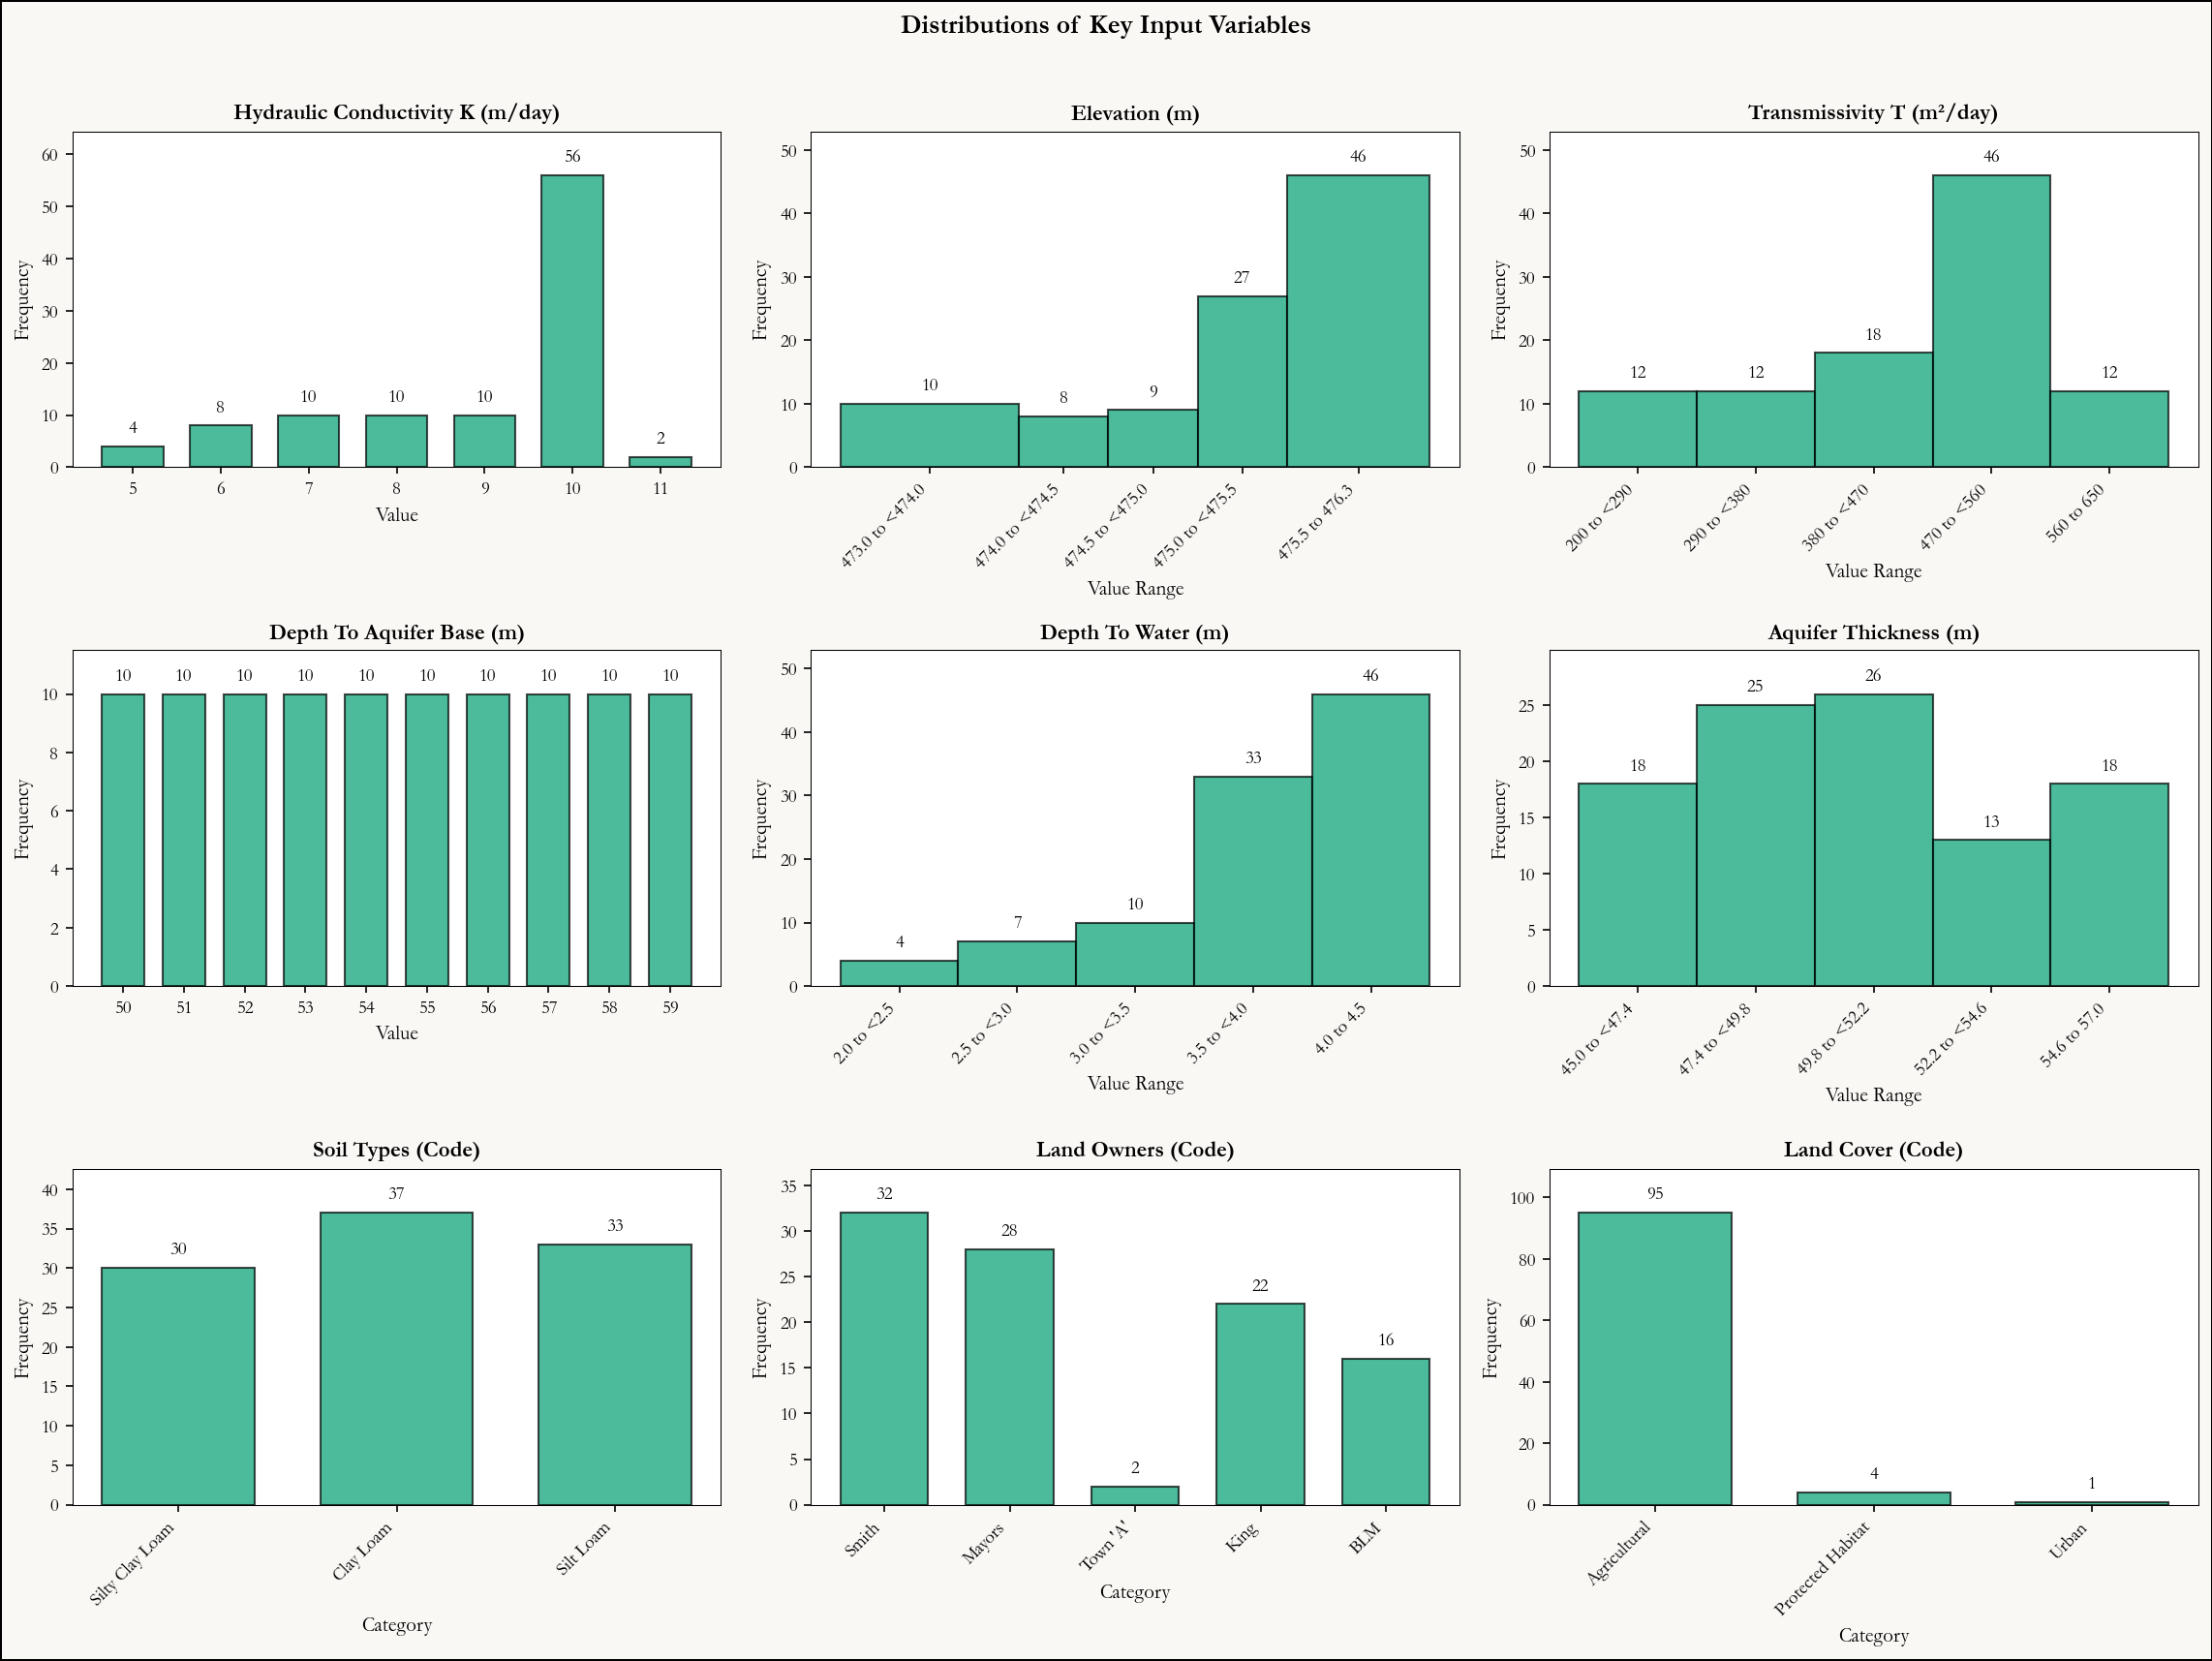

In [13]:
# Histogram visualization of input and derived variable distributions
def plot_criterion_histograms(data, derived):
    """
    Creates histograms for key input and derived datasets with scientific precision.
    - Handles discrete vs. continuous variables appropriately
    - Uses non-overlapping range boundaries with clear notation
    - Organizes plots logically by data type
    - Maintains consistent label positioning across all subplots
    """
    global fig
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), facecolor=BG_COLOR)
    axes = axes.ravel()
    fig.suptitle("Distributions of Key Input Variables", fontweight='bold', y=0.97, x=0.5, ha='center')
    fig.patch.set_linewidth(1.0); fig.patch.set_edgecolor('black')

    # Define categorical data mappings
    categorical_data = {
        "Soil Types (Code)": {
            1: "Silty Clay Loam",
            2: "Clay Loam",
            3: "Silt Loam"
        },
        "Land Cover (Code)": {
            1: "Agricultural",
            2: "Protected Habitat",
            3: "Urban"
        },
        "Land Owners (Code)": {
            1: "Smith",
            2: "Mayors",
            3: "Town 'A'",
            4: "King",
            5: "BLM"
        }
    }

    # Define variables with few discrete values that should be treated specially
    discrete_variables = [
        "Hydraulic Conductivity K (m/day)",
        "Depth To Aquifer Base (m)"
    ]

    # Variable list organized by data type (hydrogeological, depth-related, categorical)
    df_list = [
        # First row - Continuous hydrogeological variables
        ("Hydraulic Conductivity K (m/day)", data['k'].values.flatten()),
        ("Elevation (m)", data['elevation'].values.flatten()),
        ("Transmissivity T (m²/day)", derived['transmissivity'].values.flatten()),
        
        # Second row - Depth-related variables
        ("Depth To Aquifer Base (m)", data['depth_to_aquifer_base'].values.flatten()),
        ("Depth To Water (m)", data['depth_to_water'].values.flatten()),
        ("Aquifer Thickness (m)", derived['aquifer_thickness'].values.flatten()),
        
        # Third row - Categorical data
        ("Soil Types (Code)", data['soils'].values.flatten()),
        ("Land Owners (Code)", data['land_owners'].values.flatten()),
        ("Land Cover (Code)", data['land_cover'].values.flatten()),
    ]

    # Process each subplot
    for i, (name, arr) in enumerate(df_list):
        ax = axes[i]
        arr_numeric = pd.to_numeric(arr, errors='coerce')
        valid_arr = arr_numeric[~np.isnan(arr_numeric)]

        if len(valid_arr) == 0:
            # Handle empty data
            ax.set_title(f"{name}\n(No Valid Data)", fontsize=11, fontweight='bold')
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey')
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            # Initialize maximum frequency for consistent label positioning
            counts_max = 0
            
            # Handle categorical variables
            if name in categorical_data:
                # Get the category mapping and process categorical data
                categories = categorical_data[name]
                
                # Count occurrences of each category
                counts = {cat: np.sum(valid_arr == cat) for cat in categories.keys()}
                counts_max = max(counts.values()) if counts else 0
                
                # Get unique categories that appear in the data
                unique_cats = sorted(list(set(valid_arr)))
                
                # Create bar positions
                bar_positions = np.arange(len(unique_cats))
                
                # Create bars
                bars = ax.bar(
                    bar_positions,
                    [counts[cat] for cat in unique_cats],
                    color=COLOR_MODERATE,
                    edgecolor='black',
                    alpha=0.7,
                    width=0.7
                )
                
                # Set x-ticks at bar positions
                ax.set_xticks(bar_positions)
                
                # Set proper category labels
                ax.set_xticklabels(
                    [f"{categories[cat]}" for cat in unique_cats],
                    rotation=45,
                    ha='right',
                    fontsize=9
                )
                
                # Set axis labels
                ax.set_title(name, fontsize=11, fontweight='bold')
                ax.set_xlabel("Category", fontsize=10)
                ax.set_ylabel("Frequency", fontsize=10)
                
                # Use relative offset for count labels
                label_offset = counts_max * 0.03
                
                # Add count labels on top of bars
                for bar in bars:
                    height = bar.get_height()
                    ax.text(
                        bar.get_x() + bar.get_width()/2.,
                        height + label_offset,
                        f"{int(height)}",
                        ha='center',
                        va='bottom',
                        fontsize=9
                    )
            
            # Handle variables with few discrete values (like K and DTAB)
            elif name in discrete_variables:
                # Get unique values and their counts
                unique_values = np.sort(np.unique(valid_arr))
                value_counts = {val: np.sum(valid_arr == val) for val in unique_values}
                counts_max = max(value_counts.values()) if value_counts else 0
                
                # Create bar positions
                bar_positions = np.arange(len(unique_values))
                
                # Create bars
                bars = ax.bar(
                    bar_positions,
                    [value_counts[val] for val in unique_values],
                    color=COLOR_MODERATE,
                    edgecolor='black',
                    alpha=0.7,
                    width=0.7
                )
                
                # Set x-ticks at bar positions
                ax.set_xticks(bar_positions)
                
                # Set exact value labels
                ax.set_xticklabels(
                    [f"{int(val)}" for val in unique_values],
                    rotation=0,
                    fontsize=9
                )
                
                # Set axis labels
                ax.set_title(name, fontsize=11, fontweight='bold')
                ax.set_xlabel("Value", fontsize=10)
                ax.set_ylabel("Frequency", fontsize=10)
                
                # Use relative offset for count labels
                label_offset = counts_max * 0.03
                
                # Add count labels on top of bars
                for bar in bars:
                    height = bar.get_height()
                    ax.text(
                        bar.get_x() + bar.get_width()/2.,
                        height + label_offset,
                        f"{int(height)}",
                        ha='center',
                        va='bottom',
                        fontsize=9
                    )
            
            # Handle continuous variables with many unique values
            else:
                # For continuous variables, handle range binning with clear boundaries
                data_min = np.min(valid_arr)
                data_max = np.max(valid_arr)
                
                # Ensure at least some range
                if data_max - data_min < 1e-6:
                    data_min -= 0.5
                    data_max += 0.5
                
                # Set up bins based on variable type with scientific precision and non-overlapping ranges
                if name == "Depth To Water (m)":
                    # Special case for depth to water (about 2.1-4.5)
                    bin_edges = np.array([2.0, 2.5, 3.0, 3.5, 4.0, 4.5])
                    bin_ranges = ["2.0 to <2.5", "2.5 to <3.0", "3.0 to <3.5", "3.5 to <4.0", "4.0 to 4.5"]
                elif name == "Elevation (m)":
                    # Special case for elevation (473.1-476.2)
                    bin_edges = np.array([473.0, 474.0, 474.5, 475.0, 475.5, 476.3])
                    bin_ranges = ["473.0 to <474.0", "474.0 to <474.5", "474.5 to <475.0", "475.0 to <475.5", "475.5 to 476.3"]
                elif name == "Aquifer Thickness (m)":
                    # For aquifer thickness (derived)
                    # Round range boundaries for cleaner display
                    min_val = np.floor(data_min)
                    max_val = np.ceil(data_max)
                    bin_edges = np.linspace(min_val, max_val, 6)
                    
                    # Create range labels with clear boundaries
                    bin_ranges = []
                    for j in range(5):
                        if j == 4:  # Last bin is inclusive of upper bound
                            bin_ranges.append(f"{bin_edges[j]:.1f} to {bin_edges[j+1]:.1f}")
                        else:
                            bin_ranges.append(f"{bin_edges[j]:.1f} to <{bin_edges[j+1]:.1f}")
                elif name == "Transmissivity T (m²/day)":
                    # For transmissivity (derived)
                    min_val = np.floor(data_min / 50) * 50
                    max_val = np.ceil(data_max / 50) * 50
                    bin_edges = np.linspace(min_val, max_val, 6)
                    
                    # Create range labels with clear boundaries (using integers)
                    bin_ranges = []
                    for j in range(5):
                        if j == 4:  # Last bin is inclusive of upper bound
                            bin_ranges.append(f"{int(bin_edges[j])} to {int(bin_edges[j+1])}")
                        else:
                            bin_ranges.append(f"{int(bin_edges[j])} to <{int(bin_edges[j+1])}")
                else:
                    # Generic approach for other variables
                    bin_edges = np.linspace(data_min, data_max, 6)
                    
                    # Create range labels with clear boundaries
                    bin_ranges = []
                    for j in range(5):
                        if j == 4:  # Last bin is inclusive of upper bound
                            bin_ranges.append(f"{bin_edges[j]:.1f} to {bin_edges[j+1]:.1f}")
                        else:
                            bin_ranges.append(f"{bin_edges[j]:.1f} to <{bin_edges[j+1]:.1f}")
                
                # Create the histogram with defined bin edges
                n, bins, patches = ax.hist(
                    valid_arr,
                    bins=bin_edges,
                    color=COLOR_MODERATE,
                    edgecolor='black',
                    alpha=0.7
                )
                
                # Find maximum count for label positioning
                counts_max = max(n) if len(n) > 0 else 0
                
                # Set tick positions at bin centers
                bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
                ax.set_xticks(bin_centers)
                
                # Set range labels
                ax.set_xticklabels(bin_ranges, rotation=45, fontsize=8, ha='right')
                
                # Set axis labels and title
                ax.set_title(name, fontsize=11, fontweight='bold')
                ax.set_xlabel("Value Range", fontsize=10)
                ax.set_ylabel("Frequency", fontsize=10)
                
                # Calculate relative label offset
                label_offset = counts_max * 0.03
                
                # Add count labels above each bar
                for j, count in enumerate(n):
                    if count > 0:  # Only add label if there's a bar
                        ax.text(
                            bin_centers[j],
                            count + label_offset,
                            f"{int(count)}",
                            ha='center',
                            va='bottom',
                            fontsize=9
                        )
            
            # Common settings for all plot types
            ax.tick_params(axis='both', which='major', labelsize=9)
            
            # Set y-axis limit with margin for count labels
            ax.set_ylim(0, counts_max * 1.15)
        
        # Add borders to all subplots
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color('black')

    # Hide any unused subplots
    for i in range(len(df_list), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    save_and_show_figure("01_input_variable_distributions.png")

# Generate Figure 1: Input Variable Distributions
plot_criterion_histograms(data, derived)

### Figures 2-10: Spatial Parameter Maps

The following maps present the spatial distribution of each input and derived parameter across the 10×10 study grid. Parameters are organized in logical dependency order, with primary hydrogeologic inputs preceding derived quantities.

**Hydrogeological Parameters (Figures 2-7):**
- Primary inputs: Hydraulic Conductivity (K), Elevation, Depth to Water (DTW), Depth to Aquifer Base (DTAB)
- Derived parameters: Aquifer Thickness ($b = DTAB - DTW$), Transmissivity ($T = K \times b$)

**Land Classification Parameters (Figures 8-10):**
- Ownership, Environmental Sensitivity (Land Cover), Soil Characteristics

All maps display exclusion zones (hatching) and the optimal candidate location ('X' marker) for spatial reference.


Saved figure '02_hydraulic_conductivity.png' (dpi=1200).


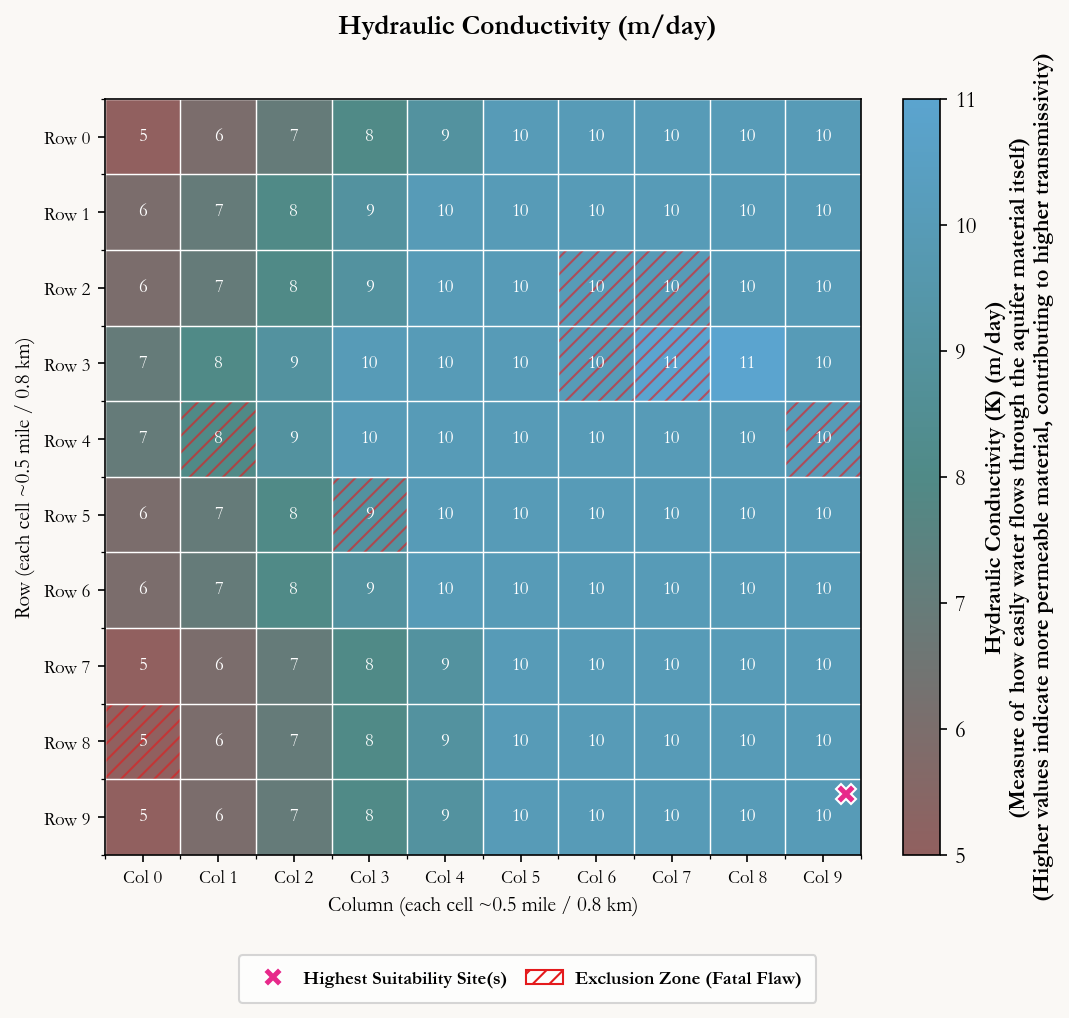

Saved figure '03_elevation.png' (dpi=1200).


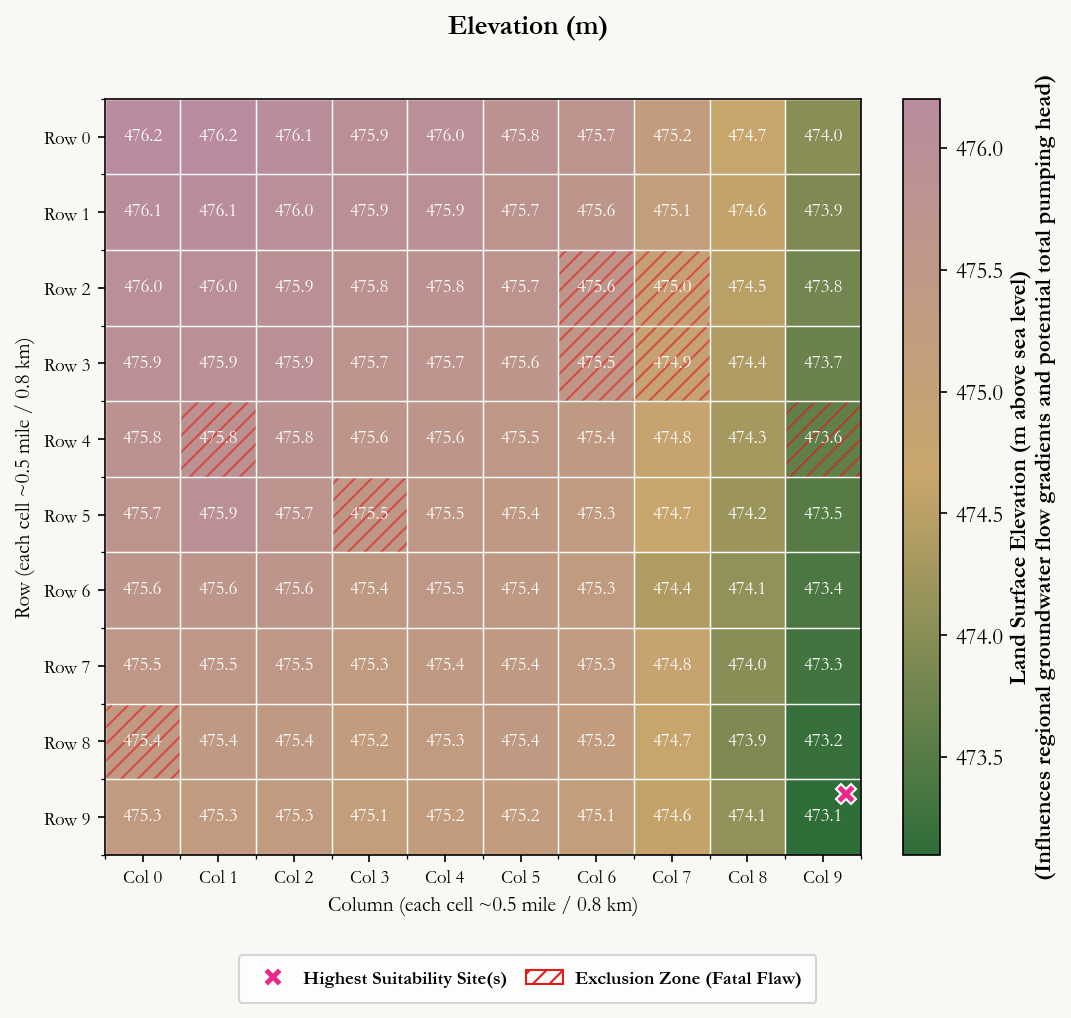

Saved figure '04_depth_to_water.png' (dpi=1200).


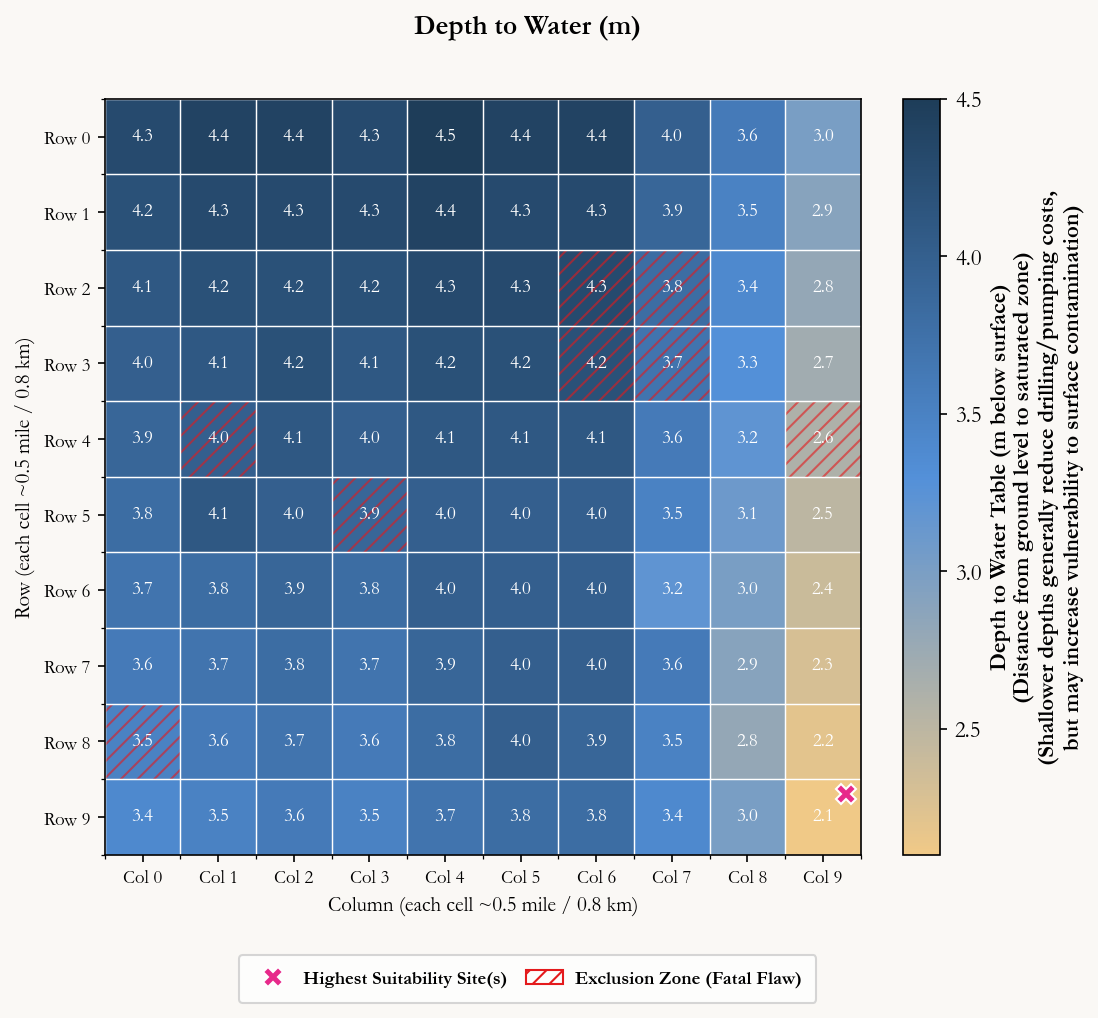

Saved figure '05_depth_to_aquifer_base.png' (dpi=1200).


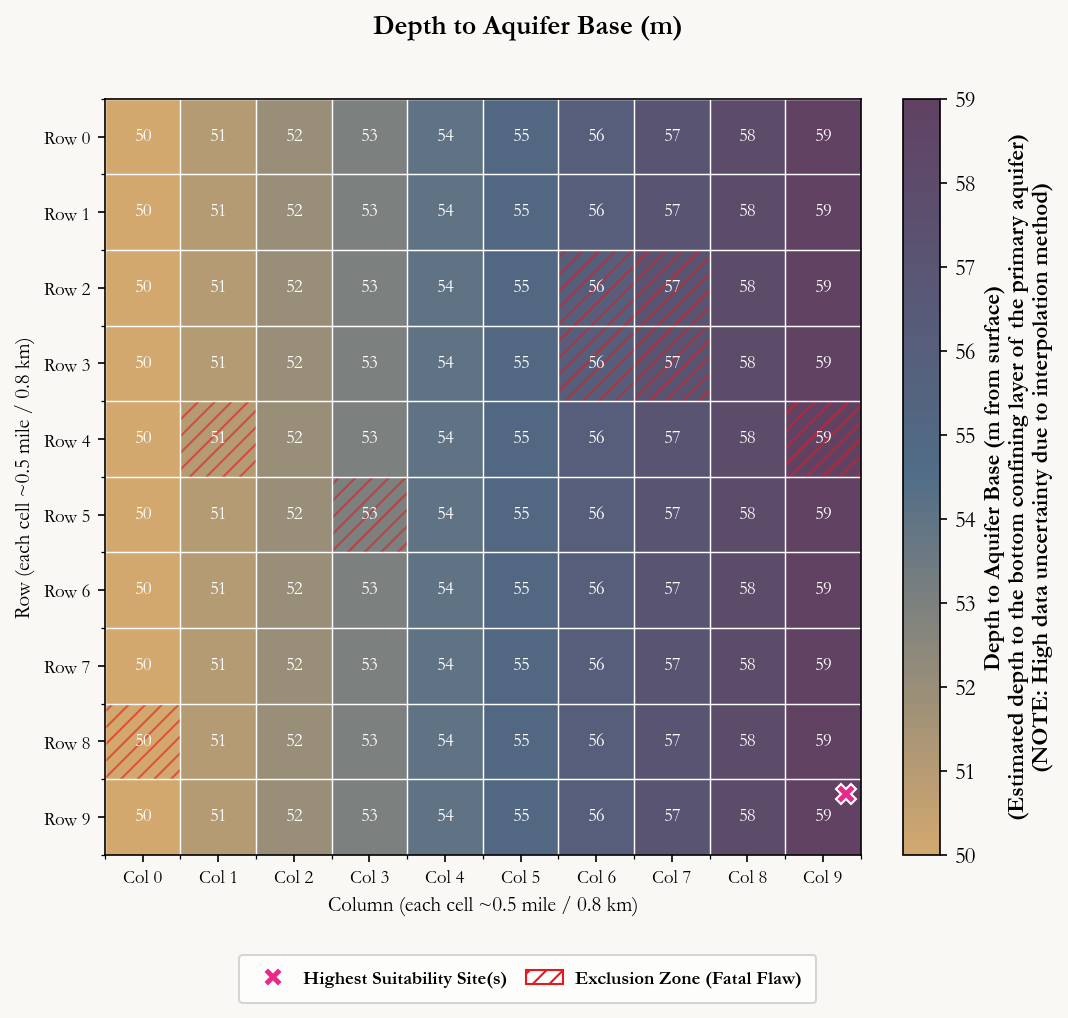

Saved figure '06_aquifer_thickness.png' (dpi=1200).


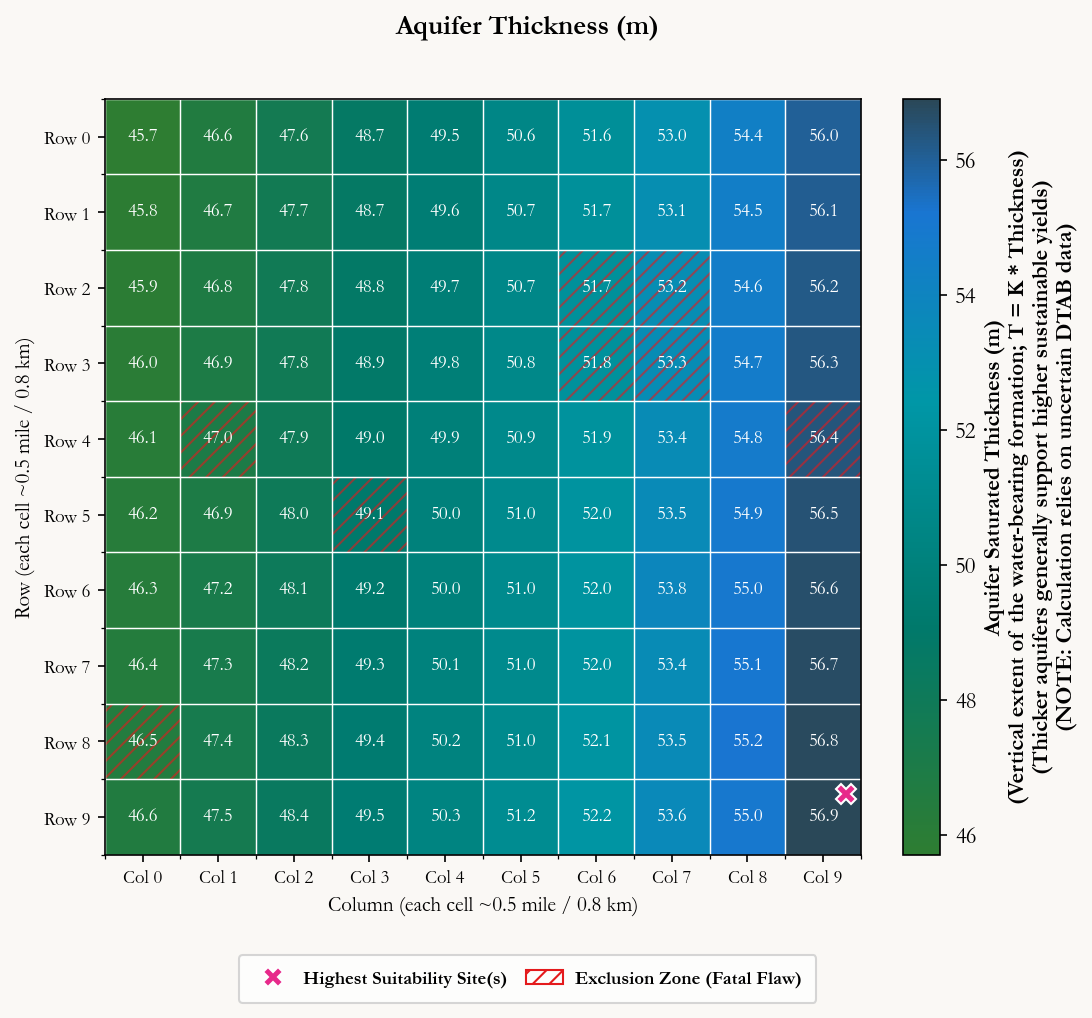

Saved figure '07_transmissivity.png' (dpi=1200).


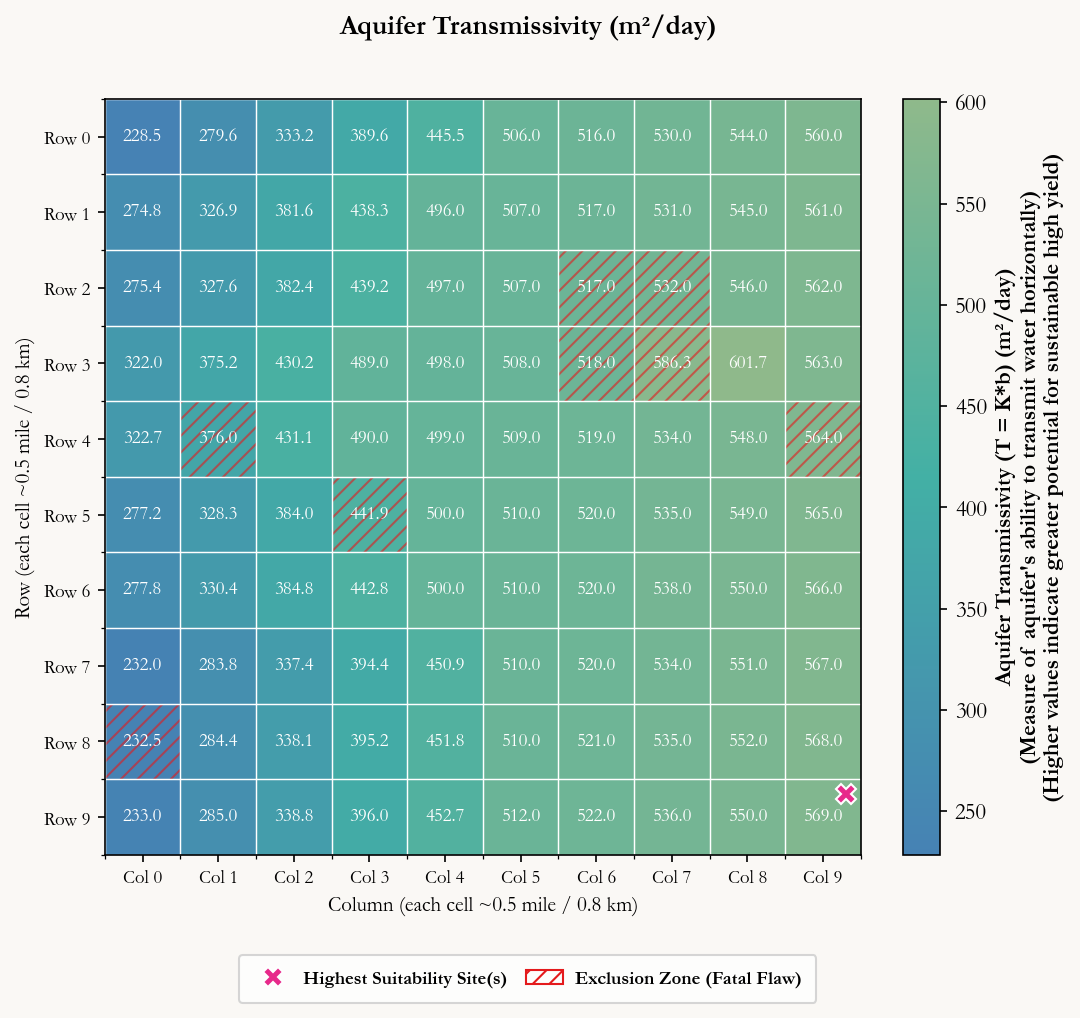

Saved figure '08_land_ownership.png' (dpi=1200).


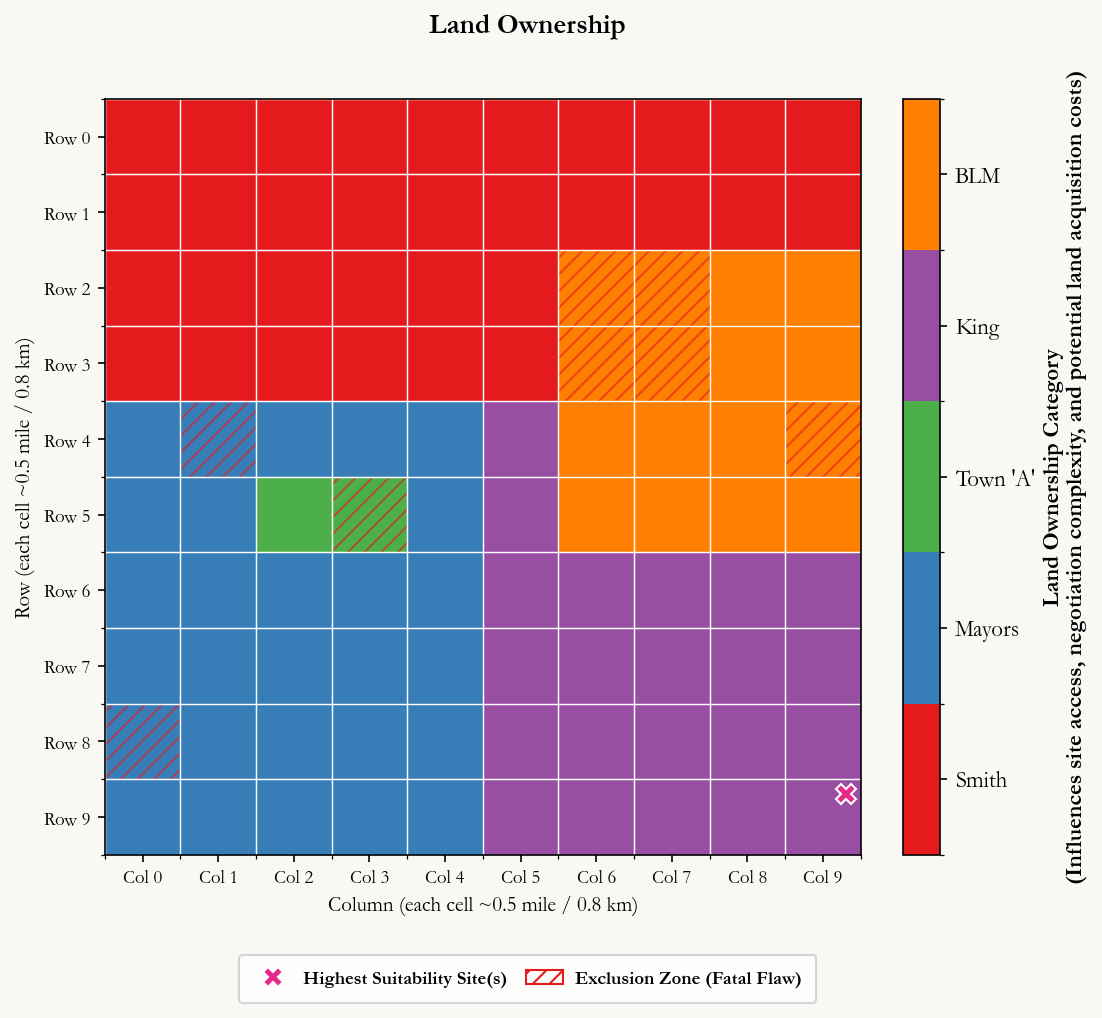

Saved figure '09_land_cover.png' (dpi=1200).


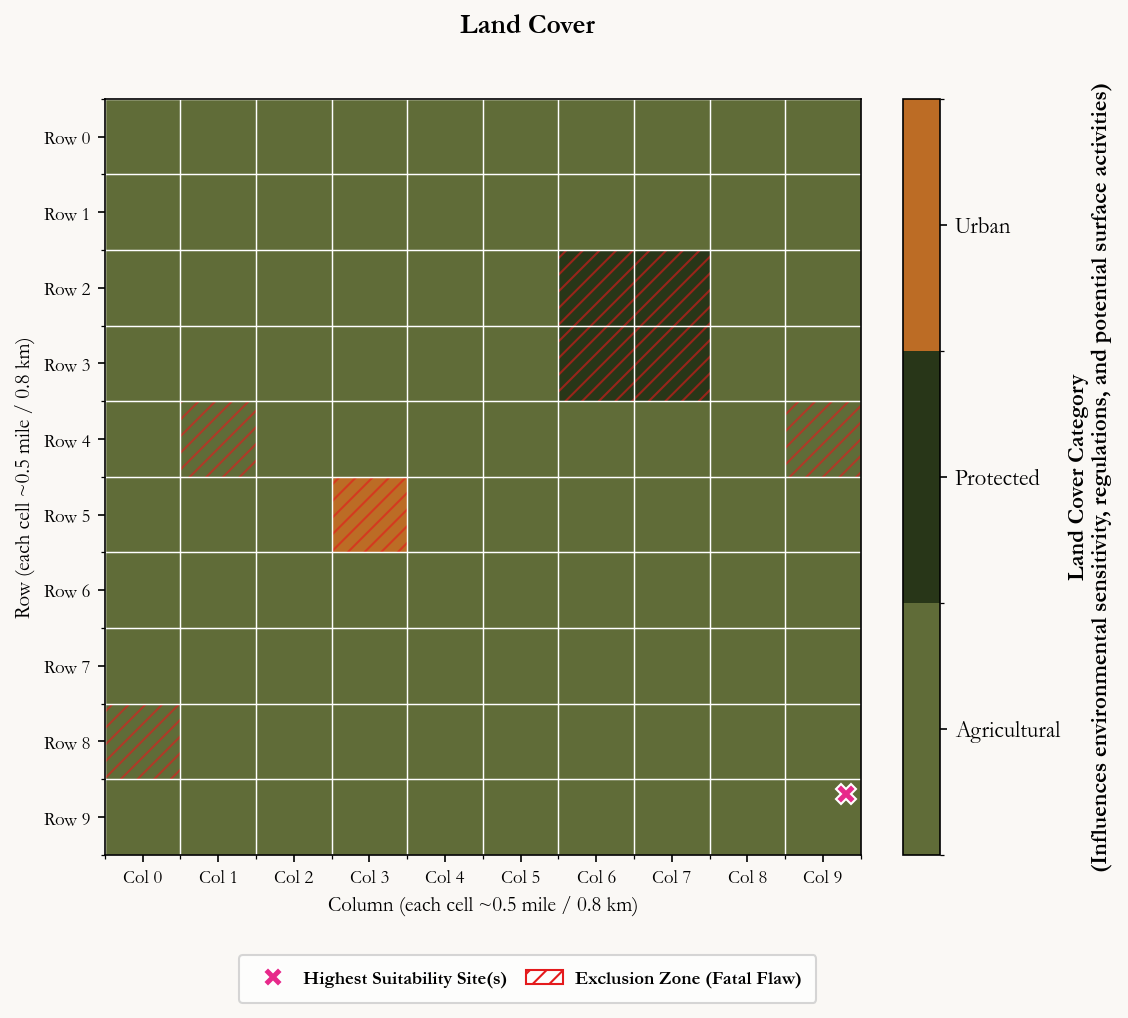

Saved figure '10_soils.png' (dpi=1200).


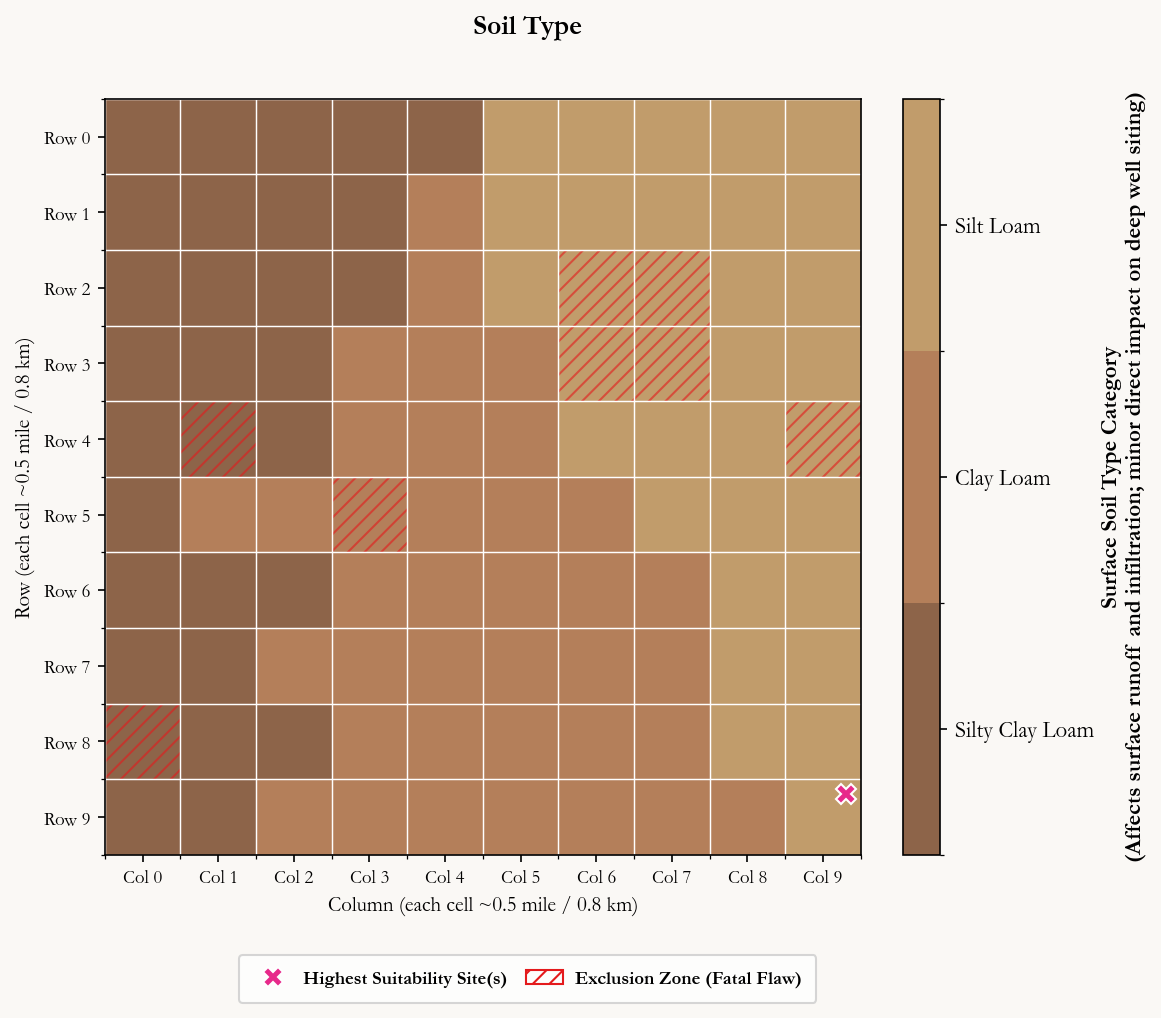

In [14]:
# Generalized heatmap plotting function for spatial parameter visualization
def plot_data_map(data_array, title, cmap, cbar_label, filename,
                  score_percentages, best_loc, fatal_flaws,
                  is_categorical=False, cat_ticks=None, cat_labels=None,
                  annotate_cells=True, dynamic_text_color=False):
    """
    Generates a spatial heatmap for a single input or derived parameter layer.
    Displays cell values, exclusion zones (fatal flaws), and optimal site marker.
    
    Args:
        dynamic_text_color: If True, compute text color (white/black) based on 
                           background luminance for optimal readability.
    """
    global fig
    # Figure dimensions: 8 x 7 inches
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG_COLOR)

    data_array_np = data_array.values if isinstance(data_array, pd.DataFrame) else np.asarray(data_array)
    rows, cols = data_array_np.shape
    data_plot = pd.to_numeric(data_array_np.flatten(), errors='coerce').reshape(rows, cols)

    # Color normalization for categorical vs. continuous data
    norm = None
    if is_categorical:
        if cat_ticks is None or cat_labels is None:
            print(f"ERROR: Categorical plot '{title}' requires cat_ticks and cat_labels.")
            plt.close(fig); fig = None; return
        # Define discrete color boundaries for categorical values
        min_tick = min(cat_ticks); max_tick = max(cat_ticks)
        bounds = np.arange(min_tick - 0.5, max_tick + 1.5, 1)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
        img = ax.imshow(data_plot, cmap=cmap, norm=norm)
        tick_locs = np.array(cat_ticks)
        cbar = fig.colorbar(img, ax=ax, ticks=tick_locs, spacing='proportional', fraction=0.046, pad=0.04)
        cbar.ax.set_yticklabels(cat_labels)
    else:
        vmin = np.nanmin(data_plot); vmax = np.nanmax(data_plot)
        if vmin == vmax: vmin -= 0.5; vmax += 0.5
        if np.isnan(vmin) or np.isnan(vmax): vmin = 0; vmax = 1
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        img = ax.imshow(data_plot, cmap=cmap, norm=norm)
        cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)

    # Colorbar Label
    cbar.set_label(cbar_label, fontsize=11, fontweight='bold')

    # Axes Ticks and Labels
    ax.set_xticks(np.arange(cols)); ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([f"Col {x}" for x in range(cols)], fontsize=9)
    ax.set_yticklabels([f"Row {y}" for y in range(rows)], fontsize=9)
    ax.set_xlabel(f"Column (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_ylabel(f"Row (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)

    # Grid Lines
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color=GRID_COLOR, linestyle='-', linewidth=0.7)

    # Add cell value annotations
    if annotate_cells:
        for i in range(rows):
            for j in range(cols):
                val = data_plot[i, j]
                if pd.isna(val): continue
                if isinstance(val, (int, np.integer)): txt = str(int(val))
                elif isinstance(val, (float, np.floating)): txt = str(round(val, 1))
                else: txt = str(val)
                
                # Compute text color based on background luminance if requested
                if dynamic_text_color and norm is not None:
                    bg_color = cmap(norm(val))
                    luminance = bg_color[0]*0.299 + bg_color[1]*0.587 + bg_color[2]*0.114
                    text_color = 'white' if luminance < 0.6 else 'black'
                else:
                    text_color = 'white'
                
                ax.text(j, i, txt, ha='center', va='center', color=text_color, fontsize=9)

    # Overlay exclusion zone hatching for fatal flaw cells
    for i in range(rows):
        for j in range(cols):
            if fatal_flaws[i, j]:
                 ax.add_patch(mpatches.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor=FATAL_HATCH_COLOR, hatch='///', lw=0.3, alpha=0.6))

    # Mark the best location(s) with 'X' marker
    if best_loc is not None:
        best_score_val_precise = score_percentages[best_loc[0], best_loc[1]]
        TOLERANCE = 1e-6
        for i in range(rows):
            for j in range(cols):
                 cell_score_perc = score_percentages[i,j]
                 if pd.isna(cell_score_perc): continue
                 if abs(cell_score_perc - best_score_val_precise) < TOLERANCE and cell_score_perc > 0:
                     ax.plot(j + 0.3, i - 0.3, marker='X', markersize=10, color=HIGHLIGHT_COLOR, markeredgecolor='white', linestyle='None')

    # Adjust figure margins for title and legend placement
    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18)
    
    # Legend handles
    best_marker_legend = mlines.Line2D([], [], color=HIGHLIGHT_COLOR, marker='X', markersize=10, linestyle='None', markeredgecolor='white', label='Highest Suitability Site(s)')
    fatal_hatch_legend = mpatches.Patch(facecolor='none', edgecolor=FATAL_HATCH_COLOR, hatch='///', label='Exclusion Zone (Fatal Flaw)')
    legend_handles = [best_marker_legend, fatal_hatch_legend]
    
    # Calculate centered positioning for title and legend
    ax_bbox = ax.get_position()
    cbar_bbox = cbar.ax.get_position()
    union_bbox = Bbox.union([ax_bbox, cbar_bbox])
    mid_x = union_bbox.x0 + union_bbox.width / 2
    title_y = union_bbox.y1 + 0.08
    legend_y = union_bbox.y0 - 0.15
    
    # Figure title
    fig.suptitle(
        title,
        fontweight='bold',
        x=mid_x,
        y=title_y,
        ha='center'
    )
    
    # Figure legend
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(mid_x, legend_y),
        bbox_transform=fig.transFigure,
        ncol=2,
        frameon=True,
        prop={'size': 9, 'weight': 'bold'},
        labelspacing=0.6, columnspacing=1.0,
        handletextpad=0.6, borderpad=0.8
    )
    
    save_and_show_figure(filename)

# Parameter-specific plotting functions (Figures 2-10)
def plot_k_map(data, score_percentages, best_loc, fatal_flaws):
     plot_data_map(data['k'], "Hydraulic Conductivity (m/day)", K_CMAP_REF,
                   'Hydraulic Conductivity (K) (m/day)\n'
                   '(Measure of how easily water flows through the aquifer material itself)\n'
                   '(Higher values indicate more permeable material, contributing to higher transmissivity)',
                   "02_hydraulic_conductivity.png", score_percentages, best_loc, fatal_flaws, annotate_cells=True)

def plot_elevation_map(data, score_percentages, best_loc, fatal_flaws):
     plot_data_map(data['elevation'], "Elevation (m)", ELEVATION_CMAP_REF,
                   'Land Surface Elevation (m above sea level)\n'
                   '(Influences regional groundwater flow gradients and potential total pumping head)',
                   "03_elevation.png", score_percentages, best_loc, fatal_flaws, annotate_cells=True)

def plot_depth_to_water_map(data, score_percentages, best_loc, fatal_flaws):
    plot_data_map(data['depth_to_water'], "Depth to Water (m)", DEPTH_TO_WATER_CMAP_REF,
                  'Depth to Water Table (m below surface)\n'
                  '(Distance from ground level to saturated zone)\n' 
                  '(Shallower depths generally reduce drilling/pumping costs,\n'
                  'but may increase vulnerability to surface contamination)',
                  "04_depth_to_water.png", score_percentages, best_loc, fatal_flaws, annotate_cells=True)

def plot_depth_to_aquifer_base_map(data, score_percentages, best_loc, fatal_flaws):
     plot_data_map(data['depth_to_aquifer_base'], "Depth to Aquifer Base (m)", DEPTH_TO_AQUIFER_BASE_CMAP_REF,
                   'Depth to Aquifer Base (m from surface)\n'
                   '(Estimated depth to the bottom confining layer of the primary aquifer)\n'
                   '(NOTE: High data uncertainty due to interpolation method)',
                   "05_depth_to_aquifer_base.png", score_percentages, best_loc, fatal_flaws, annotate_cells=True)

def plot_aquifer_thickness_map(derived, score_percentages, best_loc, fatal_flaws):
    """Generates a spatial map of derived Aquifer Thickness (b = DTAB - DTW)."""
    plot_data_map(derived['aquifer_thickness'], "Aquifer Thickness (m)", AQUIFER_THICKNESS_CMAP,
                  'Aquifer Saturated Thickness (m)\n'
                  '(Vertical extent of the water-bearing formation; T = K * Thickness)\n'
                  '(Thicker aquifers generally support higher sustainable yields)\n'
                  '(NOTE: Calculation relies on uncertain DTAB data)',
                  "06_aquifer_thickness.png", score_percentages, best_loc, fatal_flaws,
                  annotate_cells=True, dynamic_text_color=True)

def plot_transmissivity_map(derived, score_percentages, best_loc, fatal_flaws):
    plot_data_map(derived['transmissivity'], "Aquifer Transmissivity (m²/day)", TRANSMISSIVITY_CMAP_REF,
                  'Aquifer Transmissivity (T = K*b) (m²/day)\n'
                  '(Measure of aquifer\'s ability to transmit water horizontally)\n'
                  '(Higher values indicate greater potential for sustainable high yield)',
                  "07_transmissivity.png", score_percentages, best_loc, fatal_flaws, annotate_cells=True)

def plot_land_ownership_map(data, score_percentages, best_loc, fatal_flaws):
    owner_labels = ["Smith", "Mayors", "Town 'A'", "King", "BLM"]
    owner_ticks = [1, 2, 3, 4, 5]
    plot_data_map(data['land_owners'], "Land Ownership", OWNER_CMAP_REF,
                  "Land Ownership Category\n"
                  "(Influences site access, negotiation complexity, and potential land acquisition costs)",
                  "08_land_ownership.png", score_percentages, best_loc, fatal_flaws,
                  is_categorical=True, cat_ticks=owner_ticks, cat_labels=owner_labels, annotate_cells=False)

def plot_land_cover_map(data, score_percentages, best_loc, fatal_flaws):
    cover_labels = ["Agricultural", "Protected", "Urban"]
    cover_ticks = [1, 2, 3]
    plot_data_map(data['land_cover'], "Land Cover", LANDCOVER_CMAP_REF,
                  "Land Cover Category\n"
                  "(Influences environmental sensitivity, regulations, and potential surface activities)",
                  "09_land_cover.png", score_percentages, best_loc, fatal_flaws,
                  is_categorical=True, cat_ticks=cover_ticks, cat_labels=cover_labels, annotate_cells=False)

def plot_soils_map(data, score_percentages, best_loc, fatal_flaws):
    soils_labels = ["Silty Clay Loam", "Clay Loam", "Silt Loam"]
    soils_ticks = [1, 2, 3]
    plot_data_map(data['soils'], "Soil Type", SOILS_CMAP_REF,
                  "Surface Soil Type Category\n"
                  "(Affects surface runoff and infiltration; minor direct impact on deep well siting)",
                  "10_soils.png", score_percentages, best_loc, fatal_flaws,
                  is_categorical=True, cat_ticks=soils_ticks, cat_labels=soils_labels, annotate_cells=False)

# Generate Figures 2-10: Spatial Parameter Maps (in dependency order)
# Hydrogeological parameters
plot_k_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 2
plot_elevation_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 3
plot_depth_to_water_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 4
plot_depth_to_aquifer_base_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 5
plot_aquifer_thickness_map(derived, score_percentages, best_loc, fatal_flaws)  # Figure 6
plot_transmissivity_map(derived, score_percentages, best_loc, fatal_flaws)  # Figure 7
# Land classification parameters
plot_land_ownership_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 8
plot_land_cover_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 9
plot_soils_map(data, score_percentages, best_loc, fatal_flaws)  # Figure 10

---

## 12. Methodology Visualization

The prioritization analysis integrates two distinct decision support layers: (1) a weighted criteria assessment quantifying relative suitability, and (2) a binary exclusion filter identifying regulatory constraints.

Visualization of these methodological components includes:
1. **Weighting Scheme (Figure 11):** Relative importance multipliers (1–5) assigned to the nine siting criteria.
2. **Exclusion Zones (Figure 12):** Spatial distribution of absolute prohibitory constraints.


### Figure 11: Criteria Weight Multipliers

The relative importance of each hydrogeologic and logistical criterion within the Weighted Linear Combination (WLC) framework is quantified by assigned multipliers (1–5).

**Weighting Rationale:**

| Multiplier | Criteria | Basis for Assignment |
|:----------:|----------|----------------------|
| **5** | Transmissivity, Well Spacing | Primary controls on sustainable yield and hydraulic interference. |
| **4** | Aquifer Thickness, Land Ownership | Strong indicators of long-term production capacity and acquisition feasibility. |
| **3** | Distance to Town, Environmental, Depth to Water | Cost factors and regulatory considerations with moderate siting influence. |
| **1** | Depth to Aquifer Base, Soil Type | Assigned reduced weight due to high spatial uncertainty (DTAB) or minimal direct impact (Soils). |

*The low weight assigned to Depth to Aquifer Base (Multiplier = 1) reflects the substantial spatial uncertainty identified through cross-validation at well 'c', where the interpolated surface deviated by >16 m from measured depth.*


Saved figure '11_criteria_weights.png' (dpi=1200).


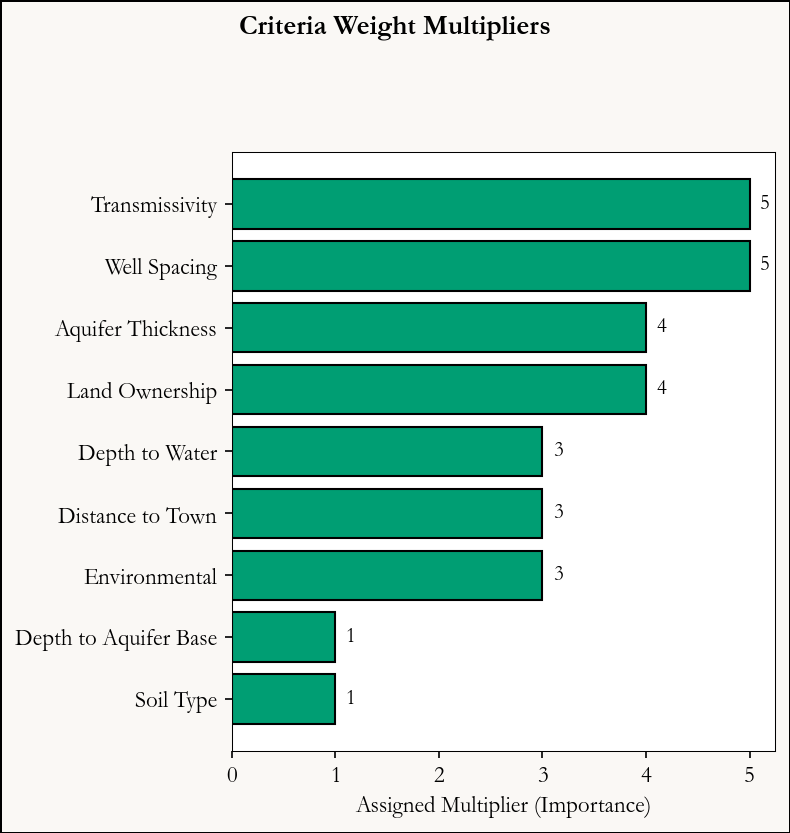

In [15]:
# --- Visualization: Criteria Weight Multipliers ---
def plot_criteria_weights_chart(criteria):
    """
    Generates a horizontal bar chart displaying the weight multipliers
    assigned to each criterion in the prioritization analysis.
    
    Args:
        criteria (list): List of dictionaries containing criterion metadata and weights.
    """
    global fig
    
    # Initialize Figure
    fig, ax = plt.subplots(figsize=(6, 6), facecolor=BG_COLOR)
    fig.suptitle("Criteria Weight Multipliers", fontweight='bold', y=0.97, x=0.5, ha='center')
    fig.patch.set_linewidth(0.5)
    fig.patch.set_edgecolor('black')

    # Prepare Data
    names = [c['name'] for c in criteria]
    weights = [c['multiplier'] for c in criteria]
    
    # Sort by weight (descending), then alphabetically for visual organization
    sorted_idx = sorted(range(len(weights)), key=lambda k: (-weights[k], names[k]))
    sorted_names = [names[i] for i in sorted_idx]
    sorted_weights = [weights[i] for i in sorted_idx]

    # Plot Bars
    bars = ax.barh(sorted_names, sorted_weights, color=COLOR_MODERATE, edgecolor='black')
    ax.set_xlabel("Assigned Multiplier (Importance)", fontsize=11)
    ax.invert_yaxis()  # Highest weights at top
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Label Bars with Exact Values
    for bar in bars:
        width = bar.get_width()
        # Position value text just outside the bar
        ax.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
                f'{int(width)}',
                ha='left', va='center', fontsize=10)

    # Style Axis Spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.9])
    save_and_show_figure("11_criteria_weights.png")

# Generate Figure 11
plot_criteria_weights_chart(criteria)

### Figure 12: Spatial Distribution of Exclusionary Constraints (Fatal Flaws)

This categorical map identifies grid cells where municipal well development is precluded by absolute regulatory or environmental constraints. These "fatal flaws" function as binary exclusion criteria; regardless of favorable hydrogeologic properties, the presence of any single constraint renders a location unsuitable for permitting.

**Constraint Classifications:**

| Code | Constraint Type | Rationale for Exclusion |
|:----:|-----------------|-------------------------|
| **1** | **Protected Habitat** | Designated conservation zones verified via USDA classification (Land Cover Code 2). |
| **2** | **Urban Infrastructure** | High-density development incompatible with sanitary wellhead protection buffers (Land Cover Code 3). |
| **3** | **Well Interference Zone** | Hydraulic interference risk; < 0.5 mile radial buffer around existing municipal wells. |
| **4** | **Combined Constraint** | Overlap of Protected Habitat and Well Interference prohibitions. |
| **5** | **Combined Constraint** | Overlap of Urban Infrastructure and Well Interference prohibitions. |

*Note: Cells with any fatal flaw are assigned a suitability score of **0%** and are excluded from the Prioritization Matrix.*



Analysis Log: Detected Fatal Flaw Categories:
  - 'Protected habitat'
  - 'Too close to well (<0.5mi)'
  - 'Urban area'
Saved figure '12_fatal_flaw_distribution.png' (dpi=1200).


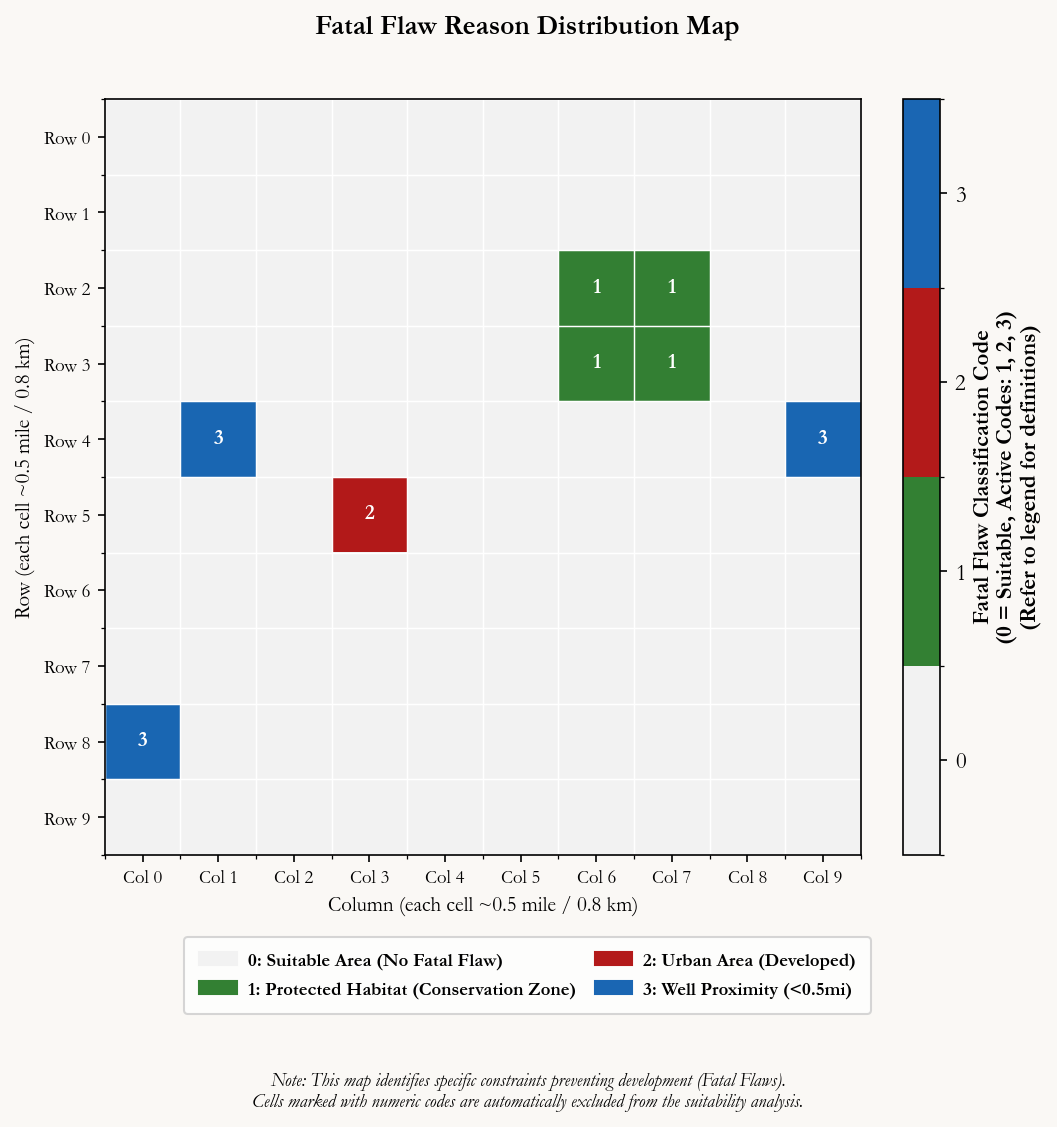

In [16]:
# --- Visualization: Fatal Flaw Reason Distribution ---
def plot_fatal_flaw_distribution(flaw_reasons, fatal_flaws, filename="12_fatal_flaw_distribution.png"):
    """
    Generates a categorical map showing the specific reasons for fatal flaw exclusions.
    
    Args:
        flaw_reasons (np.array): Array containing text descriptions of fatal flaws.
        fatal_flaws (np.array): Boolean array indicating presence of a fatal flaw.
        filename (str): Output path for the figure.
    """
    global fig
    if flaw_reasons is None or fatal_flaws is None:
        print("Log: Skipping Fatal Flaw Map - No data provided.")
        return

    rows, cols = flaw_reasons.shape

    # Define Text-to-Numeric Mapping for Visualization
    reason_map = {
        None: 0,
        "Protected habitat": 1,
        "Urban area": 2,
        "Too close to well (<0.5mi)": 3,
        "Protected habitat + Too close to well (<0.5mi)": 4,
        "Urban area + Too close to well (<0.5mi)": 5,
    }
    
    # Analysis Log: Verify data integrity
    unique_reasons = set()
    for i in range(rows):
        for j in range(cols):
            if flaw_reasons[i, j] is not None:
                unique_reasons.add(flaw_reasons[i, j])
    
    print("\nAnalysis Log: Detected Fatal Flaw Categories:")
    for reason in sorted(unique_reasons):
        print(f"  - '{reason}'")
    
    # Generate Numeric Grid
    reason_numeric = np.zeros((rows, cols), dtype=int)
    unmapped_reasons = set()
    
    for i in range(rows):
        for j in range(cols):
            reason_text = flaw_reasons[i, j]
            if reason_text in reason_map:
                reason_numeric[i, j] = reason_map[reason_text]
            elif reason_text is not None:
                unmapped_reasons.add(reason_text)
                reason_numeric[i, j] = 99  # Code for Unmapped/Unknown types
    
    if unmapped_reasons:
        print("\nWarning: Unmapped fatal flaw reasons detected (plotted as Code 99):")
        for reason in unmapped_reasons:
            print(f"  - '{reason}'")
    
    # Identify Active Codes
    unique_codes = sorted(list(set(reason_numeric.flatten())))
    unique_codes_nonzero = [c for c in unique_codes if c > 0 and c != 99]
    
    # Define Color Palette (Scientifically Distinct)
    # 0: Light Grey (Suitable)
    # 1: Green (Environmental/Habitat)
    # 2: Red (Urban/Infrastructure)
    # 3: Blue (Hydrologic/Wells)
    # 4/5: Blends for combinations
    colors = [
        (0.95, 0.95, 0.95, 1.0),    # 0: Suitable
        (0.20, 0.50, 0.20, 1.0),    # 1: Protected Habitat
        (0.70, 0.10, 0.10, 1.0),    # 2: Urban Area
        (0.10, 0.40, 0.70, 1.0),    # 3: Well Proximity
        (0.15, 0.45, 0.45, 1.0),    # 4: Combined (Green + Blue-ish)
        (0.45, 0.25, 0.40, 1.0),    # 5: Combined (Red + Blue-ish)
        (0.50, 0.50, 0.50, 1.0)     # 99: Fallback Gray
    ]
    
    # Initialize Figure
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    # Build Dynamic Colormap
    cmap_colors = [colors[0]]  # Base color
    
    for code in unique_codes_nonzero:
        if code < len(colors):
            cmap_colors.append(colors[code])
    
    if 99 in unique_codes:
        cmap_colors.append(colors[-1])
    
    custom_cmap = mcolors.ListedColormap(cmap_colors)
    
    # Define Boundary Norm
    if len(unique_codes) <= 1:
        bounds = [-0.5, 0.5]
        norm = mcolors.BoundaryNorm(bounds, len(cmap_colors))
    else:
        bounds = []
        if 0 in unique_codes:
            bounds.extend([-0.5, 0.5])
        
        for code in unique_codes:
            if code > 0 and code != 99:
                bounds.extend([code - 0.5, code + 0.5])
        
        if 99 in unique_codes:
            bounds.extend([98.5, 99.5])
        
        bounds = sorted(list(set(bounds)))
        norm = mcolors.BoundaryNorm(bounds, len(cmap_colors))
    
    # Plot Image
    img = ax.imshow(reason_numeric, cmap=custom_cmap, norm=norm)
    
    # Configure Colorbar
    cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    
    tick_positions = []
    tick_labels = []
    
    if 0 in unique_codes:
        tick_positions.append(0)
        tick_labels.append("0")
    
    for code in unique_codes:
        if code > 0 and code != 99:
            tick_positions.append(code)
            tick_labels.append(str(code))
    
    if 99 in unique_codes:
        tick_positions.append(99)
        tick_labels.append("99")
    
    cbar.set_ticks(tick_positions)
    cbar.set_ticklabels(tick_labels)
    
    actual_types_str = ", ".join(str(c) for c in unique_codes_nonzero) if unique_codes_nonzero else "None"
    cbar.set_label(
        f"Fatal Flaw Classification Code\n"
        f"(0 = Suitable, Active Codes: {actual_types_str})\n"
        "(Refer to legend for definitions)",
        fontsize=11, fontweight='bold'
    )
    
    # Annotate Grid Cells
    for i in range(rows):
        for j in range(cols):
            code = reason_numeric[i, j]
            if code > 0:
                ax.text(j, i, str(code), ha='center', va='center', 
                       color='white', fontsize=10, fontweight='bold')

    # Axis Setup
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([f"Col {x}" for x in range(cols)], fontsize=9)
    ax.set_yticklabels([f"Row {y}" for y in range(rows)], fontsize=9)
    ax.set_xlabel(f"Column (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_ylabel(f"Row (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    
    # Grid Lines (White on color)
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.7)

    # Layout Adjustments
    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18)
    
    # Construct Legend (Dynamic based on data)
    legend_patches = []
    legend_patches.append(mpatches.Patch(color=colors[0], label="0: Suitable Area (No Fatal Flaw)"))
    
    for code in unique_codes_nonzero:
        label = f"{code}: Unknown"
        if code == 1: label = "1: Protected Habitat (Conservation Zone)"
        elif code == 2: label = "2: Urban Area (Developed)"
        elif code == 3: label = "3: Well Proximity (<0.5mi)"
        elif code == 4: label = "4: Protected Habitat + Well Proximity"
        elif code == 5: label = "5: Urban Area + Well Proximity"
            
        legend_patches.append(mpatches.Patch(color=colors[code] if code < len(colors) else colors[-1], label=label))
    
    if 99 in unique_codes:
        legend_patches.append(mpatches.Patch(color=colors[-1], label="99: Unmapped Constraint"))

    # Titles and Notes
    ax_bbox = ax.get_position()
    cbar_bbox = cbar.ax.get_position()
    union_bbox = Bbox.union([ax_bbox, cbar_bbox])
    mid_x = union_bbox.x0 + union_bbox.width / 2
    title_y = union_bbox.y1 + 0.08
    legend_y = union_bbox.y0 - 0.16
    
    fig.suptitle(
        "Fatal Flaw Reason Distribution Map",
        fontweight='bold',
        x=mid_x,
        y=title_y,
        ha='center'
    )
    
    fig.text(
        mid_x, legend_y - 0.08, 
        "Note: This map identifies specific constraints preventing development (Fatal Flaws).\n" 
        "Cells marked with numeric codes are automatically excluded from the suitability analysis.",
        ha='center', fontsize=9, style='italic', multialignment='center'
    )
    
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        bbox_to_anchor=(mid_x, legend_y),
        bbox_transform=fig.transFigure,
        ncol=2,
        frameon=True,
        prop={'size': 9, 'weight': 'bold'},
        labelspacing=0.6, columnspacing=1.0,
        handletextpad=0.6, borderpad=0.8
    )
    
    save_and_show_figure(filename)

# Generate Figure 12: Fatal Flaw Distribution
plot_fatal_flaw_distribution(fatal_reasons, fatal_flaws)

---

<a name="13-results-suitability-analysis-and-site-selection"></a>
## 13. Results: Suitability Analysis and Site Selection

The integration of nine hydrogeologic and logistical factors through the weighted linear combination (WLC) method provides a spatial assessment of municipal well suitability. This analysis delineates areas with optimal conditions for high-yield, sustainable groundwater extraction while minimizing conflicts with existing infrastructure and protected lands.

The results are presented as follows:
1.  **Prioritization Matrix (Figure 13):** Spatial distribution of final suitability scores (0–100%).
2.  **Suitability Category Distribution (Figure 14):** Quantification of land area within defined potentiality classes.
3.  **Optimal Site Characterization (Figure 15):** Detailed criteria profile for the highest-ranked candidate location.


### Figure 13: Prioritization Matrix for Municipal Well Siting

The Prioritization Matrix (Figure 13) visualizes the calculated suitability scores for all grid cells not excluded by fatal flaws. This heatmap identifies spatial trends in well-siting feasibility, distinguishing high-potential zones from marginal or unsuitable areas.

**Suitability Classification Scheme:**

| Score Range | Classification | Site Characterization |
|:-----------:|----------------|-----------------------|
| **> 80%** | **High Potential** | **Primary Targets:** Conditions strongly favor development; priority for field investigation. |
| **66 – 80%** | **Moderate Potential** | **Secondary Targets:** Favorable conditions with minor constraints; viable contingency options. |
| **51 – 65%** | **Low Potential** | **Marginal:** Multiple constraints limit feasibility. |
| **< 51%** | **Below Threshold** | **Unsuitable:** Hydrogeologic or logistical factors preclude development. |
| **FF** | **Fatal Flaw** | **Excluded:** Regulatory or environmental restrictions apply. |

*The grid cell achieving the maximum suitability score is marked with an 'X' to denote the analytically optimal location.*


Saved figure '13_prioritization_matrix.png' (dpi=1200).


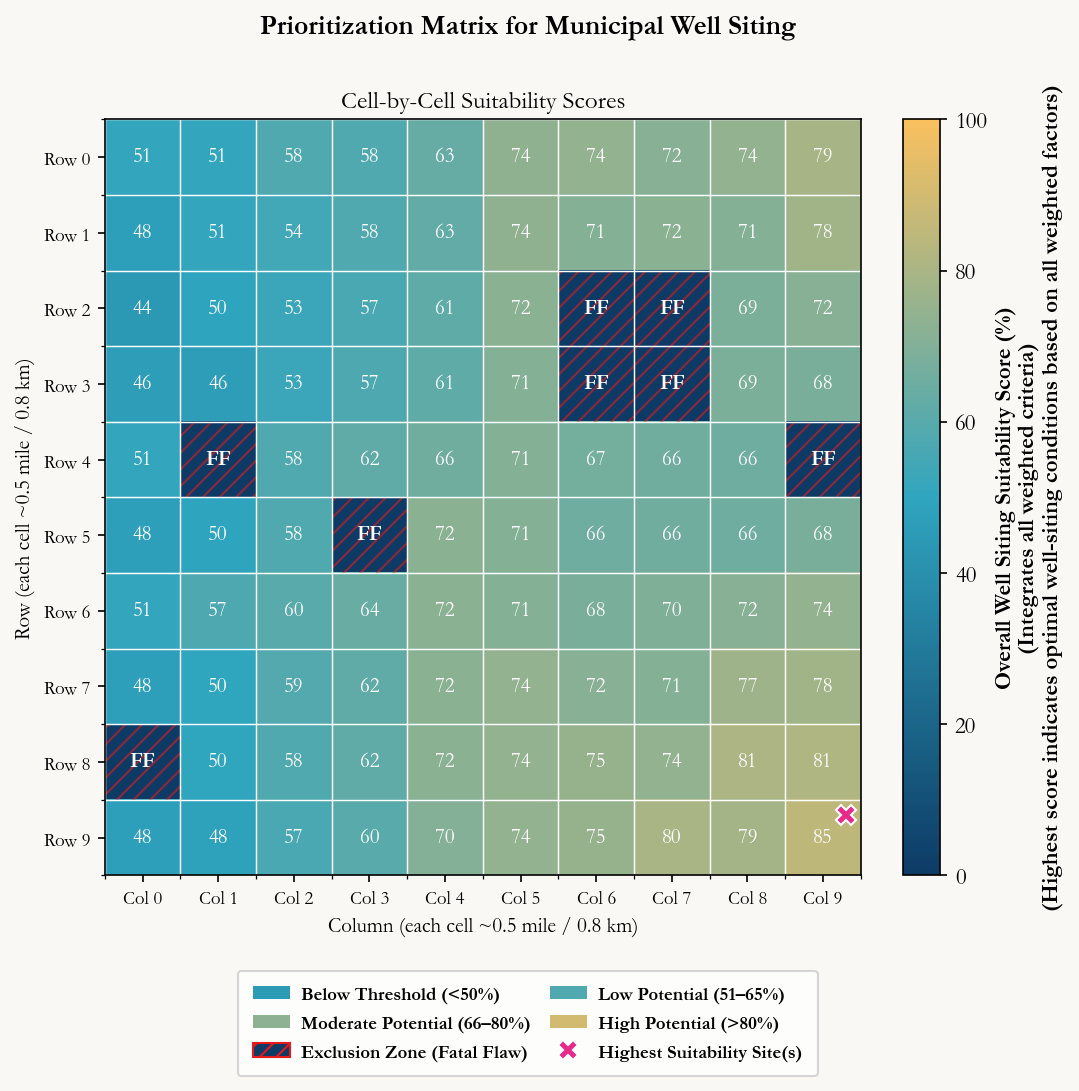

In [17]:
# --- Visualization: Prioritization Matrix (Primary Result) ---
def plot_prioritization_matrix(score_percentages, fatal_flaws, best_loc):
    """
    Generates the final Prioritization Matrix (Figure 13), a heatmap of cell-by-cell 
    suitability scores with fatal flaw exclusions and optimal site highlighting.

    Args:
        score_percentages (np.array): Grid of calculated suitability scores.
        fatal_flaws (np.array): Boolean grid indicating fatal flaws.
        best_loc (tuple): Coordinates (row, col) of the highest scoring cell.
    """
    # Create Figure and Axis
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG_COLOR)

    ax.set_title("Cell-by-Cell Suitability Scores", fontsize=12)

    # Configure Heatmap
    cmap = PRIORITIZATION_CMAP
    norm = mpl.colors.Normalize(vmin=0, vmax=100)
    img = ax.imshow(score_percentages, cmap=cmap, norm=norm)

    # Add Colorbar
    cbar = fig.colorbar(
        img,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )
    cbar.set_label(
        "Overall Well Siting Suitability Score (%)\n"
        "(Integrates all weighted criteria)\n"
        "(Highest score indicates optimal well-siting conditions based on all weighted factors)",
        fontsize=11, fontweight='bold'
    )

    rows, cols = score_percentages.shape
    
    # Configure Axes Ticks and Labels
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([f"Col {x}" for x in range(cols)], fontsize=9)
    ax.set_yticklabels([f"Row {y}" for y in range(rows)], fontsize=9)
    
    # Axis Descriptions with Spatial Scale
    ax.set_xlabel(f"Column (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_ylabel(f"Row (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)

    # Configure Grid Lines
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color=GRID_COLOR, linestyle='-', linewidth=0.7)

    # Annotate Cells
    for i in range(rows):
        for j in range(cols):
            if fatal_flaws[i, j]:
                # Excluded Cells
                txt = "FF"
                ax.add_patch(mpatches.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor=FATAL_HATCH_COLOR, hatch='///', lw=0.3, alpha=0.6))
                ax.text(j, i, txt, ha='center', va='center', color='white', fontsize=10, fontweight='bold')
            else:
                score_val = score_percentages[i, j]
                if pd.notna(score_val):
                     # Valid Score: Round to integer
                     txt = str(int(round(score_val, 0)))
                     ax.text(j, i, txt, ha='center', va='center', color='white', fontsize=10)

    # Highlight Optimal Location
    if best_loc is not None:
         best_score_val_precise = score_percentages[best_loc[0], best_loc[1]]
         TOLERANCE = 1e-6
         for i in range(rows):
             for j in range(cols):
                 cell_score_perc = score_percentages[i,j]
                 if pd.isna(cell_score_perc): continue
                 
                 # Identify matching top scores
                 if abs(cell_score_perc - best_score_val_precise) < TOLERANCE and cell_score_perc > 0:
                     ax.plot(
                         j + 0.3, i - 0.3, 
                         marker='X', 
                         markersize=10, 
                         color=HIGHLIGHT_COLOR, 
                         markeredgecolor='white', 
                         linestyle='None'
                     )

    # Create Legend
    # Define color patches based on classification thresholds
    below_thresh_color = cmap(norm(45))  # <50%
    low_color = cmap(norm(58))           # 51-65%
    moderate_color = cmap(norm(73))      # 66-80%
    high_color = cmap(norm(90))          # >80%

    below_thresh_patch = mpatches.Patch(facecolor=below_thresh_color, label='Below Threshold (<50%)')
    low_patch = mpatches.Patch(facecolor=low_color, label='Low Potential (51–65%)')
    moderate_patch = mpatches.Patch(facecolor=moderate_color, label='Moderate Potential (66–80%)')
    high_patch = mpatches.Patch(facecolor=high_color, label='High Potential (>80%)')
    
    # Fatal Flaw Entry
    fatal_fill_color = PRIORITIZATION_CMAP(0.0)
    fatal_hatch_legend = mpatches.Patch(facecolor=fatal_fill_color, edgecolor=FATAL_HATCH_COLOR, hatch='///', label='Exclusion Zone (Fatal Flaw)')

    # Optimal Site Entry
    best_marker_legend = mlines.Line2D(
        [], [], color=HIGHLIGHT_COLOR, marker='X', markersize=10, linestyle='None',
        markeredgecolor='white', label='Highest Suitability Site(s)'
    )
    
    legend_handles = [below_thresh_patch, moderate_patch, fatal_hatch_legend, low_patch, high_patch, best_marker_legend]

    # Adjust Layout
    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18)
    
    # Position Title
    ax_bbox   = ax.get_position()
    cbar_bbox = cbar.ax.get_position()
    union_bbox = Bbox.union([ax_bbox, cbar_bbox])
    mid_x = union_bbox.x0 + union_bbox.width / 2
    title_y = union_bbox.y1 + 0.1

    fig.suptitle(
      "Prioritization Matrix for Municipal Well Siting",
      fontweight='bold',
      x=mid_x,
      y=title_y,
      ha='center'
    )

    # Position Legend
    legend_y = union_bbox.y0 - 0.2

    fig.legend(
        handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(mid_x, legend_y),
        bbox_transform=fig.transFigure,
        ncol=2,
        frameon=True,
        prop={'size': 9, 'weight': 'bold'},
        labelspacing=0.6, columnspacing=1.0,
        handletextpad=0.6, borderpad=0.8
    )

    save_and_show_figure("13_prioritization_matrix.png")

# Generate Figure 13: Prioritization Matrix
plot_prioritization_matrix(score_percentages, fatal_flaws, best_loc)

### Figure 14: Suitability Category Distribution

This pie chart summarizes the proportional distribution of the study area's grid cells across defined suitability categories. It provides a high-level overview of the total land area available for potential municipal well development.

**Category Definitions:**
- **High Potential (>80%)**: Locations exhibiting consistently optimal conditions across critical hydrogeologic and logistical criteria.
- **Moderate Potential (66-80%)**: Favorable candidates that may have minor limitations.
- **Low Potential (51-65%)**: Marginal sites with multiple significant constraints.
- **Below Threshold (<51%)**: Unsuitable locations due to poor hydrogeologic properties or logistical challenges.
- **Exclusion Zone**: Sites rejected due to fatal flaws (e.g., regulatory setbacks, environmental restrictions).


Saved figure '14_suitability_distribution.png' (dpi=1200).


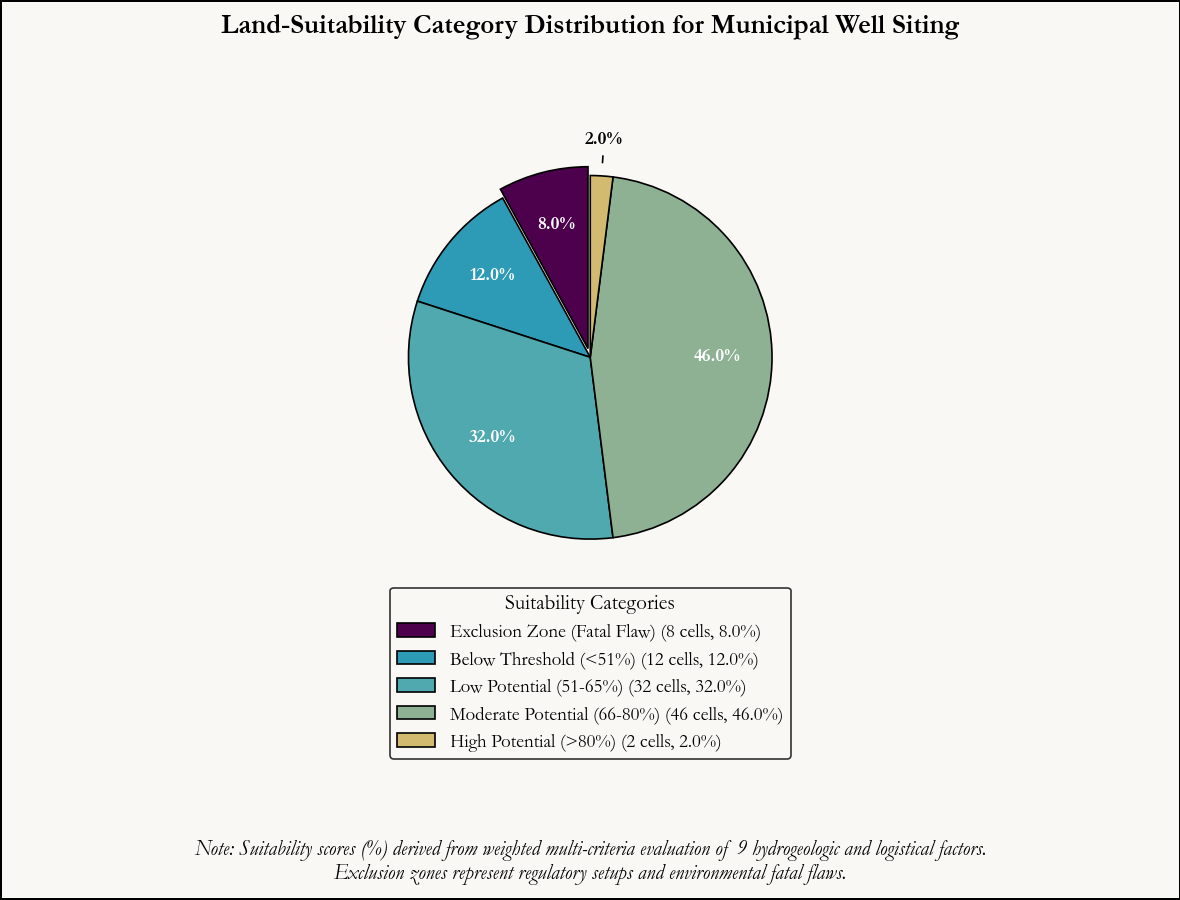

In [18]:
# --- Visualization: Suitability Category Distribution ---
def plot_suitability_distribution(score_percentages, fatal_flaws):
    """
    Generates a pie chart visualizing the distribution of 
    land-suitability classes across the study area.
    
    Features:
    - Categorical binning aligned with the Prioritization Matrix logic.
    - Intelligent label placement (internal for large slices, external leaders for small slices).
    - Scientific color scheme consistent with spatial maps.

    Args:
        score_percentages (np.array): Grid of suitability scores (0-100).
        fatal_flaws (np.array): Boolean grid of exclusion zones.
    """
    # Initialize Figure
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG_COLOR)
    fig.patch.set_linewidth(1.0)
    fig.patch.set_edgecolor('black')
    fig.suptitle("Land-Suitability Category Distribution for Municipal Well Siting",
                 fontweight='bold', fontsize=13, y=0.97)

    # Define Classification Bins and Colors
    cmap  = PRIORITIZATION_CMAP
    norm  = mpl.colors.Normalize(vmin=0, vmax=100)

    categories_map = {
        'Exclusion Zone (Fatal Flaw)' : {'threshold': 0,   'color': COLOR_FATAL},
        'Below Threshold (<51%)'      : {'threshold': 51,  'color': cmap(norm(45))},
        'Low Potential (51-65%)'      : {'threshold': 66,  'color': cmap(norm(58))},
        'Moderate Potential (66-80%)' : {'threshold': 81,  'color': cmap(norm(73))},
        'High Potential (>80%)'       : {'threshold': 101, 'color': cmap(norm(90))}
    }
    category_order = list(categories_map.keys())

    # Bin Data into Categories
    category_counts = {cat: 0 for cat in category_order}
    scores_flat     = score_percentages.flatten()
    flaws_flat      = fatal_flaws.flatten()
    total_cells     = scores_flat.size

    for score, flaw in zip(scores_flat, flaws_flat):
        if flaw:
            category_counts['Exclusion Zone (Fatal Flaw)'] += 1
        elif score < categories_map['Below Threshold (<51%)']['threshold']:
            category_counts['Below Threshold (<51%)'] += 1
        elif score < categories_map['Low Potential (51-65%)']['threshold']:
            category_counts['Low Potential (51-65%)'] += 1
        elif score < categories_map['Moderate Potential (66-80%)']['threshold']:
            category_counts['Moderate Potential (66-80%)'] += 1
        else:
            category_counts['High Potential (>80%)'] += 1

    # Prepare Plotting Data
    sizes, pie_colors, explode, legend_labels = [], [], [], []
    for cat in category_order:
        cnt = category_counts[cat]
        if cnt == 0:                       # Skip empty categories
            continue
        pct = 100.0 * cnt / total_cells
        sizes.append(cnt)
        pie_colors.append(categories_map[cat]['color'])
        explode.append(0.05 if cat.startswith('Exclusion') else 0)
        legend_labels.append(f"{cat} ({cnt} cells, {pct:.1f}%)")

    if not sizes:
        ax.text(0.5, 0.5, "No valid cells to display",
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        return

    # Convert hex colors to RGBA for matplotlib compatibility
    rgba_pie_colors = [mpl.colors.to_rgba(c) for c in pie_colors]

    # Plot Pie Chart
    # Label logic: Show percentage only if slice >= 5%
    def _internal_label(pct):
        return f"{pct:.1f}%" if pct >= 5 else ""

    wedges, texts, autotexts = ax.pie(
        sizes, colors=rgba_pie_colors, startangle=90,
        explode=explode, autopct=_internal_label, pctdistance=0.70,
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})

    # Style Internal Labels
    for tx in autotexts:
        if tx.get_text():
            tx.set_color('white')
            tx.set_fontsize(9)
            tx.set_fontweight('bold')

    # Add External Labels for Small Slices (<5%)
    for w, cnt in zip(wedges, sizes):
        pct = 100.0 * cnt / total_cells
        if pct < 5:
            theta = np.deg2rad((w.theta1 + w.theta2) / 2.0)
            # Position label outside with leader line
            x, y  = 1.05 * np.cos(theta), 1.05 * np.sin(theta)
            ax.annotate(f"{pct:.1f}%",
                        xy=(x, y),
                        xytext=(1.20 * np.cos(theta), 1.20 * np.sin(theta)),
                        ha='center', va='center', fontsize=9, fontweight='bold',
                        arrowprops=dict(arrowstyle='-', lw=0.8, color='black'))

    ax.axis('equal')

    # Legend and Notes
    legend = ax.legend(
        wedges, legend_labels, title="Suitability Categories",
        loc='upper center', bbox_to_anchor=(0.5, -0.05),
        fontsize=9, title_fontsize=10,
        frameon=True, edgecolor='black', facecolor=BG_COLOR)
    legend.get_frame().set_linewidth(0.8)

    plt.figtext(0.5, 0.01,
                "Note: Suitability scores (%) derived from weighted multi-criteria evaluation of 9 hydrogeologic and logistical factors.\n"
                "Exclusion zones represent regulatory setups and environmental fatal flaws.",
                ha='center', fontsize=10, style='italic')

    plt.tight_layout(rect=[0, 0.1, 1, 0.93])
    save_and_show_figure("14_suitability_distribution.png")

# Generate Figure 14
plot_suitability_distribution(score_percentages, fatal_flaws)

### Figure 15: Criteria Score Profile for Optimal Site Candidate

A detailed profile of the individual criterion scores (ranked 1-5) for the highest-ranked site candidate is presented in the radar chart below. This visualization reveals the specific strengths and potential limitations of the recommended location.

**Interpretation:**
- **Outer Edge (Rank 5):** Indicates maximum suitability for that criterion (e.g., ideal Aquifer Thickness).
- **Center (Rank 1):** Indicates minimal suitability or a potential constraint.
- **Polygon Shape:** A full, expansive polygon represents a location with balanced, high-quality hydrogeologic features, while indentations highlight specific factors that may require mitigation or field verification.


Saved figure '15_optimal_site_profile.png' (dpi=1200).


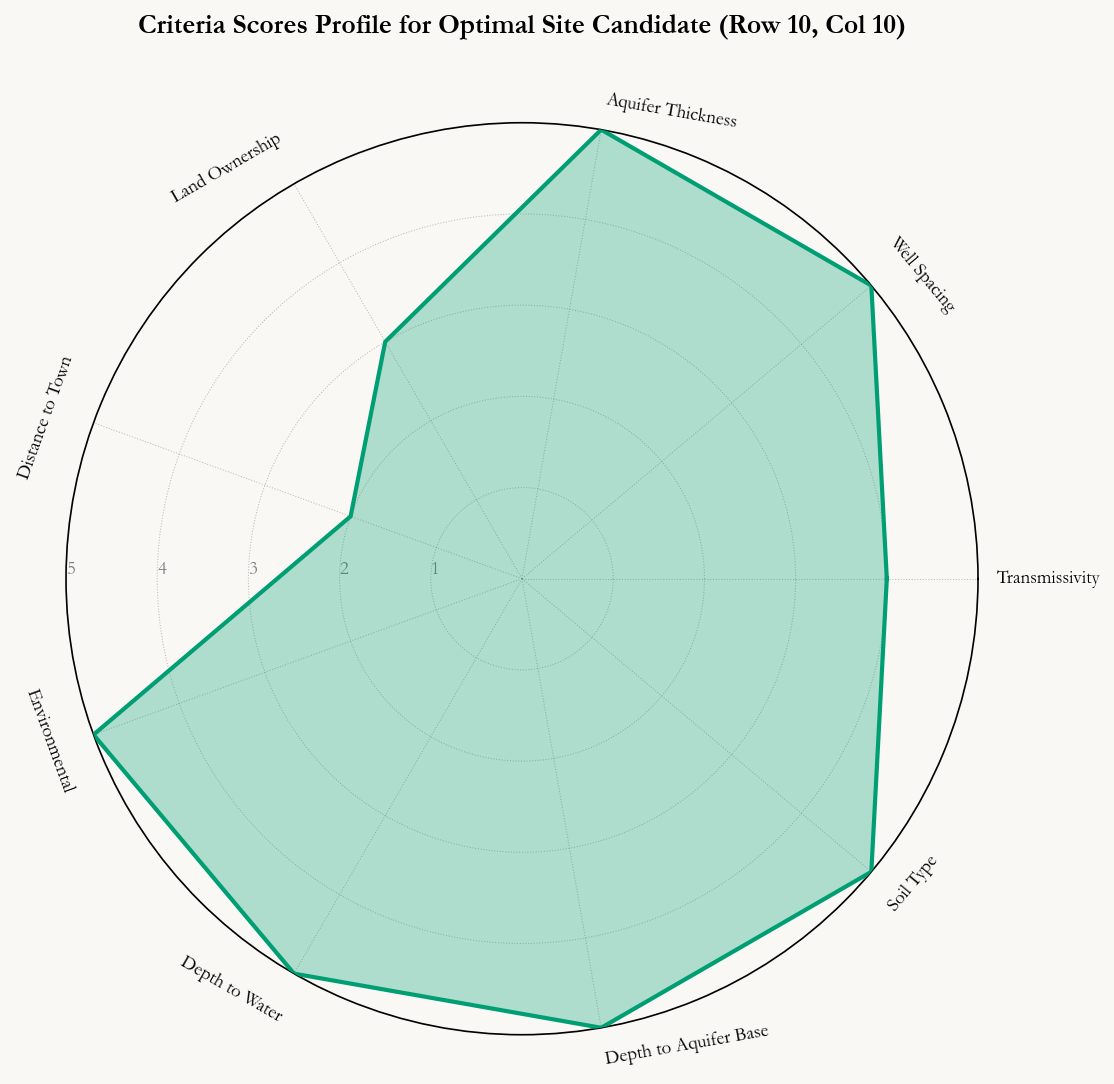

In [19]:
# --- Visualization: Criteria Score Profile (Radar Chart) ---
def plot_criteria_score_profile(scores, criteria, best_loc):
    """
    Generates a polar radar chart displaying the criteria ranking profile (1-5 scale) 
    for the identified optimal location.
    
    Args:
        scores (dict): Dictionary of score grids.
        criteria (list): List of criteria definitions.
        best_loc (tuple): (row, col) index of the optimal location.
    """
    if best_loc is None:
        print("Skipping Radar Chart: No best location identified.")
        return

    global fig
    fig = plt.figure(figsize=(8, 8), facecolor=BG_COLOR)
    
    # Title showing location coordinates
    title_text = f"Criteria Scores Profile for Optimal Site Candidate (Row {best_loc[0]+1}, Col {best_loc[1]+1})"
    fig.suptitle(title_text, fontweight='bold', y=0.97, x=0.5, ha='center')
    
    ax = fig.add_subplot(111, polar=True, facecolor=BG_COLOR)

    categories = [c['name'] for c in criteria]
    N = len(categories)
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    # Extract scores for the best location
    raw_scores = []
    valid_best_loc = True
    if best_loc[0] < scores[criteria[0]['key']].shape[0] and best_loc[1] < scores[criteria[0]['key']].shape[1]:
        for c in criteria:
            if c['key'] in scores:
                raw_scores.append(scores[c['key']][best_loc])
            else:
                print(f"Warning: Key {c['key']} not found in scores for radar chart.")
                raw_scores.append(0)
                valid_best_loc = False
    else:
        print(f"Warning: Best location {best_loc} out of bounds for scores.")
        raw_scores = [0] * N
        valid_best_loc = False

    if not valid_best_loc:
         print("Radar chart may not reflect actual scores due to errors.")

    raw_scores += raw_scores[:1] # Close the loop

    # Configure Polar Axes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])
    ax.set_yticks(np.arange(1, 6))
    ax.set_yticklabels(["1", "2", "3", "4", "5"], color="gray", size=9)
    ax.set_ylim(0, 5)
    ax.set_rlabel_position(180)

    # Plot Data Profile
    ax.plot(angles, raw_scores, linewidth=2, linestyle='solid', color=COLOR_MODERATE, zorder=3)
    ax.fill(angles, raw_scores, alpha=0.3, color=COLOR_MODERATE, zorder=2)
    ax.grid(True, color='grey', linestyle=':', linewidth=0.5, alpha=0.5, zorder=1)

    # Dynamic Label Placement
    label_radius = 5.2

    for i, angle_rad in enumerate(angles[:-1]):
        angle_deg = np.degrees(angle_rad)
        
        # Determine strict quadrant alignment
        if 0 <= angle_deg <= 90: rotation, ha, va = angle_deg - 90, 'left', 'center'
        elif 90 < angle_deg <= 180: rotation, ha, va = angle_deg - 90, 'right', 'center'
        elif 180 < angle_deg <= 270: rotation, ha, va = angle_deg - 270, 'right', 'center'
        else: rotation, ha, va = angle_deg - 270, 'left', 'center'

        # Fine-tune alignment for cardinal directions
        if abs(angle_deg % 90) < 0.1:
             if abs(angle_deg - 90) < 0.1: va, ha, rotation = 'bottom', 'center', 0
             elif abs(angle_deg - 270) < 0.1: va, ha, rotation = 'top', 'center', 0
             elif abs(angle_deg - 0) < 0.1 or abs(angle_deg - 360) < 0.1 : va, ha, rotation = 'center', 'left', 0
             elif abs(angle_deg - 180) < 0.1: va, ha, rotation = 'center', 'right', 0

        # Place category labels
        ax.text(angle_rad, label_radius, categories[i],
                  rotation=rotation, ha=ha, va=va, fontsize=9)

    plt.subplots_adjust(top=0.88, bottom=0.12, left=0.12, right=0.88)

    save_and_show_figure("15_optimal_site_profile.png")

# Generate Figure 15: Optimal Site Profile
plot_criteria_score_profile(scores, criteria, best_loc)

---

<a name="14-uncertainty-analysis-monte-carlo-simulation"></a>
## 14. Uncertainty Analysis (Monte Carlo Simulation)

To assess the sensitivity of the suitability rankings to input data variability, a **Monte Carlo simulation** was conducted. As detailed in the methodology (Section 3), this analysis involved **N = 250 iterations**, where key hydrogeologic input parameters were randomly perturbed within defined uncertainty ranges to quantify the robustness of the results.

### Perturbation Parameters

The following input parameters were treated as stochastic variables based on data source reliability:

| Parameter | Symbol | Perturbation Distribution | Rationale |
|:----------|:------:|:-------------------------:|:----------|
| **Hydraulic Conductivity** | $K$ | $N(0, 0.20 \times K)$ | **Moderate uncertainty** associated with regional interpolation from limited well logs. |
| **Depth to Water** | $DTW$ | $N(0, 0.5 \text{ m})$ | Low uncertainty; based on recent field survey measurements. |
| **Depth to Aquifer Base** | $DTAB$ | $N(0, 0.15 \times DTAB)$ | **High uncertainty**; relies on deep interpolation between few data points. |

### Statistical Measures

For each grid cell $i$, the distribution of calculated suitability scores $\{S_{i,1}, S_{i,2}, ..., S_{i,250}\}$ is summarized using:

1.  **Mean Suitability Score ($\mu_i$):** Represents the robust central estimate of site potential.
    $$\mu_i = \frac{1}{N}\sum_{n=1}^{N} S_{i,n}$$

2.  **Standard Deviation ($\sigma_i$):** Quantifies the variability or risk associated with the score.
    $$\sigma_i = \sqrt{\frac{\sum_{n=1}^{N}(S_{i,n} - \mu_i)^2}{N-1}}$$

3.  **Coefficient of Variation ($CV_i$):** A normalized measure of relative uncertainty.
    $$CV_i = \frac{\sigma_i}{\mu_i} \times 100\%$$


In [20]:
# Monte Carlo uncertainty analysis: simulation and statistical computation

def run_uncertainty_analysis(base_data, criteria):
    """
    Performs a Monte Carlo simulation to assess the sensitivity of the suitability
    analysis to uncertainty in key input parameters (K, DTW, DTAB).
    
    The function perturbs these primary inputs based on defined uncertainty ranges
    and recomputes the entire prioritization chain for a specified number of iterations.
    
    Returns:
        mean_scores (ndarray): Mean suitability score for each cell across iterations.
        std_scores (ndarray): Standard deviation of suitability scores.
        base_fatal_flaws (ndarray): Boolean array of fatal flaws from the base analysis.
    """
    if not UNCERTAINTY_MC:
        print("\nMonte Carlo analysis disabled by flag.")
        return None, None, None

    print(f"\n" + "="*80)
    print(f"MONTE CARLO UNCERTAINTY ANALYSIS")
    print(f"="*80)
    print(f"Simulation Parameters:")
    print(f"  Iterations:                    {MC_ITERATIONS}")
    print(f"  Hydraulic Conductivity (K):    Normal (μ=0, σ={K_UNCERT_PERCENT:.1f}%)")
    print(f"  Depth to Water (DTW):          Normal (μ=0, σ={DTW_UNCERT_METERS:.2f} m)")
    print(f"  Depth to Aquifer Base (DTAB):  Normal (μ=0, σ={DTAB_UNCERT_PERCENT:.1f}%)")
    print(f"-"*80)

    rows, cols = base_data['k'].shape
    all_score_percentages = np.zeros((MC_ITERATIONS, rows, cols)) * np.nan # Initialize with NaN

    # --- Calculate Base Distances and Fatal Flaws ---
    # Treated as deterministic for the scope of this sensitivity analysis
    base_town_distances_miles, base_well_distances_miles = calculate_distances(rows, cols)
    base_fatal_flaws, _ = identify_fatal_flaws(base_data, base_well_distances_miles)
    print(f"Base Constraints Analysis:")
    print(f"  Total Fatal Flaws:             {np.sum(base_fatal_flaws)} cells (Excluded from analysis)")
    print(f"-"*80)
    print(f"Simulation Progress:")
    for it in range(MC_ITERATIONS):
        if (it + 1) % 10 == 0:
             print(f"  [Processing]: {it+1}/{MC_ITERATIONS} iterations ({((it+1)/MC_ITERATIONS)*100:.0f}%) complete...", end='\r', flush=True)
        
        # Create copies of base data for perturbation
        data_mc = {key: df.copy() for key, df in base_data.items()}

        # --- Perturb Primary Inputs ---
        
        # 1. Hydraulic Conductivity (K): % perturbation, constrained > 0.1 m/day
        k_noise_factor = 1 + (K_UNCERT_PERCENT / 100.0) * np.random.normal(0, 1, size=(rows, cols))
        data_mc['k'] = pd.DataFrame(np.maximum(0.1, base_data['k'].values * k_noise_factor))

        # 2. Depth to Water (DTW): Absolute perturbation in meters, constrained > 0.1 m
        dtw_noise = np.random.normal(0, DTW_UNCERT_METERS, size=(rows, cols))
        data_mc['depth_to_water'] = pd.DataFrame(np.maximum(0.1, base_data['depth_to_water'].values + dtw_noise))

        # 3. Depth to Aquifer Base (DTAB): % perturbation
        # Constrained to ensure aquifer thickness > 1.0 m (Base must be deeper than Water Table)
        dtab_noise_factor = 1 + (DTAB_UNCERT_PERCENT / 100.0) * np.random.normal(0, 1, size=(rows, cols))
        perturbed_dtab = base_data['depth_to_aquifer_base'].values * dtab_noise_factor
        min_dtab = data_mc['depth_to_water'].values + 1.0
        data_mc['depth_to_aquifer_base'] = pd.DataFrame(np.maximum(min_dtab, perturbed_dtab))

        # --- Recalculate Prioritization Chain ---
        try:
            # 1. Recalculate derived values (Thickness, Transmissivity) using perturbed inputs
            derived_mc = calculate_derived_values(data_mc)

            # 2. Recalculate scores using perturbed data and base distances
            scores_mc = score_criteria(data_mc, derived_mc, base_town_distances_miles, base_well_distances_miles, DYNAMIC_BINNING)

            # 3. Calculate final suitability scores
            _, score_percentages_mc, _ = calculate_prioritization_matrix(scores_mc, criteria, base_fatal_flaws)

            all_score_percentages[it] = score_percentages_mc

        except Exception as e:
            print(f"  Error in Iteration {it+1}: {e}. Skipping.")

    # Calculate summary statistics (Mean, Std Dev) ignoring NaNs
    mean_scores = np.nanmean(all_score_percentages, axis=0)
    std_scores  = np.nanstd(all_score_percentages, axis=0)

    # Clear progress line
    print(f"\n" + "-"*80)
    print(f"UNCERTAINTY ANALYSIS COMPLETE")
    print(f"-"*80)

    return mean_scores, std_scores, base_fatal_flaws


def calculate_print_statistics(mean_scores, std_scores, base_fatal_flaws):
    """
    Calculates and prints a scientific summary of the Monte Carlo simulation results.
    """
    valid_mask = (~np.isnan(mean_scores)) & (~np.isnan(std_scores)) & (~base_fatal_flaws)
    
    if np.sum(valid_mask) == 0:
        print("No valid data points for statistics.")
        return

    mean_of_means = np.mean(mean_scores[valid_mask])
    median_of_means = np.median(mean_scores[valid_mask])
    mean_std = np.mean(std_scores[valid_mask])
    min_std = np.min(std_scores[valid_mask])
    max_std = np.max(std_scores[valid_mask])
    
    # Coefficient of Variation
    cv = std_scores[valid_mask] / mean_scores[valid_mask] * 100
    mean_cv = np.mean(cv)
    cv_threshold = np.nanpercentile(cv, 25)
    
    print("\n" + "="*80)
    print("STATISTICAL SUMMARY")
    print("="*80)
    print(f"{'Metric':<35} {'Value':<15} {'Unit':<10}")
    print("-" * 65)
    print(f"{'Mean Suitability Score':<35} {mean_of_means:<15.2f} {'%':<10}")
    print(f"{'Median Suitability Score':<35} {median_of_means:<15.2f} {'%':<10}")
    print(f"{'Mean Standard Deviation':<35} {mean_std:<15.2f} {'%':<10}")
    print(f"{'Standard Deviation Range':<35} {min_std:.2f}-{max_std:.2f}     {'%':<10}")
    print(f"{'Mean Coeff. Variation (CV)':<35} {mean_cv:<15.2f} {'%':<10}")
    print(f"{'CV Threshold (25th %ile)':<35} {cv_threshold:<15.2f} {'%':<10}")
    print("-" * 65)
    print("Analysis Scope:")
    print(f"  {'Valid Analysis Cells':<33} {np.sum(valid_mask)}")
    print(f"  {'Excluded Fatal Flaws':<33} {np.sum(base_fatal_flaws)}")
    print("="*80)
    print("Note: Lower CV values indicate higher relative confidence.")
    print("      Top quartile high-confidence cells are highlighted in plots.")
    print("="*80 + "\n")


# Run Monte Carlo simulation
if UNCERTAINTY_MC:
    mean_scores, std_scores, mc_fatal_flaws = run_uncertainty_analysis(data, criteria)
    if mean_scores is not None:
        calculate_print_statistics(mean_scores, std_scores, mc_fatal_flaws)
else:
    print('Monte Carlo analysis disabled (UNCERTAINTY_MC = False)')


MONTE CARLO UNCERTAINTY ANALYSIS
Simulation Parameters:
  Iterations:                    250
  Hydraulic Conductivity (K):    Normal (μ=0, σ=20.0%)
  Depth to Water (DTW):          Normal (μ=0, σ=0.50 m)
  Depth to Aquifer Base (DTAB):  Normal (μ=0, σ=15.0%)
--------------------------------------------------------------------------------
Fatal flaw identification complete. Found 8 unsuitable cells:
  - Protected habitat: 4 cells
  - Urban area: 1 cells
  - Well proximity (<0.5mi): 3 cells
Base Constraints Analysis:
  Total Fatal Flaws:             8 cells (Excluded from analysis)
--------------------------------------------------------------------------------
Simulation Progress:
  [Processing]: 250/250 iterations (100%) complete...
--------------------------------------------------------------------------------
UNCERTAINTY ANALYSIS COMPLETE
--------------------------------------------------------------------------------

STATISTICAL SUMMARY
Metric                              Value  

### Figures 16-17: Monte Carlo Simulation Results

**Figure 16: Mean Suitability Score**
*   Displays the spatial distribution of the average suitability score ($\mu$) across all 250 iterations.
*   Provides a more reliable identification of "hotspots" than the single deterministic analysis by smoothing out random input errors.

**Figure 17: Standard Deviation of Suitability**
*   Maps the spatial variability ($\sigma$) of the results.
*   **Interpretation:** Lower values (teal) indicate **higher confidence** (stable results), while higher values (ochre) indicate greater sensitivity to input uncertainties.
*   **High Confidence Sites:** Locations with a Coefficient of Variation (CV) in the bottom quartile (< 25th percentile) are marked with **gold circles**, indicating they are statistically robust targets for development.


Saved figure '16_mc_mean_suitability.png' (dpi=1200).


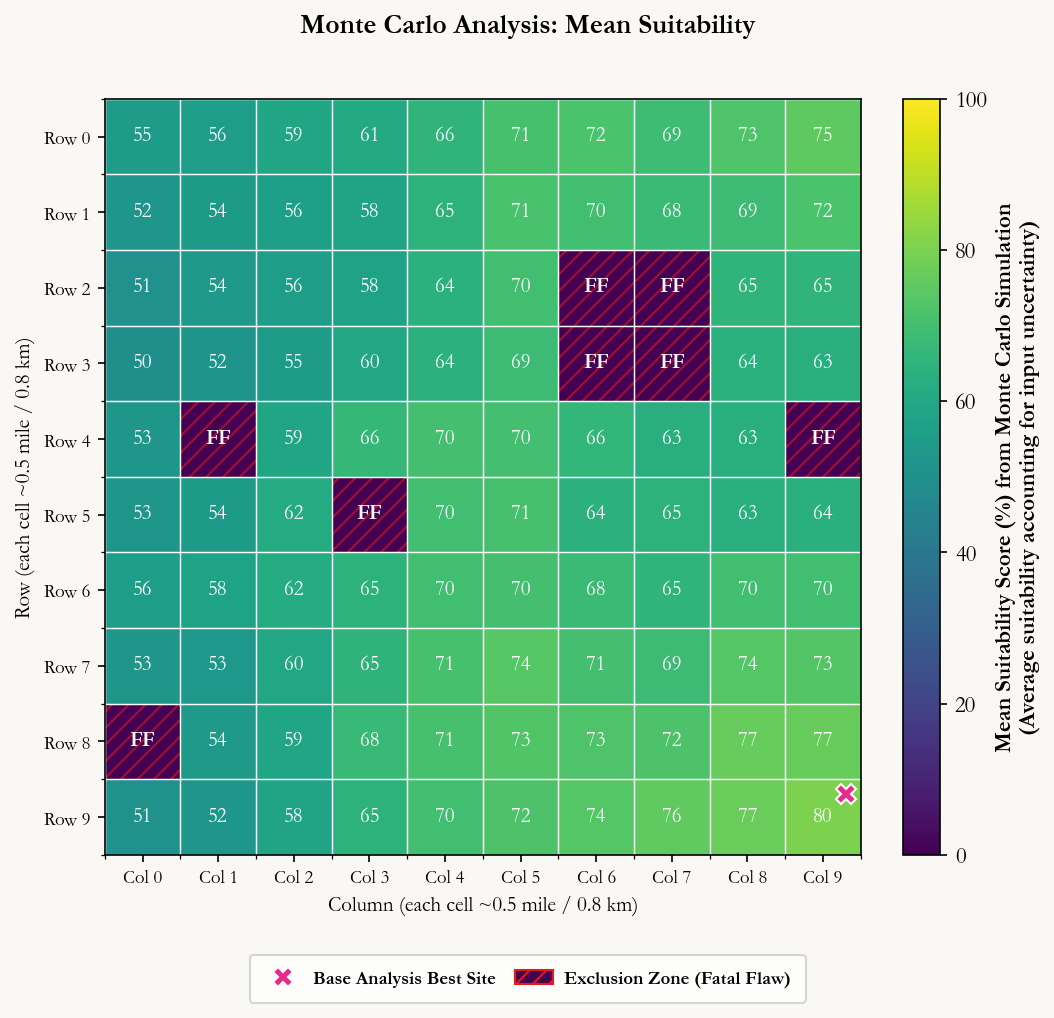

Saved figure '17_mc_stddev_suitability.png' (dpi=1200).


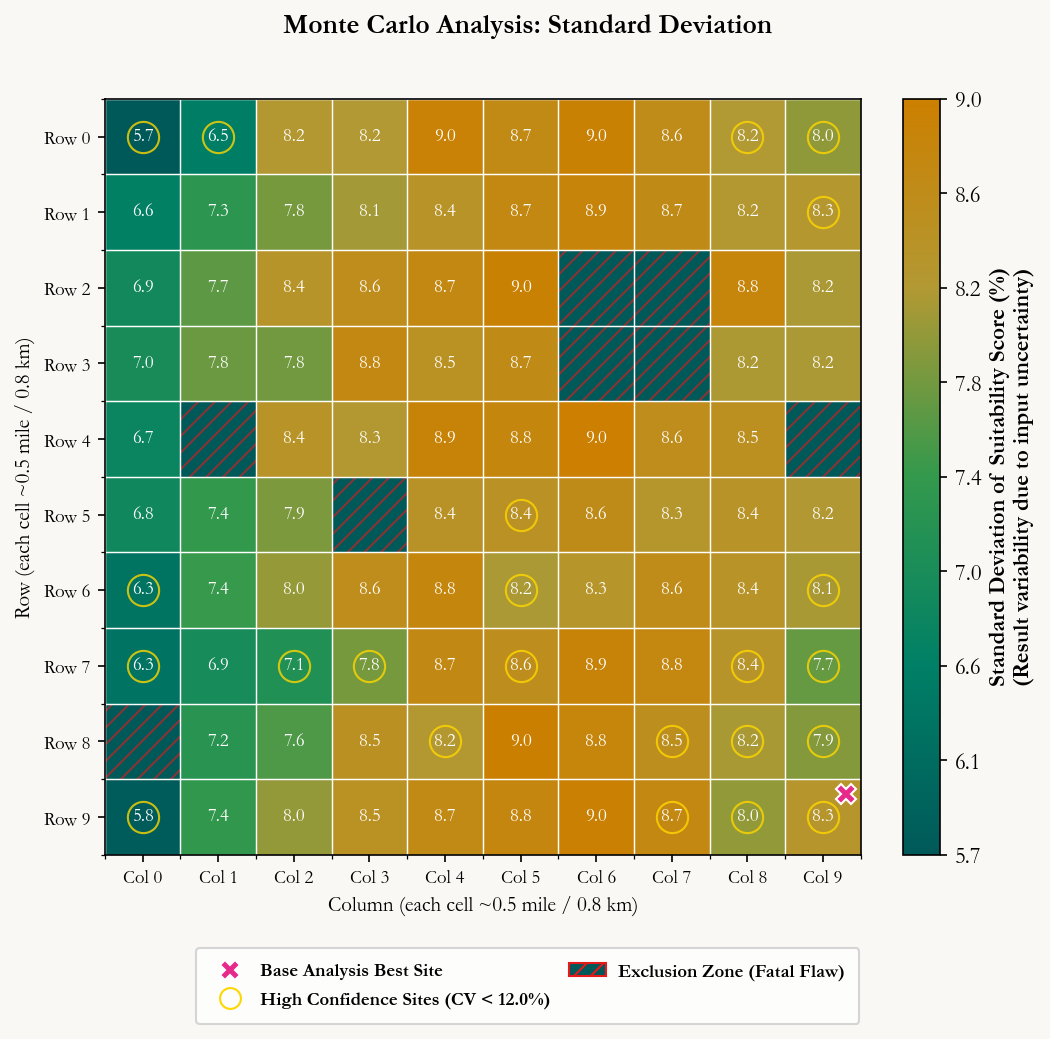

In [21]:
# Visualization functions for Monte Carlo uncertainty analysis results

def make_perceptually_uniform_cmap(name="stddev_scientific", n_samples=512):
    """
    Creates a perceptually uniform colormap optimized for scientific visualization.
    Transition: Dark Teal (High Confidence) -> Ochre (Low Confidence).
    """
    from matplotlib.colors import LinearSegmentedColormap
    
    # Define scientifically meaningful color transition
    colors = [
        (0.0, (0.0, 0.35, 0.35)),    # Dark teal (low std dev / high confidence)
        (0.25, (0.0, 0.5, 0.4)),     # Teal
        (0.5, (0.2, 0.6, 0.3)),      # Green-teal transition
        (0.75, (0.7, 0.6, 0.2)),     # Olive-yellow
        (1.0, (0.8, 0.5, 0.0))       # Ochre (high std dev / low confidence)
    ]
    
    return LinearSegmentedColormap.from_list(name, colors, N=n_samples)

def add_scientific_annotations(ax, mean_scores, std_scores, base_fatal_flaws):
    """
    Adds scientific annotations to the plot, specifically highlighting areas of 
    high statistical confidence (low Coefficient of Variation).
    """
    # Calculate Coefficient of Variation (CV = StdDev / Mean)
    cv = np.zeros_like(mean_scores) * np.nan
    mask = (~np.isnan(mean_scores)) & (~np.isnan(std_scores)) & (mean_scores > 0) & (~base_fatal_flaws)
    
    if np.any(mask):
        cv[mask] = std_scores[mask] / mean_scores[mask] * 100
        
        # Identify high confidence areas (CV < 25th percentile of valid cells)
        cv_threshold = np.nanpercentile(cv[mask], 25)
        high_confidence = (cv < cv_threshold) & mask
        
        # Mark high confidence locations with gold circles
        for i, j in zip(*np.where(high_confidence)):
            ax.plot(j, i, 'o', markersize=15, markerfacecolor='none', 
                    markeredgecolor='#FFD700', alpha=0.8, markeredgewidth=1.0)

def plot_mc_results(mean_scores, std_scores, base_fatal_flaws, score_percentages, best_loc):
    """
    Visualizes the results of the Monte Carlo uncertainty analysis.
    Generates two figures: Mean Suitability (Figure 16) and Standard Deviation (Figure 17).
    """
    global fig
    rows, cols = mean_scores.shape


    # FIGURE 16: MEAN SUITABILITY SCORE

    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG_COLOR)
    
    # Use Viridis colormap for mean suitability (consistent with standard scientific practice)
    cmap = plt.get_cmap('viridis')
    norm = mpl.colors.Normalize(vmin=0, vmax=100)
    img = ax.imshow(mean_scores, cmap=cmap, norm=norm)
    
    cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean Suitability Score (%) from Monte Carlo Simulation\n"
                   "(Average suitability accounting for input uncertainty)", 
                   fontsize=11, fontweight='bold')

    # Grid and Axis Labels
    ax.set_xticks(np.arange(cols)); ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([f"Col {x}" for x in range(cols)], fontsize=9)
    ax.set_yticklabels([f"Row {y}" for y in range(rows)], fontsize=9)
    ax.set_xlabel(f"Column (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_ylabel(f"Row (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True); ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color=GRID_COLOR, linestyle='-', linewidth=0.7)

    # Annotations
    for i in range(rows):
        for j in range(cols):
            if base_fatal_flaws[i, j]:
                 ax.add_patch(mpatches.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor=FATAL_HATCH_COLOR, hatch='///', lw=0.3, alpha=0.6))
                 ax.text(j, i, "FF", ha='center', va='center', color='white', fontsize=10, fontweight='bold')
            else:
                 mean_val = mean_scores[i,j]
                 if pd.notna(mean_val):
                     ax.text(j, i, f"{mean_val:.0f}", ha='center', va='center', color='white', fontsize=10)

    # Mark Deterministic Best Location
    if best_loc is not None and 0 <= best_loc[0] < rows and 0 <= best_loc[1] < cols:
         ax.plot(best_loc[1] + 0.3, best_loc[0] - 0.3, marker='X', markersize=10, color=HIGHLIGHT_COLOR, markeredgecolor='white', linestyle='None')

    # Layout and Legend
    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18)
    
    best_marker_legend = mlines.Line2D([], [], color=HIGHLIGHT_COLOR, marker='X', markersize=10, linestyle='None', markeredgecolor='white', label='Base Analysis Best Site')
    fatal_fill_color = cmap(norm(0))
    fatal_hatch_legend = mpatches.Patch(facecolor=fatal_fill_color, edgecolor=FATAL_HATCH_COLOR, hatch='///', label='Exclusion Zone (Fatal Flaw)')
    legend_handles = [best_marker_legend, fatal_hatch_legend]
    
    # Calculate geometric positions for titles and legends
    ax_bbox = ax.get_position()
    cbar_bbox = cbar.ax.get_position()
    union_bbox = Bbox.union([ax_bbox, cbar_bbox])
    mid_x = union_bbox.x0 + union_bbox.width / 2
    title_y = union_bbox.y1 + 0.08
    legend_y = union_bbox.y0 - 0.15
    
    fig.suptitle("Monte Carlo Analysis: Mean Suitability", fontweight='bold', x=mid_x, y=title_y, ha='center')
    
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(mid_x, legend_y),
               bbox_transform=fig.transFigure, ncol=2, frameon=True, prop={'size': 9, 'weight': 'bold'},
               labelspacing=0.6, columnspacing=1.0, handletextpad=0.6, borderpad=0.8)
    
    save_and_show_figure("16_mc_mean_suitability.png")


    # FIGURE 17: STANDARD DEVIATION (UNCERTAINTY)

    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG_COLOR)
    
    # Use custom scientific colormap (Teal->Ochre)
    cmap_std = make_perceptually_uniform_cmap("stddev_scientific")

    valid_std = std_scores[~np.isnan(std_scores) & ~base_fatal_flaws]
    vmin_std = valid_std.min() if valid_std.size else 0
    vmax_std = valid_std.max() if valid_std.size else 10
    if vmax_std - vmin_std < 1e-6: vmax_std = vmin_std + 1
    
    norm_std = mpl.colors.Normalize(vmin=vmin_std, vmax=vmax_std)
    img = ax.imshow(std_scores, cmap=cmap_std, norm=norm_std)

    # Colorbar with explicit ticks
    tick_count = 9
    ticks = np.linspace(vmin_std, vmax_std, tick_count)
    tick_labels = [f"{tick:.1f}" for tick in ticks]
    cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04, ticks=ticks)
    cbar.set_ticklabels(tick_labels)
    cbar.set_label("Standard Deviation of Suitability Score (%)\n"
                  "(Result variability due to input uncertainty)",
                   fontsize=11, fontweight='bold')

    # Grid and Axis Labels
    ax.set_xticks(np.arange(cols)); ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([f"Col {x}" for x in range(cols)], fontsize=9)
    ax.set_yticklabels([f"Row {y}" for y in range(rows)], fontsize=9)
    ax.set_xlabel(f"Column (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_ylabel(f"Row (each cell ~{CELL_SIZE_MILES:.1f} mile / {CELL_SIZE_KM:.1f} km)", fontsize=10)
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True); ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color=GRID_COLOR, linestyle='-', linewidth=0.7)

    # Annotations
    for i in range(rows):
        for j in range(cols):
             if base_fatal_flaws[i, j]:
                 ax.add_patch(mpatches.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor=FATAL_HATCH_COLOR, hatch='///', lw=0.3, alpha=0.6))
             else:
                 std_val = std_scores[i,j]
                 if pd.notna(std_val):
                     ax.text(j, i, f"{std_val:.1f}", ha='center', va='center', color='white', fontsize=9)

    # Mark Best Location
    if best_loc is not None and 0 <= best_loc[0] < rows and 0 <= best_loc[1] < cols:
         ax.plot(best_loc[1] + 0.3, best_loc[0] - 0.3, marker='X', markersize=10, color=HIGHLIGHT_COLOR, markeredgecolor='white', linestyle='None')

    # Add Scientific Annotations (High Confidence Circles)
    add_scientific_annotations(ax, mean_scores, std_scores, base_fatal_flaws)
    
    # Calculate threshold for legend label
    cv = np.zeros_like(mean_scores) * np.nan
    mask = (~np.isnan(mean_scores)) & (~np.isnan(std_scores)) & (mean_scores > 0) & (~base_fatal_flaws)
    if np.any(mask):
        cv[mask] = std_scores[mask] / mean_scores[mask] * 100
        cv_threshold_val = np.nanpercentile(cv[mask], 25)
    else:
        cv_threshold_val = 25.0

    # Layout and Legend
    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18)
    
    best_marker_legend = mlines.Line2D([], [], color=HIGHLIGHT_COLOR, marker='X', markersize=10, linestyle='None', markeredgecolor='white', label='Base Analysis Best Site')
    fatal_fill_color = cmap_std(norm_std(vmin_std))
    fatal_hatch_legend = mpatches.Patch(facecolor=fatal_fill_color, edgecolor=FATAL_HATCH_COLOR, hatch='///', label='Exclusion Zone (Fatal Flaw)')
    high_confidence_legend = plt.Line2D([], [], marker='o', color='#FFD700', markerfacecolor='none',
                            markersize=10, markeredgewidth=1.0, linestyle='none',
                            label=f'High Confidence Sites (CV < {cv_threshold_val:.1f}%)')
    
    legend_handles = [best_marker_legend, high_confidence_legend, fatal_hatch_legend]
    
    ax_bbox = ax.get_position()
    cbar_bbox = cbar.ax.get_position()
    union_bbox = Bbox.union([ax_bbox, cbar_bbox])
    mid_x = union_bbox.x0 + union_bbox.width / 2
    title_y = union_bbox.y1 + 0.08
    legend_y = union_bbox.y0 - 0.17
    
    fig.suptitle("Monte Carlo Analysis: Standard Deviation", fontweight='bold', x=mid_x, y=title_y, ha='center')
    
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(mid_x, legend_y),
               bbox_transform=fig.transFigure, ncol=2, frameon=True, prop={'size': 9, 'weight': 'bold'},
               labelspacing=0.6, columnspacing=1.0, handletextpad=0.6, borderpad=0.8)
    
    save_and_show_figure("17_mc_stddev_suitability.png")

# Generate Monte Carlo visualization (Figures 16-17)
if UNCERTAINTY_MC and mean_scores is not None:
    plot_mc_results(mean_scores, std_scores, mc_fatal_flaws, score_percentages, best_loc)

---

<a name="15-land-ownership-analysis"></a>
## 15. Land Ownership Analysis

Beyond hydrogeologic and environmental factors, municipal well development feasibility depends heavily on land ownership. This section evaluates the distribution of site suitability scores across different property owners to identify the most promising acquisition pathways. Correlating suitability scores with ownership records delineates which landowners hold sites that optimize both hydrogeologic potential and acquisition feasibility.

**Key Considerations:**
*   **Municipal Land (Town 'A'):** Ranked highest for acquisition feasibility, minimizing administrative barriers.
*   **Private Land (King, Smith, Mayors):** Suitability is balanced against negotiation requirements; council-owned land (Mayors) offers collaborative potential.
*   **Federal Land (BLM):** Assigned a lower suitability ranking due to regulatory complexities. Additionally, spatial analysis indicates these lands largely coincide with fatal flaw exclusions (e.g., protected habitat), limiting their viability.


In [22]:
# Land ownership suitability analysis: data preparation and statistics

def calculate_ownership_statistics(scores_df):
    """Calculates and prints summary statistics for land ownership suitability."""
    if scores_df is None or scores_df.empty:
            print("Skipping Ownership Statistics: No data provided.")
            return

    # Calculate and log summary statistics
    print("\n--- Land Ownership Suitability Statistics (Non-Fatal Flaw Cells) ---")
    owner_summary = scores_df.groupby('OwnerName')['ScorePercentage'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    print(owner_summary.to_string(float_format="%.1f"))
    print("-" * 70)

# Prepare data for ownership comparison analysis
ownership_scores = []
rows, cols = score_percentages.shape
for i in range(rows):
    for j in range(cols):
        if not fatal_flaws[i, j]:
            owner_code = data['land_owners'].values[i, j]
            owner_names = {1: 'Smith', 2: 'Mayors', 3: "Town 'A'", 4: 'King', 5: 'BLM'}
            owner_name = owner_names.get(int(owner_code), 'Unknown')
            ownership_scores.append({'OwnerCode': int(owner_code), 'OwnerName': owner_name, 'ScorePercentage': score_percentages[i, j]})
scores_df = pd.DataFrame(ownership_scores)

# Output statistics
calculate_ownership_statistics(scores_df)


--- Land Ownership Suitability Statistics (Non-Fatal Flaw Cells) ---
           count  mean  median  std  min  max
OwnerName                                    
BLM           11  67.5    66.9  2.0 65.5 71.7
King          22  75.0    74.5  4.3 68.3 84.8
Mayors        26  58.8    58.3  8.6 47.6 72.4
Smith         32  61.5    59.7 10.7 44.1 79.3
Town 'A'       1  57.9    57.9  NaN 57.9 57.9
----------------------------------------------------------------------


### Figure 18: Land Ownership and Suitability

The relationship between land ownership and calculated suitability scores for non-fatal flaw cells is explored in this section. The box plot illustrates the distribution of scores within each ownership category. On average, cells owned by **Mr. King** exhibit the highest median suitability scores among the evaluated areas, while those owned by **Ms. Mayors** show the lowest average suitability.

**Landowner Categories:**

| Code | Owner | Acquisition Pathway |
|:----:|-------|--------------------|
| 3 | Town 'A' | Municipal-owned (simplest acquisition) |
| 2 | Mayors | Council member (potential collaboration) |
| 1, 4 | Smith, King | Private (negotiation required) |
| 5 | BLM | Federal land (complex permitting) |


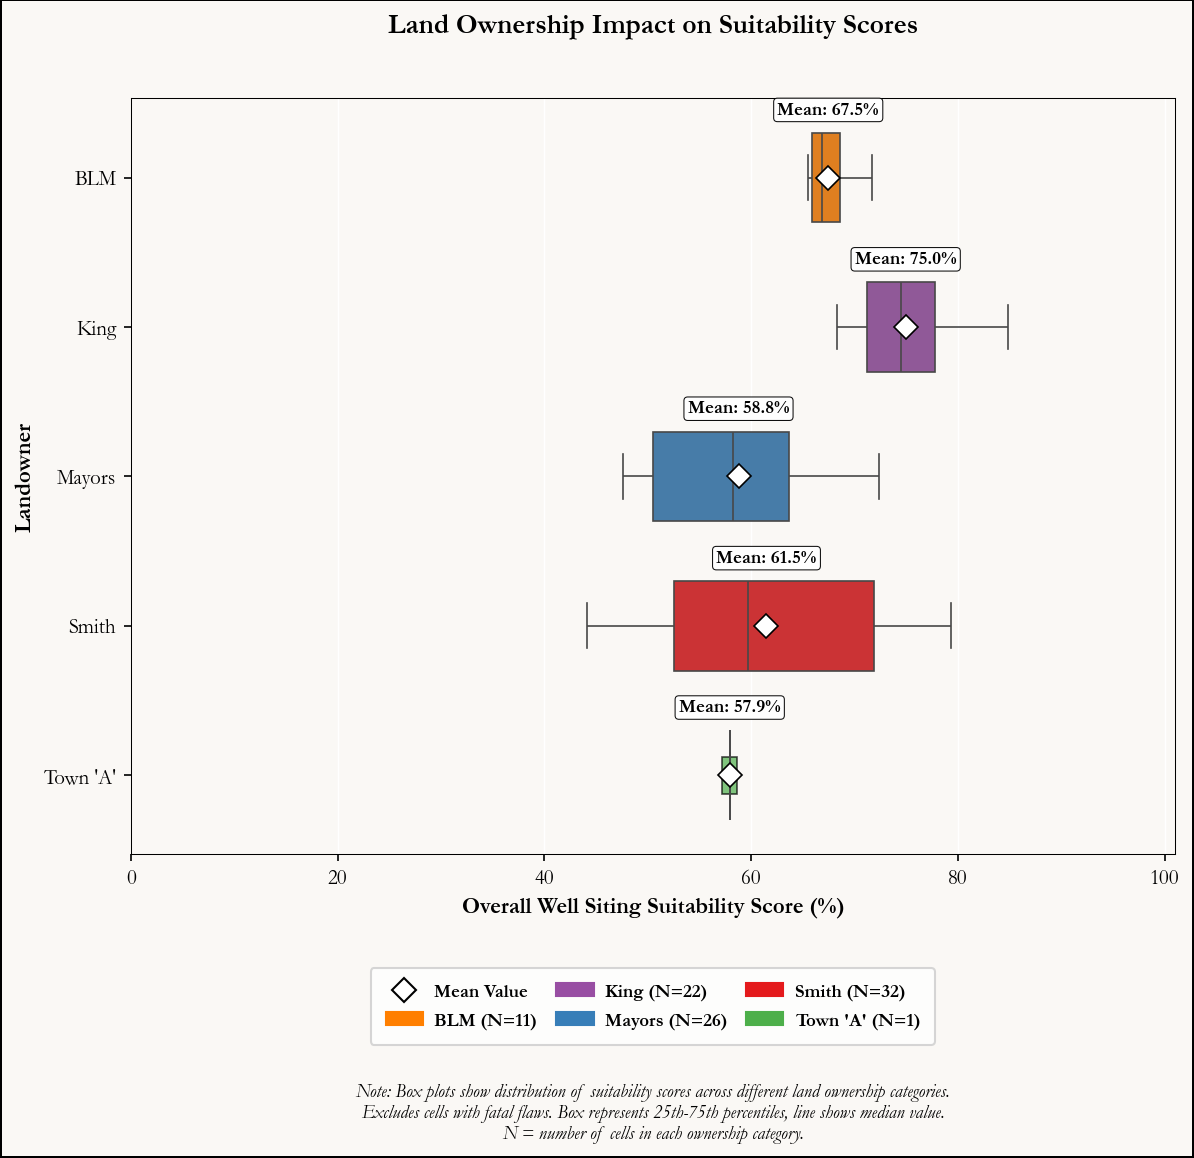

Saved figure: 18_ownership_suitability_comparison.png


In [23]:
# Visualization: Land Ownership Suitability Distribution

def plot_ownership_suitability_comparison(scores_df, filename="18_ownership_suitability_comparison.png"):
    """
    Generates a box plot comparing suitability scores across landowner categories.
    This visualization illustrates the distribution of scores within each ownership 
    category to inform acquisition strategy.

    Args:
        scores_df (pd.DataFrame): DataFrame containing 'OwnerName', 'ScorePercentage', 
                                  and 'OwnerCode' for all non-fatal flaw cells.
        filename (str): Output filename for the figure.
    """
    global fig
    if scores_df is None or scores_df.empty:
        return

    # Initialize figure with consistent dimensions (8x7 inches)
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG_COLOR)
    fig.patch.set_linewidth(1.0); fig.patch.set_edgecolor('black')

    # Set background color
    ax.set_facecolor(BG_COLOR)

    # Define unique owners and consistent color mapping
    unique_owners = sorted(scores_df['OwnerName'].unique())
    
    # Map owners to consistent reference colors
    color_map = {
        'BLM': CATEGORICAL_COLORS_REF[4],       # Orange
        'King': CATEGORICAL_COLORS_REF[3],      # Purple
        'Mayors': CATEGORICAL_COLORS_REF[1],    # Blue
        'Smith': CATEGORICAL_COLORS_REF[0],     # Red
        'Town \'A\'': CATEGORICAL_COLORS_REF[2]  # Green
    }
    
    # Create palette for seaborn
    palette = {name: color_map.get(name, (0.5, 0.5, 0.5, 1.0)) for name in unique_owners}
    
    # Configure grid lines (White grid on gray background for contrast)
    ax.grid(True, color='white', linestyle='-', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    
    # Generate Box Plot
    boxplot = sns.boxplot(
        x='ScorePercentage',
        y='OwnerName',
        data=scores_df,
        order=unique_owners,
        palette=palette,
        hue='OwnerName',  # Fix for FutureWarning
        legend=False,     # Fix for FutureWarning
        ax=ax,
        fliersize=3,
        linewidth=0.8,
        width=0.6,
        dodge=False,
        zorder=5
    )

    # specific visual handling for Town 'A' (single data point case)
    if 'Town \'A\'' in unique_owners:
        town_a_idx = unique_owners.index('Town \'A\'')
        town_a_score = scores_df[scores_df['OwnerName'] == 'Town \'A\'']['ScorePercentage'].values[0]
        
        # Create a distinct indicator for the single municipal parcel
        box_width = 1.5
        box_height = 0.25
        rect = plt.Rectangle((town_a_score - box_width/2, town_a_idx - box_height/2), 
                            box_width, box_height,
                            facecolor=color_map['Town \'A\''],
                            alpha=0.7, edgecolor='black', linewidth=0.8, zorder=4)
        ax.add_patch(rect)

    # Add Mean Markers (White Diamonds)
    means = scores_df.groupby('OwnerName')['ScorePercentage'].mean()
    vertical_positions = {owner: i for i, owner in enumerate(unique_owners)}
    
    for owner, mean_val in means.items():
        ax.plot(mean_val, vertical_positions[owner], 'D', color='white', markersize=8, 
                markeredgecolor='black', markeredgewidth=0.8, 
                label='Mean' if owner == unique_owners[0] else "", zorder=10)
    
    # Add Mean Value Labels with clear background
    for owner, mean_val in means.items():
        pos = vertical_positions[owner]
        ax.text(mean_val, pos-0.4, f"Mean: {mean_val:.1f}%", 
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.95, edgecolor='black', 
                          boxstyle='round,pad=0.2', linewidth=0.5), 
                zorder=15)

    # Axis Formatting
    ax.set_xlabel("Overall Well Siting Suitability Score (%)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Landowner", fontsize=11, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlim(0, 101)
    
    # Frame Borders
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')

    # Layout Adjustment
    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.18)
    
    # Create Custom Legend
    mean_handle = plt.Line2D([], [], marker='D', color='white', markeredgecolor='black', 
                           markersize=8, linestyle='none', label='Mean Value')
    
    owner_handles = []
    for owner in unique_owners:
        count = calculate_ownership_statistics.owner_summary.loc[owner, 'count'] if hasattr(calculate_ownership_statistics, 'owner_summary') else scores_df[scores_df['OwnerName']==owner].shape[0]
        owner_handles.append(mpatches.Patch(color=palette[owner], 
                                          label=f"{owner} (N={count:.0f})"))
    
    # Geometric Positioning for Title and Legend
    ax_bbox = ax.get_position()
    mid_x = ax_bbox.x0 + ax_bbox.width / 2
    title_y = ax_bbox.y1 + 0.08
    legend_y = ax_bbox.y0 - 0.19
    
    # Figure Title
    fig.suptitle(
        "Land Ownership Impact on Suitability Scores",
        fontweight='bold',
        x=mid_x,
        y=title_y,
        ha='center'
    )
    
    # Explanatory Note
    fig.text(mid_x, legend_y - 0.08, 
            "Note: Box plots show distribution of suitability scores across different land ownership categories.\n"
            "Excludes cells with fatal flaws. Box represents 25th-75th percentiles, line shows median value.\n"
            "N = number of cells in each ownership category.",
            ha='center', fontsize=9, style='italic', multialignment='center')
    
    # Legend
    all_handles = [mean_handle] + owner_handles
    fig.legend(
        handles=all_handles,
        loc='lower center',
        bbox_to_anchor=(mid_x, legend_y),
        bbox_transform=fig.transFigure,
        ncol=3,
        frameon=True,
        prop={'size': 9, 'weight': 'bold'},
        labelspacing=0.6, columnspacing=1.0,
        handletextpad=0.6, borderpad=0.8
    )
    
    # Save figure
    plt.savefig(filename, dpi=1200, bbox_inches='tight')
    plt.show()
    print(f"Saved figure: {filename}")

# Generate Figure 18: Land Ownership Analysis
plot_ownership_suitability_comparison(scores_df)

---

<a name="15-conclusions-and-recommendations"></a>
## 15. Conclusions and Recommendations

### Primary Finding

The prioritization analysis identifies the grid cell at **Row 10, Column 10** (corresponding to the southeast corner of the study area) as the highest-ranked potential site for the municipal well, achieving a suitability score of **84.8%**. Examination of the individual criterion scores reveals that this location performs favorably on several heavily weighted hydrogeologic factors, including estimated Aquifer Thickness, Transmissivity, and Well Spacing (maximizing distance from existing wells).

### Key Results Summary

| Metric | Value |
|--------|:-----:|
| Optimal Location | Row 10, Column 10 (SE Corner) |
| Best Score | 84.8% (out of 100%) |
| Fatal Flaw Cells | 8 (8% of study area) |
| High Potential Cells (>80%) | Identified in SE Quadrant |
| Study Area Coverage | 100 cells (64 km² total area) |

### Recommendations

Based on the analysis findings and acknowledged data limitations, Zootopia Consulting provides the following prioritized recommendations to guide the next phases of the municipal water supply project:

1.  **Critical Priority - Water Quality Testing:** Due to the absence of spatial water quality data, **direct water quality sampling and analysis** must be conducted at any site proposed for development to ensure compliance with drinking water standards (e.g., TDS, chlorides, nitrates).
2.  **Critical Priority - Field Verification of Aquifer Geometry:** Given the high uncertainty in the *Depth to Aquifer Base* data layer (demonstrated by cross-validation at well 'c'), direct field verification of aquifer thickness and depth to bedrock using **exploratory boreholes and/or geophysical surveys** is essential at the primary candidate site.
3.  **High Priority - Site-Specific Hydrogeologic Characterization:** Conduct **geological logging** and **controlled aquifer pumping tests** at the verified site(s) to determine reliable site-specific values for Transmissivity and Storativity, confirm sustainable yield (~1000 gpm), and quantify potential drawdown impacts.
4.  **Stakeholder Engagement and Communication:** Proactively engage with landowners, particularly **Mr. Tobias King** and the BLM. Clearly communicate the scientific rationale for site prioritization and the planned field investigations designed to address specific concerns.
5.  **Permitting and Access:** Initiate necessary permitting processes early, considering specific requirements for private vs. federal (BLM) land access.
6.  **Refine Final Siting Decision:** Utilize data from field investigations to confirm the final well location. The prioritization matrix serves as a guide to focus efforts, but the ultimate decision must be based on verified site-specific conditions.

### Responses to Stakeholder Concerns (Mr. King)

The analysis framework addresses the specific concerns raised by Mr. King as follows:

1.  **Salinity Risk (Deep Salty Water):** This analysis could not incorporate potential deep saline water due to data limitations. This highlights the importance of **Recommendation #1**, as direct sampling during field investigations is the only definitive way to assess and mitigate this risk.
2.  **Bedrock Puncture Risk:** While the *Depth to Aquifer Base* criterion suggests a thicker buffer in the southeast (Row 10, Col 10), the data possesses high uncertainty. **Recommendation #3** (Geological Logging) during test drilling is the necessary step to directly assess bedrock depth and prevent puncture of confining layers.
3.  **Well Interference:** The potential for interference was addressed by assigning a high weight (**Multiplier=5**) to the *Well Spacing* criterion, prioritizing locations farthest from known wells. However, **Recommendation #3** (Aquifer Pump Testing) is required to quantitatively predict drawdown impacts and definitively ensure Mr. King's domestic well is protected.


---

<a name="16-references"></a>
## 16. References

Glotfelty, M. F. (2017). *The Art of Water Wells*. Marvin Glotfelty Well Seminars.

United States Department of Agriculture (USDA) Farm Service Agency. (2008). *Aerial Imagery* [August 2008, Study Area vicinity]. Source: Provided by client.

United States Geological Survey (USGS). (n.d.-a). *Digital Elevation Model Data*. Source: The National Map service; data downloaded and averaged within grid cells by client.

United States Geological Survey (USGS). (n.d.-b). *Regional Hydrogeologic Assessment* [Relevant to Study Area]. Source: Interpolated hydraulic conductivity estimates provided by the client, attributed to a regional USGS report.

---

*Analysis implemented using Python 3 with NumPy, Pandas, Matplotlib, Seaborn, and cmcrameri scientific colormap libraries.*
